# Tesis — Limpieza, EDA, cruces y evaluación del estimado

**Finca:** La Gaitana (`GAITANA`, `GF` y variantes en los originales)  
**Objetivo:** entender qué explica la producción exportable y establecer si un modelo puede mejorar el estimado actual del ingeniero.

## Ruta de lectura

El contenido se organiza por etapas y fuentes. Cada bloque indica la unidad de observación, la calidad encontrada, las transformaciones y los resultados que pueden interpretarse.

| Parte | Contenido | Resultado esperado |
|---|---|---|
| I–II | Preparación por fuente: Producción, Clima, Estimados y Plan de Siembras | Bases limpias y auditables |
| III | EDA separado de cada fuente | Cobertura, composición, variabilidad y limitaciones |
| IV | Curvas de Producción | Curvas en flores/planta y estimado teórico a cinco semanas |
| V | Integración entre fuentes | Llaves válidas y alcance de cada cruce |
| VI | Evaluación del estimado | Curva teórica y ajuste del ingeniero frente a producción real |
| VII | Conclusiones | Estado de las bases, decisiones y preguntas pendientes |

Los Excel originales nunca se modifican. Las bases limpias se guardan en CSV dentro de `datos preprocesados`.

## Preguntas que orientan el análisis

- ¿Qué producto-color-variedad concentra el volumen y la variabilidad?
- ¿Qué cobertura histórica real tiene cada fuente?
- ¿Qué producción teórica resulta de multiplicar las plantas del plan por la curva de cada variedad y edad?
- ¿Qué variables de clima y siembra son conocidas antes de pronosticar?
- ¿Cuánto se equivoca el estimado actual en +1, +2, +3, +4 y +5?
- ¿El error es simétrico o existe una tendencia a subestimar ciertos colores?

# PARTE I — PREPARACIÓN Y LIMPIEZA DE DATOS

## 1. Configuración reproducible

In [1]:
from pathlib import Path
import re
import sys
import unicodedata
import warnings
import json

import duckdb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display

warnings.filterwarnings("ignore", category=FutureWarning)
sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 80)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

BASE = Path.cwd().resolve()
PROYECTO = BASE.parent if BASE.name.lower() == "notebooks" else BASE
NOTEBOOKS = PROYECTO / "Notebooks"
DATOS = PROYECTO / "Datos"

print("Proyecto:", PROYECTO)
print("Alcance:", "GAITANA exclusivamente")

Proyecto: C:\Materias y Cosas Técnicas Uniandes\Proyecto de grado\Proyecto de grado 2
Alcance: GAITANA exclusivamente


## 2. Inventario de originales

Esta celda solo cuenta archivos y tamaño. No abre los Excel. Sirve para distinguir claramente **fuentes originales** de **bases preprocesadas**.

In [2]:
filas_inventario = []
for fuente in sorted(p for p in DATOS.iterdir() if p.is_dir()):
    originales = [
        p for p in fuente.rglob("*")
        if p.is_file() and "datos preprocesados" not in str(p).lower()
    ]
    filas_inventario.append({
        "fuente": fuente.name,
        "archivos_originales": len(originales),
        "tamano_GB": sum(p.stat().st_size for p in originales) / 1024**3,
        "formatos": ", ".join(sorted({p.suffix.lower() for p in originales})) or "sin archivos",
    })
inventario_original = pd.DataFrame(filas_inventario)
display(inventario_original)

,fuente,archivos_originales,tamano_GB,formatos
0,Camas Piloto,0,0.00,sin archivos
1,Clima,6,0.59,.xlsx
2,Curvas por variedad,24,1.31,.xlsx
3,Estimados diarios,0,0.00,sin archivos
4,Estimados semanales,180,0.19,.xlsx
5,Plano de Siembras,294,6.36,.xlsx
6,Producción real,6,0.50,.xlsx


## 3. Decisiones de limpieza

No se conservan columnas por el simple hecho de existir. Entran si sirven como variable, llave o trazabilidad.

In [3]:
decisiones = pd.DataFrame([
    ["Producción real", "fecha/año/semana, ubicación, producto-color-variedad, grado, tipo, lote, tallos", "inventario y campos administrativos", "Objetivo y llaves"],
    ["Estimados semanales", "archivo, rango, tipo, año/semana objetivo, horizonte, producto-color-variedad, tallos", "tablas dinámicas de presentación", "Benchmark reproducible"],
    ["Clima", "fecha/hora, temperatura, humedad, viento, lluvia, radiación, UV, ET y PAR", "índices redundantes o sin interpretación", "Señales agronómicas"],
    ["Plano de Siembras", "invernadero, sector, cama, producto-color-variedad, plantas, fechas, sustrato, proveedor, edad", "columnas 100 % vacías o #REF!", "Cruces y trazabilidad"],
], columns=["fuente", "se_conserva", "se_excluye", "razon"])
display(decisiones)

,fuente,se_conserva,se_excluye,razon
0,Producción real,"fecha/año/semana, ubicación, producto-color-va...",inventario y campos administrativos,Objetivo y llaves
1,Estimados semanales,"archivo, rango, tipo, año/semana objetivo, hor...",tablas dinámicas de presentación,Benchmark reproducible
2,Clima,"fecha/hora, temperatura, humedad, viento, lluv...",índices redundantes o sin interpretación,Señales agronómicas
3,Plano de Siembras,"invernadero, sector, cama, producto-color-vari...",columnas 100 % vacías o #REF!,Cruces y trazabilidad


## 4. Extracción incremental autocontenida: Excel → CSV

Esta sección contiene toda la lógica necesaria para reconstruir las bases desde los Excel originales. No importa archivos `.py` del proyecto. El manifiesto de cada fuente hace que **Run All** procese solamente Excel nuevos, modificados o con salida ausente.

Las funciones se muestran por fuente porque Producción, Clima, Estimados y Siembras no tienen la misma estructura. Los originales nunca se modifican.

### 4.1 Utilidades comunes: normalización, manifiestos y escritura segura

In [4]:
# Dependencias de la extracción incremental (todas quedan visibles aquí)
import gc
import hashlib
from datetime import date, datetime, time

import pyarrow as pa
from openpyxl import load_workbook
from openpyxl.utils.datetime import from_excel

EXTENSIONES_EXCEL = {".xlsx", ".xlsm", ".xlsb", ".xls"}


def normalizar_texto(valor) -> str:
    if valor is None:
        return ""
    texto = unicodedata.normalize("NFKD", str(valor))
    texto = "".join(c for c in texto if not unicodedata.combining(c))
    return re.sub(r"\s+", " ", texto.strip()).lower()


def nombre_columna(valor) -> str:
    texto = normalizar_texto(valor)
    texto = re.sub(r"[^a-z0-9]+", "_", texto).strip("_")
    aliases = {"ano": "anio", "anosiem": "anio_siembra", "anoprod": "anio_produccion"}
    return aliases.get(texto, texto) or "columna"


def es_gaitana(valor) -> bool:
    """Reconoce GF, Gaitana, La Gaitana y variantes de puntuación/mayúsculas."""
    texto = normalizar_texto(valor)
    compacto = re.sub(r"[^a-z0-9]", "", texto)
    return compacto == "gf" or "gaitana" in compacto


def columnas_unicas(valores) -> list[str]:
    usados: dict[str, int] = {}
    salida = []
    for valor in valores:
        base = nombre_columna(valor)
        usados[base] = usados.get(base, 0) + 1
        salida.append(base if usados[base] == 1 else f"{base}_{usados[base]}")
    return salida


def carpeta_fuente(datos: Path, token: str) -> Path:
    return next(p for p in datos.iterdir() if p.is_dir() and token in normalizar_texto(p.name))


def sha256(path: Path, bloque: int = 8 * 1024 * 1024) -> str:
    h = hashlib.sha256()
    with path.open("rb") as fh:
        while parte := fh.read(bloque):
            h.update(parte)
    return h.hexdigest()


def cargar_manifest(ruta: Path) -> dict:
    if ruta.exists():
        return json.loads(ruta.read_text(encoding="utf-8"))
    return {"version": 1, "archivos": {}}


def guardar_manifest(ruta: Path, manifest: dict) -> None:
    ruta.write_text(json.dumps(manifest, ensure_ascii=False, indent=2), encoding="utf-8")


def requiere_proceso(path: Path, clave: str, salida: Path, manifest: dict, version_extractor=None) -> bool:
    previo = manifest["archivos"].get(clave, {})
    stat = path.stat()
    version_valida = version_extractor is None or previo.get("version_extractor") == version_extractor
    return not (
        previo.get("tamano") == stat.st_size
        and previo.get("mtime_ns") == stat.st_mtime_ns
        and salida.exists()
        and version_valida
    )


def registrar(path: Path, clave: str, salida: Path, manifest: dict, filas: int, estado="procesado", version_extractor=None) -> None:
    stat = path.stat()
    manifest["archivos"][clave] = {
        "tamano": stat.st_size,
        "mtime_ns": stat.st_mtime_ns,
        "sha256": sha256(path),
        "salida": str(salida),
        "filas": int(filas),
        "estado": estado,
        "procesado_en": datetime.now().isoformat(timespec="seconds"),
    }
    if version_extractor is not None:
        manifest["archivos"][clave]["version_extractor"] = version_extractor


def valor_limpio(valor, tipo: pa.DataType):
    if valor is None or valor == "":
        return None
    if pa.types.is_string(tipo):
        if isinstance(valor, (datetime, date, time)):
            return valor.isoformat()
        return str(valor).strip()
    if pa.types.is_timestamp(tipo):
        convertido = pd.to_datetime(valor, errors="coerce")
        return None if pd.isna(convertido) else convertido.to_pydatetime()
    if pa.types.is_integer(tipo):
        convertido = pd.to_numeric(valor, errors="coerce")
        return None if pd.isna(convertido) else int(convertido)
    if pa.types.is_floating(tipo):
        convertido = pd.to_numeric(valor, errors="coerce")
        return None if pd.isna(convertido) else float(convertido)
    return valor


class EscritorCSV:
    def __init__(self, destino: Path, schema: pa.Schema):
        self.destino = destino
        self.temporal = destino.with_suffix(".tmp.csv")
        self.schema = schema
        if self.temporal.exists():
            self.temporal.unlink()
        self.filas = 0

    def escribir(self, datos: dict[str, list]) -> None:
        if not datos or not next(iter(datos.values()), []):
            return
        df = pd.DataFrame(datos, columns=self.schema.names)
        df.to_csv(
            self.temporal, mode="a", header=self.filas == 0, index=False,
            encoding="utf-8-sig" if self.filas == 0 else "utf-8",
        )
        self.filas += len(df)

    def cerrar(self) -> int:
        if not self.temporal.exists():
            pd.DataFrame(columns=self.schema.names).to_csv(self.temporal, index=False, encoding="utf-8-sig")
        self.temporal.replace(self.destino)
        return self.filas


def preparar_fuente(fuente: Path) -> tuple[Path, Path, dict]:
    pre = fuente / "datos preprocesados"
    archivos = pre / "archivos"
    archivos.mkdir(parents=True, exist_ok=True)
    ruta_manifest = pre / "manifest.json"
    return pre, archivos, cargar_manifest(ruta_manifest)


def _fila_encabezado(ws, requeridas: set[str], max_filas=15):
    for numero, fila in enumerate(ws.iter_rows(min_row=1, max_row=max_filas, values_only=True), 1):
        nombres = {nombre_columna(v) for v in fila if v is not None}
        if requeridas.issubset(nombres):
            return numero, list(fila)
    return None, None


### 4.2 Producción real

Detecta el encabezado de cada hoja, conserva registros de Gaitana y escribe las columnas productivas y de trazabilidad.

In [5]:
def extraer_produccion(path: Path, destino: Path) -> int:
    campos = [
        ("finca", pa.string()), ("sector", pa.string()), ("invernadero", pa.string()),
        ("fecha_corte", pa.timestamp("us")), ("anio", pa.int16()), ("semana", pa.int8()),
        ("tipo_corte", pa.string()), ("producto", pa.string()), ("grado", pa.string()),
        ("color", pa.string()), ("variedad", pa.string()), ("tallos", pa.float64()),
        ("lote", pa.string()), ("archivo_origen", pa.string()), ("hoja_origen", pa.string()),
    ]
    schema = pa.schema(campos)
    escritor = EscritorCSV(destino, schema)
    wb = load_workbook(path, read_only=True, data_only=True, keep_links=False)
    requeridas = {"finca", "fecha_corte", "producto", "color", "variedad", "tallos"}
    for ws in wb.worksheets:
        fila_header, header = _fila_encabezado(ws, requeridas, 5)
        if not fila_header:
            continue
        columnas = columnas_unicas(header)
        indices = {nombre: i for i, nombre in enumerate(columnas)}
        lote = {campo.name: [] for campo in schema}
        vacias = 0
        for fila in ws.iter_rows(min_row=fila_header + 1, values_only=True):
            if not any(fila[i] is not None for i in indices.values() if i < len(fila)):
                vacias += 1
                if vacias >= 5000:
                    break
                continue
            vacias = 0
            indice_finca = indices.get("finca")
            finca_fila = fila[indice_finca] if indice_finca is not None and indice_finca < len(fila) else None
            if not es_gaitana(finca_fila):
                continue
            for campo in schema:
                if campo.name == "archivo_origen":
                    valor = path.name
                elif campo.name == "hoja_origen":
                    valor = ws.title
                else:
                    i = indices.get(campo.name)
                    valor = fila[i] if i is not None and i < len(fila) else None
                    if campo.name == "finca":
                        valor = "GAITANA"
                lote[campo.name].append(valor_limpio(valor, campo.type))
            if len(lote["archivo_origen"]) >= 50_000:
                escritor.escribir(lote)
                lote = {campo.name: [] for campo in schema}
        escritor.escribir(lote)
    wb.close()
    return escritor.cerrar()


### 4.3 Clima

Admite tanto `BD` como `Base de datos Gaitana`, conserva la observación fecha-hora y todavía no agrega semanalmente.

In [6]:
def extraer_clima(path: Path, destino: Path) -> int:
    wb = load_workbook(path, read_only=True, data_only=True, keep_links=False)
    if "BD" in wb.sheetnames:
        ws = wb["BD"]
    elif "Base de datos Gaitana" in wb.sheetnames:
        ws = wb["Base de datos Gaitana"]
    else:
        ws = wb[wb.sheetnames[0]]
    fila_header, header = _fila_encabezado(ws, {"date", "time"}, 10)
    if not fila_header:
        wb.close()
        raise ValueError(f"No se encontró encabezado climático en {path.name}")
    columnas_todas = columnas_unicas(header)
    # Variables suficientes para temperatura, humedad, lluvia, viento, radiación y ET.
    utiles = {
        "sede", "codigo", "anio", "mes", "semana", "dia", "date", "time",
        "tem_out", "hi_temp", "low_temp", "out_hum", "dew_pt", "wind_speed",
        "wind_dir", "rain", "rain_rate", "solar_rad", "solar_energy", "uv_index",
        "et", "luz_par_externa", "luz_par_invernadero",
    }
    seleccion = [(i, col) for i, col in enumerate(columnas_todas) if col in utiles]
    columnas = [col for _, col in seleccion]
    categoricas = {"sede", "codigo", "mes", "dia", "time", "wind_dir"}
    schema_campos = []
    for col in columnas:
        if col == "date":
            tipo = pa.timestamp("us")
        elif col in categoricas:
            tipo = pa.string()
        else:
            tipo = pa.float64()
        schema_campos.append((col, tipo))
    if "sede" not in columnas:
        schema_campos.append(("sede", pa.string()))
    schema_campos += [("archivo_origen", pa.string()), ("hoja_origen", pa.string())]
    schema = pa.schema(schema_campos)
    escritor = EscritorCSV(destino, schema)
    lote = {campo.name: [] for campo in schema}
    vacias = 0
    max_col = max(i for i, _ in seleccion) + 1
    for fila in ws.iter_rows(min_row=fila_header + 1, max_col=max_col, values_only=True):
        if not any(fila[i] is not None for i, _ in seleccion if i < len(fila)):
            vacias += 1
            if vacias >= 5000:
                break
            continue
        vacias = 0
        valores_filtro = {
            col: fila[i] if i < len(fila) else None
            for i, col in seleccion if col in {"sede", "codigo"}
        }
        hoja_gaitana = "gaitana" in normalizar_texto(ws.title) and "arabella" not in normalizar_texto(ws.title)
        if not hoja_gaitana and not any(es_gaitana(v) for v in valores_filtro.values()):
            continue
        for i, col in seleccion:
            campo = schema.field(col)
            valor = fila[i] if i < len(fila) else None
            if col == "sede":
                valor = "GAITANA"
            lote[col].append(valor_limpio(valor, campo.type))
        if "sede" not in columnas:
            lote["sede"].append("GAITANA")
        lote["archivo_origen"].append(path.name)
        lote["hoja_origen"].append(ws.title)
        if len(lote["archivo_origen"]) >= 50_000:
            escritor.escribir(lote)
            lote = {campo.name: [] for campo in schema}
    escritor.escribir(lote)
    wb.close()
    return escritor.cerrar()


### 4.4 Estimados semanales

Despivota las matrices, conserva solamente `ESTIMADO` y mantiene separadas la emisión, la semana objetivo y el horizonte.

In [7]:
def _valor_celda_expandido(ws, fila: int, columna: int):
    celda = ws.cell(fila, columna)
    if celda.value is not None:
        return celda.value
    for rango in ws.merged_cells.ranges:
        if rango.min_row <= fila <= rango.max_row and rango.min_col <= columna <= rango.max_col:
            return ws.cell(rango.min_row, rango.min_col).value
    return None


def _encabezado_rellenado(ws, fila: int, inicio: int, fin: int) -> list:
    salida, anterior = [], None
    for columna in range(inicio, fin + 1):
        valor = _valor_celda_expandido(ws, fila, columna)
        if valor is not None:
            anterior = valor
        salida.append(anterior)
    return salida


def _rango_archivo(path: Path, anio_carpeta: int) -> tuple[int | None, int | None, int]:
    nombre = normalizar_texto(path.stem)
    # Caso que cruza año: "sem 39-2025 a 8-2026". El segundo número
    # después de "sem" es un año, no la semana final.
    cruzado = re.search(
        r"(?:sem|semana)\D*(\d{1,2})\D*(20\d{2})\D+(\d{1,2})\D*(20\d{2})",
        nombre,
    )
    if cruzado:
        return int(cruzado.group(1)), int(cruzado.group(3)), int(cruzado.group(2))
    # Casos normales: "sem 29-33 2025" o "sem 1 a 8 de 2026".
    match = re.search(r"(?:sem|semana)\D*(\d{1,2})\s*(?:-|a)\s*(\d{1,2})(?!\d)", nombre)
    if not match:
        return None, None, anio_carpeta
    return int(match.group(1)), int(match.group(2)), anio_carpeta


def extraer_estimado(path: Path, destino: Path, anio_carpeta: int) -> int:
    wb = load_workbook(path, read_only=True, data_only=True, keep_links=False)
    inicio_archivo, fin_archivo, anio_emision = _rango_archivo(path, anio_carpeta)
    registros = []
    for ws in wb.worksheets:
        titulo = normalizar_texto(ws.title)
        if any(x in titulo for x in ["grado", "resumen", "consolidado"]):
            continue
        max_filas = min(ws.max_row or 0, 5_000)
        max_columnas = min(ws.max_column or 0, 100)
        filas = list(ws.iter_rows(min_row=1, max_row=max_filas, max_col=max_columnas, values_only=True))
        def celda(fila, columna):
            if fila < 1 or columna < 1 or fila > len(filas):
                return None
            valores = filas[fila - 1]
            return valores[columna - 1] if columna <= len(valores) else None
        fila_header = None
        for r in range(1, min(max_filas, 20) + 1):
            if nombre_columna(celda(r, 1)) == "color" and nombre_columna(celda(r, 2)) == "variedad":
                fila_header = r
                break
        if not fila_header:
            continue
        finca = None
        producto = None
        for r in range(1, fila_header):
            etiqueta = nombre_columna(celda(r, 1))
            if etiqueta == "codfinca":
                finca = celda(r, 2)
            elif etiqueta == "producto":
                producto = celda(r, 2)
        if not es_gaitana(finca) and "gaitana" not in titulo:
            continue
        finca = "GAITANA"
        semanas = [celda(fila_header, c) for c in range(3, max_columnas + 1)]
        filas_superiores = range(max(1, fila_header - 5), fila_header)
        fila_tipo = next((r for r in filas_superiores if any(
            normalizar_texto(celda(r, c)) in {"real", "estimado"}
            for c in range(3, max_columnas + 1)
        )), fila_header - 2)
        fila_anio = next((r for r in range(fila_tipo + 1, fila_header) if any(
            str(celda(r, c)).strip().startswith("20")
            for c in range(3, max_columnas + 1)
        )), fila_header - 1)
        def encabezado_rellenado(fila):
            salida, anterior = [], None
            for c in range(3, max_columnas + 1):
                valor = celda(fila, c)
                if valor is not None:
                    anterior = valor
                salida.append(anterior)
            return salida
        tipos = encabezado_rellenado(fila_tipo)
        anios = encabezado_rellenado(fila_anio)
        color_actual = None
        for r in range(fila_header + 1, max_filas + 1):
            color = celda(r, 1)
            variedad = celda(r, 2)
            if color and not normalizar_texto(color).startswith("total"):
                color_actual = color
            if not variedad or normalizar_texto(variedad).startswith("total"):
                continue
            for offset, c in enumerate(range(3, max_columnas + 1)):
                semana = pd.to_numeric(semanas[offset], errors="coerce")
                cantidad = pd.to_numeric(celda(r, c), errors="coerce")
                anio_obj = pd.to_numeric(anios[offset], errors="coerce")
                tipo = normalizar_texto(tipos[offset])
                if pd.isna(semana) or pd.isna(cantidad):
                    continue
                anio_obj = int(anio_obj) if not pd.isna(anio_obj) else anio_carpeta
                semana = int(semana)
                # La base preprocesada de esta fuente representa exclusivamente
                # las predicciones del ingeniero. Los bloques REAL del mismo
                # libro no sustituyen la fuente oficial de Producción.
                if tipo != "estimado":
                    continue
                if tipo == "estimado" and inicio_archivo and anio_obj == anio_emision and semana < inicio_archivo:
                    continue
                horizonte = None
                if tipo == "estimado" and inicio_archivo:
                    try:
                        fecha_origen = date.fromisocalendar(anio_emision, min(inicio_archivo, 52), 1)
                        fecha_obj = date.fromisocalendar(anio_obj, min(semana, 52), 1)
                        horizonte = ((fecha_obj - fecha_origen).days // 7) + 1
                    except ValueError:
                        pass
                registros.append({
                    "archivo_origen": path.name, "hoja_origen": ws.title,
                    "anio_carpeta": anio_carpeta, "semana_inicio_archivo": inicio_archivo,
                    "semana_fin_archivo": fin_archivo, "finca": finca, "producto": producto,
                    "color": color_actual, "variedad": variedad, "tipo": tipo,
                    "anio_objetivo": anio_obj, "semana_objetivo": semana,
                    "horizonte": horizonte, "tallos": float(cantidad),
                })
    wb.close()
    df = pd.DataFrame(registros)
    if df.empty:
        df = pd.DataFrame(columns=[
            "archivo_origen", "hoja_origen", "anio_carpeta", "semana_inicio_archivo",
            "semana_fin_archivo", "finca", "producto", "color", "variedad", "tipo",
            "anio_objetivo", "semana_objetivo", "horizonte", "tallos",
        ])
    df.to_csv(destino, index=False, encoding="utf-8-sig")
    return len(df)


### 4.5 Plano de Siembras

Lee la pestaña cruda `Datos`, combina columnas duplicadas solo cuando contienen valores útiles y conserva el año y la semana a los que corresponde cada archivo.

In [8]:
def _metadatos_foto_siembra(path: Path) -> tuple[int | None, int | None, date | None]:
    """Obtiene la semana de la fotografía; no la confunde con la fecha sembrada."""
    anio = next((int(p) for p in reversed(path.parts) if re.fullmatch(r"20\d{2}", p)), None)
    match = re.search(r"(?:sem|semana)\D*(\d{1,2})", normalizar_texto(path.stem))
    semana = int(match.group(1)) if match else None
    fecha = None
    if anio and semana:
        try:
            fecha = date.fromisocalendar(anio, semana, 1)
        except ValueError:
            fecha = date.fromisocalendar(anio, 52, 1)
    return anio, semana, fecha


def _es_valor_util(valor, texto=False) -> bool:
    if valor is None or (isinstance(valor, str) and not valor.strip()):
        return False
    if isinstance(valor, str) and valor.strip().startswith("#"):
        return False
    if texto and normalizar_texto(valor) in {"0", "nan", "none"}:
        return False
    return True


def _fecha_excel(valor):
    if not _es_valor_util(valor):
        return None
    if isinstance(valor, (datetime, date)):
        return valor
    numero = pd.to_numeric(valor, errors="coerce")
    if not pd.isna(numero) and 20_000 <= float(numero) <= 80_000:
        try:
            return from_excel(float(numero))
        except (ValueError, TypeError, OverflowError):
            return None
    convertido = pd.to_datetime(valor, errors="coerce", dayfirst=True)
    return None if pd.isna(convertido) else convertido.to_pydatetime()


def extraer_siembra(path: Path, destino: Path) -> int:
    wb = load_workbook(path, read_only=True, data_only=True, keep_links=False)
    if "Datos" not in wb.sheetnames:
        wb.close()
        raise ValueError(f"No existe hoja Datos en {path.name}")
    ws = wb["Datos"]
    fila_header, header = _fila_encabezado(ws, {"finca", "producto", "variedad", "fecha_siembra"}, 10)
    if not fila_header:
        wb.close()
        raise ValueError(f"No se encontró el encabezado de siembras en {path.name}")
    columnas = columnas_unicas(header)
    # Cada concepto puede reaparecer a la derecha del libro. Se usa el primer
    # valor válido por fila y se rechazan #REF!, ceros de relleno y blancos.
    aliases = {
        "finca": ["finca", "cod_finca"],
        "cod_invernadero": ["cod_invernadero"], "invernadero": ["invernadero"],
        "sector": ["sector"], "nro_cama": ["nro_cama", "cama", "cama_2"],
        "producto": ["producto"], "color": ["color"],
        "variedad": ["variedad", "variedad_2", "variedad_3"],
        "plantas": ["plantas", "plantas_2", "plantas_3"],
        "fecha_siembra": ["fecha_siembra", "fecha_de_siembra", "fecha_de_siembra_2"],
        "sem_siembra": ["sem_siembra"], "anio_siembra": ["anio_siembra"],
        "fecha_produccion": ["fecha_produccion"],
        "sem_produccion": ["sem_produccion"], "anio_produccion": ["anio_produccion"],
        "sustrato": ["sustrato", "sustrato_2", "sustrato_3"],
        "propagador": ["propagador"], "proveedor": ["proveedor"], "edad": ["edad"],
    }
    candidatos = {
        campo: [i for nombre in nombres for i, col in enumerate(columnas) if col == nombre]
        for campo, nombres in aliases.items()
    }
    fechas = {"fecha_siembra", "fecha_produccion"}
    numericas = {
        "nro_cama", "plantas", "sem_siembra", "anio_siembra", "sem_produccion",
        "anio_produccion", "edad",
    }
    campos = []
    for col in aliases:
        tipo = pa.timestamp("us") if col in fechas else pa.float64() if col in numericas else pa.string()
        campos.append((col, tipo))
    campos += [
        ("anio_foto", pa.int16()), ("semana_foto", pa.int8()),
        ("fecha_foto", pa.timestamp("us")), ("origen_fecha_siembra", pa.string()),
        ("origen_fecha_produccion", pa.string()), ("archivo_origen", pa.string()),
        ("hoja_origen", pa.string()),
    ]
    schema = pa.schema(campos)
    escritor = EscritorCSV(destino, schema)
    lote = {campo.name: [] for campo in schema}
    vacias = 0
    indices_usados = sorted({i for valores in candidatos.values() for i in valores})
    max_col = max(indices_usados) + 1
    anio_foto, semana_foto, fecha_foto = _metadatos_foto_siembra(path)
    for fila in ws.iter_rows(min_row=fila_header + 1, max_col=max_col, values_only=True):
        if not any(fila[i] is not None for i in indices_usados if i < len(fila)):
            vacias += 1
            if vacias >= 5000:
                break
            continue
        vacias = 0
        def coalescer(campo, texto=False):
            for indice in candidatos[campo]:
                valor = fila[indice] if indice < len(fila) else None
                if _es_valor_util(valor, texto=texto):
                    return valor, columnas[indice]
            return None, None

        finca, _ = coalescer("finca", texto=True)
        if not es_gaitana(finca):
            continue
        valores, origenes = {}, {}
        for col in aliases:
            valor, origen = coalescer(col, texto=col not in numericas | fechas)
            valores[col], origenes[col] = valor, origen
        valores["finca"] = "GAITANA"
        valores["fecha_siembra"] = _fecha_excel(valores["fecha_siembra"])
        valores["fecha_produccion"] = _fecha_excel(valores["fecha_produccion"])
        origen_produccion = "fecha_reportada" if valores["fecha_produccion"] else "no_disponible"
        if valores["fecha_produccion"] is None:
            anio_prod = pd.to_numeric(valores["anio_produccion"], errors="coerce")
            sem_prod = pd.to_numeric(valores["sem_produccion"], errors="coerce")
            if not pd.isna(anio_prod) and not pd.isna(sem_prod):
                try:
                    valores["fecha_produccion"] = date.fromisocalendar(int(anio_prod), int(sem_prod), 1)
                    origen_produccion = "semana_anio_reportados"
                except ValueError:
                    pass
        for col in aliases:
            campo = schema.field(col)
            lote[col].append(valor_limpio(valores[col], campo.type))
        lote["anio_foto"].append(anio_foto)
        lote["semana_foto"].append(semana_foto)
        lote["fecha_foto"].append(valor_limpio(fecha_foto, schema.field("fecha_foto").type))
        lote["origen_fecha_siembra"].append(origenes["fecha_siembra"] or "no_disponible")
        lote["origen_fecha_produccion"].append(origen_produccion)
        lote["archivo_origen"].append(path.name)
        lote["hoja_origen"].append(ws.title)
        if len(lote["archivo_origen"]) >= 25_000:
            escritor.escribir(lote)
            lote = {campo.name: [] for campo in schema}
    escritor.escribir(lote)
    wb.close()
    return escritor.cerrar()


### 4.6 Control incremental y bases anuales por emisión

In [9]:
def _procesar_archivos(fuente: Path, archivos_entrada: list[Path], extractor, etiqueta: str, version_extractor=None) -> pd.DataFrame:
    pre, archivos_salida, manifest = preparar_fuente(fuente)
    registros = []
    for numero, path in enumerate(archivos_entrada, 1):
        clave = str(path.relative_to(fuente))
        nombre_salida = f"{nombre_columna(path.stem)[:80]}_{hashlib.md5(clave.encode()).hexdigest()[:10]}.csv"
        salida = archivos_salida / nombre_salida
        if requiere_proceso(path, clave, salida, manifest, version_extractor):
            print(f"[{etiqueta} {numero}/{len(archivos_entrada)}] {clave}")
            try:
                filas = extractor(path, salida)
                registrar(path, clave, salida, manifest, filas, version_extractor=version_extractor)
                estado = "procesado"
            except Exception as exc:
                estado, filas = f"error: {exc}", 0
                manifest["archivos"][clave] = {"estado": estado, "procesado_en": datetime.now().isoformat()}
                print(f"  ERROR: {exc}")
            guardar_manifest(pre / "manifest.json", manifest)
        else:
            previo = manifest["archivos"][clave]
            filas, estado = previo.get("filas", 0), "sin cambios"
        registros.append({"archivo": clave, "salida": str(salida), "filas": filas, "estado": estado})
        gc.collect()
    inventario = pd.DataFrame(registros)
    inventario.to_csv(pre / "inventario_preprocesamiento.csv", index=False, encoding="utf-8-sig")
    return inventario


def preprocesar_produccion(datos: Path) -> pd.DataFrame:
    fuente = carpeta_fuente(datos, "produccion real")
    archivos = sorted(p for p in fuente.glob("*.xlsx") if "datos preprocesados" not in normalizar_texto(str(p)))
    return _procesar_archivos(fuente, archivos, extraer_produccion, "producción")


def preprocesar_clima(datos: Path) -> pd.DataFrame:
    fuente = carpeta_fuente(datos, "clima")
    archivos = sorted(fuente.glob("*.xlsx"))
    return _procesar_archivos(fuente, archivos, extraer_clima, "clima")


def preprocesar_estimados(datos: Path) -> pd.DataFrame:
    fuente = carpeta_fuente(datos, "estimados semanales")
    archivos = sorted(p for p in fuente.rglob("*.xlsx") if "datos preprocesados" not in normalizar_texto(str(p)))
    def extractor(path, salida):
        anio = next((int(parte) for parte in path.parts if re.fullmatch(r"20\d{2}", parte)), 0)
        return extraer_estimado(path, salida, anio)
    inventario = _procesar_archivos(fuente, archivos, extractor, "estimados", version_extractor=4)

    pre = fuente / "datos preprocesados"
    salidas_vigentes = {Path(p).resolve() for p in inventario["salida"]}
    # Una fuente eliminada por ser duplicada no debe seguir entrando desde un
    # CSV huérfano de una ejecución anterior.
    for csv in (pre / "archivos").glob("*.csv"):
        if csv.resolve() not in salidas_vigentes:
            csv.unlink()

    carpeta_anual = pre / "por año"
    carpeta_anual.mkdir(parents=True, exist_ok=True)
    resumen_envios, salidas_anuales_vigentes = [], set()
    for fila in inventario.itertuples(index=False):
        if str(fila.estado).startswith("error") or not Path(fila.salida).exists():
            continue
        partes_clave = Path(fila.archivo).parts
        anio = next((int(p) for p in partes_clave if re.fullmatch(r"20\d{2}", p)), None)
        if anio is None:
            continue
        base_envio = pd.read_csv(fila.salida, low_memory=False)
        if "tipo" in base_envio:
            base_envio = base_envio[base_envio["tipo"].map(normalizar_texto).eq("estimado")].copy()
        antes = len(base_envio)
        base_envio = base_envio.drop_duplicates()
        destino_anio = carpeta_anual / str(anio)
        destino_anio.mkdir(parents=True, exist_ok=True)
        salida_envio = destino_anio / Path(fila.salida).name
        temporal = salida_envio.with_suffix(".tmp.csv")
        base_envio.to_csv(temporal, index=False, encoding="utf-8-sig")
        temporal.replace(salida_envio)
        salidas_anuales_vigentes.add(salida_envio.resolve())
        semana_inicio, semana_fin, _ = _rango_archivo(fuente / fila.archivo, anio)
        resumen_envios.append({
            "anio_emision": anio, "semana_inicio": semana_inicio, "semana_fin": semana_fin,
            "archivo_excel": fila.archivo, "archivo_csv": str(salida_envio),
            "filas_estimadas": len(base_envio),
            "duplicados_exactos_eliminados": antes - len(base_envio),
        })
    # Retira bases derivadas de originales que ya no existen o fueron
    # eliminados por duplicidad, sin tocar el inventario anual.
    for csv in carpeta_anual.glob("20*/*.csv"):
        if csv.resolve() not in salidas_anuales_vigentes:
            csv.unlink()
    pd.DataFrame(resumen_envios).sort_values(
        ["anio_emision", "semana_inicio", "archivo_excel"], na_position="last"
    ).to_csv(carpeta_anual / "inventario_bases_por_envio.csv", index=False, encoding="utf-8-sig")
    return inventario


### 4.7 Historia longitudinal de siembras

Compara archivos de semanas consecutivas. Una misma siembra repetida significa que continúa registrada en el plan; no es un duplicado accidental.

In [10]:
def _llave_texto(serie: pd.Series) -> pd.Series:
    return (
        serie.fillna("").astype(str).str.normalize("NFKD")
        .str.encode("ascii", errors="ignore").str.decode("ascii").str.lower()
        .str.strip().str.replace(r"\.0$", "", regex=True)
        .str.replace(r"[^a-z0-9]+", "", regex=True)
    )


def construir_historial_siembras(fuente: Path, inventario: pd.DataFrame) -> None:
    """Compara fotografías consecutivas sin borrar la historia semanal.

    La identidad operativa asumida es invernadero + cama + fecha de siembra.
    Los registros sin esos tres componentes se conservan, pero se excluyen de
    la clasificación porque no pueden enlazarse de forma confiable.
    """
    pre = fuente / "datos preprocesados"
    auditoria = pre / "auditoria"
    consolidados = pre / "bases consolidadas"
    control = pre / "_control"
    for carpeta in [auditoria, consolidados, control]:
        carpeta.mkdir(parents=True, exist_ok=True)
    if inventario.empty:
        return
    fotos = inventario.copy()
    metadatos = fotos["archivo"].apply(
        lambda x: pd.Series(_metadatos_foto_siembra(fuente / x)[:2], index=["anio_foto", "semana_foto"])
    )
    fotos[["anio_foto", "semana_foto"]] = metadatos
    fotos = fotos.dropna(subset=["anio_foto", "semana_foto", "salida"])
    fotos = fotos[~fotos["estado"].astype(str).str.startswith("error")].copy()
    fotos["es_actualizado"] = fotos["archivo"].map(lambda x: int("actual" in normalizar_texto(x)))
    fotos["filas"] = pd.to_numeric(fotos["filas"], errors="coerce").fillna(0)
    fotos = fotos.sort_values(
        ["anio_foto", "semana_foto", "es_actualizado", "filas", "archivo"]
    )
    # Si existen dos versiones de una semana, ambas quedan extraídas; la de
    # mayor prioridad se usa para no contar dos veces el mismo estado semanal.
    canonicas = fotos.groupby(["anio_foto", "semana_foto"], as_index=False).tail(1).copy()
    fotos["version_canonica"] = fotos.index.isin(canonicas.index)
    fotos.to_csv(auditoria / "versiones_semanales.csv", index=False, encoding="utf-8-sig")

    salidas_historial = [
        consolidados / "siembras_historial_cambios_gaitana.csv",
        auditoria / "resumen_cambios_por_semana.csv",
        auditoria / "calidad_por_semana.csv",
        consolidados / "siembras_estado_actual_gaitana.csv",
    ]
    firma = []
    for salida in canonicas["salida"]:
        ruta = Path(salida)
        if ruta.exists():
            stat = ruta.stat()
            firma.append([str(ruta), stat.st_size, stat.st_mtime_ns])
    control_historial = control / "manifest_historial_siembras.json"
    control_previo = cargar_manifest(control_historial) if control_historial.exists() else {}
    if (
        control_previo.get("version_historial") == 5
        and control_previo.get("firma") == firma
        and all(p.exists() for p in salidas_historial)
    ):
        print("[siembras] historial semanal sin cambios")
        return

    campos_estado = ["producto", "color", "variedad", "plantas", "sustrato", "propagador", "proveedor"]
    columnas_evento = [
        "fecha_foto", "fecha_foto_anterior", "tipo_evento", "tipo_modificacion",
        "id_ciclo", "campos_modificados",
        "valores_anteriores", "valores_nuevos",
        "invernadero", "nro_cama", "fecha_siembra", *campos_estado, "archivo_origen",
    ]
    ruta_eventos = consolidados / "siembras_historial_cambios_gaitana.csv"
    temporal = ruta_eventos.with_suffix(".tmp.csv")
    if temporal.exists():
        temporal.unlink()
    escribio = False
    resumen, calidad = [], []
    anterior = None
    fecha_anterior = None
    estado_actual = pd.DataFrame()

    for _, foto in canonicas.sort_values(["anio_foto", "semana_foto"]).iterrows():
        ruta = Path(foto["salida"])
        if not ruta.exists():
            continue
        actual = pd.read_csv(ruta, low_memory=False)
        for col in ["invernadero", "nro_cama", "fecha_siembra", *campos_estado]:
            if col not in actual:
                actual[col] = pd.NA
        actual["fecha_siembra"] = pd.to_datetime(actual["fecha_siembra"], errors="coerce")
        fecha_actual = date.fromisocalendar(int(foto["anio_foto"]), min(int(foto["semana_foto"]), 52), 1)
        inv = _llave_texto(actual["invernadero"])
        cama = _llave_texto(actual["nro_cama"])
        fecha = actual["fecha_siembra"].dt.strftime("%Y%m%d").fillna("")
        actual["id_ciclo"] = inv + "|" + cama + "|" + fecha
        llave_valida = inv.ne("") & cama.ne("") & fecha.ne("")
        duplicados = int(actual.loc[llave_valida, "id_ciclo"].duplicated(keep=False).sum())
        faltantes = int((~llave_valida).sum())
        comparable = actual.loc[llave_valida].drop_duplicates("id_ciclo", keep="last").copy()
        for col in campos_estado:
            comparable[f"__{col}"] = _llave_texto(comparable[col])
        comparable["__estado"] = comparable[f"__{campos_estado[0]}"]
        for col in campos_estado[1:]:
            comparable["__estado"] = comparable["__estado"] + "|" + comparable[f"__{col}"]
        comparable = comparable.set_index("id_ciclo", drop=False)

        nuevos = comparable.index if anterior is None else comparable.index.difference(anterior.index)
        desaparecidos = [] if anterior is None else anterior.index.difference(comparable.index)
        comunes = [] if anterior is None else comparable.index.intersection(anterior.index)
        modificados = [] if anterior is None else [
            k for k in comunes if comparable.at[k, "__estado"] != anterior.at[k, "__estado"]
        ]
        tipos_modificacion = {}
        if anterior is not None:
            for k in modificados:
                clases = {
                    "cobertura" if (comparable.at[k, f"__{c}"] == "") != (anterior.at[k, f"__{c}"] == "")
                    else "valor"
                    for c in campos_estado
                    if comparable.at[k, f"__{c}"] != anterior.at[k, f"__{c}"]
                }
                tipos_modificacion[k] = next(iter(clases)) if len(clases) == 1 else "mixto"
        sin_cambio = 0 if anterior is None else len(comunes) - len(modificados)
        delta_edad = pd.Series(dtype=float)
        if anterior is not None and len(comunes):
            edad_actual = pd.to_numeric(comparable.loc[comunes, "edad"], errors="coerce")
            edad_previa = pd.to_numeric(anterior.loc[comunes, "edad"], errors="coerce")
            delta_edad = edad_actual - edad_previa

        bloques = []
        if len(nuevos):
            bloque = comparable.loc[nuevos].copy()
            bloque["tipo_evento"], bloque["campos_modificados"] = "nuevo", ""
            bloque["tipo_modificacion"] = ""
            bloque["valores_anteriores"] = ""
            bloque["valores_nuevos"] = [
                json.dumps({c: bloque.at[k, c] for c in campos_estado}, ensure_ascii=False, default=str)
                for k in bloque.index
            ]
            bloques.append(bloque)
        if len(modificados):
            bloque = comparable.loc[modificados].copy()
            bloque["tipo_evento"] = "modificado"
            bloque["tipo_modificacion"] = [tipos_modificacion[k] for k in bloque.index]
            bloque["campos_modificados"] = [
                ",".join(c for c in campos_estado if bloque.at[k, f"__{c}"] != anterior.at[k, f"__{c}"])
                for k in bloque.index
            ]
            bloque["valores_anteriores"] = [
                json.dumps({c: anterior.at[k, c] for c in campos_estado
                            if bloque.at[k, f"__{c}"] != anterior.at[k, f"__{c}"]},
                           ensure_ascii=False, default=str)
                for k in bloque.index
            ]
            bloque["valores_nuevos"] = [
                json.dumps({c: bloque.at[k, c] for c in campos_estado
                            if bloque.at[k, f"__{c}"] != anterior.at[k, f"__{c}"]},
                           ensure_ascii=False, default=str)
                for k in bloque.index
            ]
            bloques.append(bloque)
        if len(desaparecidos):
            bloque = anterior.loc[desaparecidos].copy()
            bloque["tipo_evento"], bloque["campos_modificados"] = "desaparecido", ""
            bloque["tipo_modificacion"] = ""
            bloque["valores_anteriores"] = [
                json.dumps({c: bloque.at[k, c] for c in campos_estado}, ensure_ascii=False, default=str)
                for k in bloque.index
            ]
            bloque["valores_nuevos"] = ""
            bloques.append(bloque)
        if bloques:
            eventos = pd.concat(bloques, ignore_index=True)
            eventos["fecha_foto"] = fecha_actual.isoformat()
            eventos["fecha_foto_anterior"] = fecha_anterior.isoformat() if fecha_anterior else ""
            eventos = eventos.reindex(columns=columnas_evento)
            eventos.to_csv(
                temporal, mode="a", header=not escribio, index=False,
                encoding="utf-8-sig" if not escribio else "utf-8",
            )
            escribio = True
        resumen.append({
            "anio_foto": int(foto["anio_foto"]), "semana_foto": int(foto["semana_foto"]),
            "fecha_foto": fecha_actual, "archivo": foto["archivo"], "filas": len(actual),
            "ciclos_comparables": len(comparable), "nuevos": len(nuevos),
            "modificados": len(modificados), "sin_cambio": sin_cambio,
            "modificados_valor": sum(v == "valor" for v in tipos_modificacion.values()),
            "modificados_cobertura": sum(v == "cobertura" for v in tipos_modificacion.values()),
            "modificados_mixtos": sum(v == "mixto" for v in tipos_modificacion.values()),
            "desaparecidos": len(desaparecidos),
            "delta_edad_mediana": delta_edad.median() if not delta_edad.empty else None,
            "edad_retrocede": int((delta_edad < 0).sum()) if not delta_edad.empty else 0,
            "comparables_con_edad": int(delta_edad.notna().sum()) if not delta_edad.empty else 0,
        })
        calidad.append({
            "anio_foto": int(foto["anio_foto"]), "semana_foto": int(foto["semana_foto"]),
            "fecha_foto": fecha_actual, "filas": len(actual), "llaves_incompletas": faltantes,
            "filas_con_llave_duplicada": duplicados,
            "cobertura_fecha_produccion_pct": round(
                100 * pd.to_datetime(actual.get("fecha_produccion"), errors="coerce").notna().mean(), 2
            ),
            "cobertura_sustrato_pct": round(100 * actual["sustrato"].notna().mean(), 2),
            "cobertura_propagador_pct": round(100 * actual["propagador"].notna().mean(), 2),
            "cobertura_proveedor_pct": round(100 * actual["proveedor"].notna().mean(), 2),
        })
        anterior, fecha_anterior, estado_actual = comparable, fecha_actual, actual

    if escribio:
        temporal.replace(ruta_eventos)
    else:
        pd.DataFrame(columns=columnas_evento).to_csv(ruta_eventos, index=False, encoding="utf-8-sig")
    pd.DataFrame(resumen).to_csv(auditoria / "resumen_cambios_por_semana.csv", index=False, encoding="utf-8-sig")
    pd.DataFrame(calidad).to_csv(auditoria / "calidad_por_semana.csv", index=False, encoding="utf-8-sig")
    if not estado_actual.empty:
        estado_actual.to_csv(consolidados / "siembras_estado_actual_gaitana.csv", index=False, encoding="utf-8-sig")
    guardar_manifest(control_historial, {
        "version_historial": 5, "firma": firma,
        "generado_en": datetime.now().isoformat(timespec="seconds"),
    })


In [11]:
def _salidas_siembras_invalidas(inventario: pd.DataFrame) -> list[str]:
    """Detecta escrituras incompletas comparando manifiesto, líneas y esquema."""
    invalidas = []
    requeridas = {"finca", "fecha_siembra", "anio_foto", "semana_foto", "fecha_foto", "archivo_origen"}
    for fila in inventario.itertuples(index=False):
        if str(fila.estado).startswith("error"):
            continue
        ruta = Path(fila.salida)
        if not ruta.exists():
            invalidas.append(fila.archivo)
            continue
        with ruta.open("rb") as fh:
            encabezado = fh.readline().decode("utf-8-sig", errors="replace").strip().split(",")
            lineas = 1 + sum(bloque.count(b"\n") for bloque in iter(lambda: fh.read(1024 * 1024), b""))
        # La primera línea ya fue consumida; si el archivo termina en salto,
        # el conteo restante coincide exactamente con las filas de datos.
        filas_fisicas = lineas - 1
        if not requeridas.issubset(encabezado) or filas_fisicas != int(fila.filas):
            invalidas.append(fila.archivo)
    return invalidas


def preprocesar_siembras(datos: Path) -> pd.DataFrame:
    """Crea una fotografía limpia por año/semana y luego sus derivados.

    La carpeta `bases semanales` es la capa de trabajo primaria: representa la
    base cruda de la hoja Datos, filtrada a Gaitana y con esquema homogéneo.
    Los manifiestos y auditorías se separan para no confundirlos con datos.
    """
    fuente = carpeta_fuente(datos, "plano de siembras")
    pre = fuente / "datos preprocesados"
    bases = pre / "bases semanales"
    auditoria = pre / "auditoria"
    control = pre / "_control"
    for carpeta in [bases, auditoria, control]:
        carpeta.mkdir(parents=True, exist_ok=True)

    # Migra el control anterior sin perder la capacidad incremental.
    manifest_anterior = pre / "manifest.json"
    ruta_manifest = control / "manifest_extraccion.json"
    if manifest_anterior.exists() and not ruta_manifest.exists():
        manifest_anterior.replace(ruta_manifest)
    manifest = cargar_manifest(ruta_manifest)
    version_extractor = 5

    seleccionados = sorted(
        (p for p in fuente.rglob("*.xlsx") if "datos preprocesados" not in normalizar_texto(str(p))),
        key=lambda p: (_metadatos_foto_siembra(p)[0] or 0, _metadatos_foto_siembra(p)[1] or 0, p.name),
    )
    registros = []
    for numero, path in enumerate(seleccionados, 1):
        clave = str(path.relative_to(fuente))
        anio, semana, _ = _metadatos_foto_siembra(path)
        if anio is None or semana is None:
            registros.append({
                "anio": anio, "semana": semana, "version": "sin identificar",
                "archivo": clave, "salida": "", "filas": 0,
                "estado": "error: no se pudo identificar año/semana",
            })
            continue

        texto = normalizar_texto(path.stem)
        version = "actualizado" if "actual" in texto else "principal"
        destino_anual = bases / str(anio)
        destino_anual.mkdir(parents=True, exist_ok=True)
        sufijo = "_actualizado" if version == "actualizado" else ""
        salida = destino_anual / f"siembras_{anio}_semana_{semana:02d}{sufijo}.csv"

        previo = manifest["archivos"].get(clave, {})
        salida_anterior = Path(previo.get("salida", "")) if previo.get("salida") else None
        if not salida.exists() and salida_anterior and salida_anterior.exists():
            salida_anterior.replace(salida)

        stat = path.stat()
        misma_fuente = (
            previo.get("tamano") == stat.st_size
            and previo.get("mtime_ns") == stat.st_mtime_ns
            and previo.get("version_extractor") == version_extractor
        )
        error_conocido = str(previo.get("estado", "")).startswith("error")
        necesita_proceso = not misma_fuente or (not error_conocido and not salida.exists())

        if necesita_proceso:
            print(f"[siembras {numero}/{len(seleccionados)}] {anio}-S{semana:02d}: {path.name}")
            try:
                filas = extraer_siembra(path, salida)
                registrar(
                    path, clave, salida, manifest, filas,
                    estado="procesado", version_extractor=version_extractor,
                )
                estado = "procesado"
            except Exception as exc:
                filas, estado = 0, f"error: {exc}"
                manifest["archivos"][clave] = {
                    "tamano": stat.st_size, "mtime_ns": stat.st_mtime_ns,
                    "sha256": sha256(path), "salida": str(salida), "filas": 0,
                    "estado": estado, "version_extractor": version_extractor,
                    "procesado_en": datetime.now().isoformat(timespec="seconds"),
                }
                print(f"  ERROR: {exc}")
            guardar_manifest(ruta_manifest, manifest)
        else:
            filas = int(previo.get("filas", 0))
            estado = str(previo.get("estado", "sin cambios")) if error_conocido else "sin cambios"

        manifest["archivos"].setdefault(clave, {})["salida"] = str(salida)
        registros.append({
            "anio": anio, "semana": semana, "version": version,
            "archivo": clave, "salida": str(salida), "filas": filas, "estado": estado,
        })

    guardar_manifest(ruta_manifest, manifest)
    inventario = pd.DataFrame(registros).sort_values(["anio", "semana", "version", "archivo"])
    inventario.to_csv(
        auditoria / "inventario_bases_semanales.csv", index=False, encoding="utf-8-sig"
    )

    invalidas = _salidas_siembras_invalidas(inventario)
    if invalidas:
        raise RuntimeError(f"Bases semanales inválidas: {invalidas[:10]}")

    construir_historial_siembras(fuente, inventario)

    # Elimina exclusivamente salidas derivadas antiguas que ya fueron migradas.
    legado = pre / "archivos"
    if legado.exists():
        for csv in legado.glob("*.csv"):
            csv.unlink()
        if not any(legado.iterdir()):
            legado.rmdir()
    for antiguo in [
        "inventario_preprocesamiento.csv", "manifest.json",
        "auditoria_versiones_semanales.csv", "manifest_historial_siembras.json",
        "siembras_calidad_por_semana.csv", "siembras_estado_actual_gaitana.csv",
        "siembras_historial_cambios_gaitana.csv", "siembras_resumen_semanal_cambios.csv",
    ]:
        ruta_antigua = pre / antiguo
        if ruta_antigua.exists():
            ruta_antigua.unlink()

    (pre / "LEEME.md").write_text(
        "# Datos preprocesados del Plano de Siembras\n\n"
        "- `bases semanales/<año>/`: base cruda limpia de cada fotografía semanal. Esta es la capa primaria.\n"
        "- `bases consolidadas/`: tablas derivadas para modelado (estado, ciclos, cohortes e historial).\n"
        "- `auditoria/`: inventario, cobertura, versiones y resumen de cambios.\n"
        "- `_control/`: manifiestos técnicos para procesar solamente archivos nuevos o modificados.\n\n"
        "La semana 02 de 2022 no tiene CSV porque el Excel disponible carece de la hoja cruda `Datos`.\n",
        encoding="utf-8",
    )
    return inventario


def registrar_fuentes_vacias(datos: Path) -> pd.DataFrame:
    filas = []
    for token in ["camas piloto", "estimados diarios"]:
        fuente = carpeta_fuente(datos, token)
        pre = fuente / "datos preprocesados"
        pre.mkdir(parents=True, exist_ok=True)
        archivos = [p for p in fuente.rglob("*") if p.is_file() and pre not in p.parents]
        estado = "sin archivos originales" if not archivos else "pendiente de extractor específico"
        (pre / "ESTADO.md").write_text(
            f"# {fuente.name}\n\nEstado: **{estado}**.\n", encoding="utf-8"
        )
        filas.append({"fuente": fuente.name, "archivos": len(archivos), "estado": estado})
    return pd.DataFrame(filas)


### 4.8 Ejecutar la actualización

Esta es la única celda operativa de la extracción. Muestra progreso por fuente y un resumen final. Si no cambió ningún Excel, la ejecución es incremental.

In [12]:

# Al ejecutar "Run All", esta celda revisa tamaño/fecha/versión de cada Excel.
# Los archivos sin cambios no se vuelven a leer.
ACTUALIZAR_DESDE_EXCEL = True

resultados_materializacion = {}
if ACTUALIZAR_DESDE_EXCEL:
    procesos = [
        ("Producción", preprocesar_produccion),
        ("Clima", preprocesar_clima),
        ("Estimados", preprocesar_estimados),
        ("Siembras", preprocesar_siembras),
    ]
    for nombre, proceso in procesos:
        print("\n" + "=" * 72)
        print(f"ACTUALIZANDO {nombre.upper()}")
        print("=" * 72)
        resultados_materializacion[nombre] = proceso(DATOS)
    resultados_materializacion["Fuentes vacías"] = registrar_fuentes_vacias(DATOS)

    resumen_actualizacion = pd.DataFrame([
        {
            "fuente": nombre,
            "archivos": len(tabla),
            "procesados_ahora": int(tabla.get("estado", pd.Series(dtype=str)).eq("procesado").sum()),
            "sin_cambios": int(tabla.get("estado", pd.Series(dtype=str)).eq("sin cambios").sum()),
            "errores": int(tabla.get("estado", pd.Series(dtype=str)).astype(str).str.startswith("error").sum()),
        }
        for nombre, tabla in resultados_materializacion.items()
        if nombre != "Fuentes vacías"
    ])
    display(resumen_actualizacion)
else:
    print("Actualización omitida por configuración; se usarán los CSV existentes.")



ACTUALIZANDO PRODUCCIÓN



ACTUALIZANDO CLIMA



ACTUALIZANDO ESTIMADOS



ACTUALIZANDO SIEMBRAS


[siembras] historial semanal sin cambios


,fuente,archivos,procesados_ahora,sin_cambios,errores
0,Producción,6,0,6,0
1,Clima,6,0,6,0
2,Estimados,180,0,180,0
3,Siembras,294,0,293,1


## 5. Auditoría de la materialización Excel → CSV

Los Excel originales pesan varios GB y ya fueron materializados, uno a uno, como CSV. Esta etapa no se confunde con la limpieza analítica. El manifiesto permite comprobar qué archivo se leyó, cuántas filas produjo y si falló.

La extracción tampoco fue igual para todas las fuentes:

| Fuente | Estructura original | Tratamiento de extracción |
|---|---|---|
| Producción | movimientos en varias hojas | detectar encabezado y conservar filas Gaitana con hoja de origen |
| Clima | mediciones fecha-hora | leer `BD`/`Base de datos Gaitana` sin agregar aún |
| Estimados | matrices/tablas dinámicas | despivotar tipo-año-semana y conservar el envío |
| Siembras | fotografías semanales | combinar columnas duplicadas válidas y conservar la fecha de cada foto |

Desde la siguiente sección, cada transformación científica se muestra linealmente en este notebook, sin funciones propias importadas.

In [13]:
carpetas_pre = {
    "Producción": DATOS/"Producción real"/"datos preprocesados",
    "Clima": DATOS/"Clima"/"datos preprocesados",
    "Estimados": DATOS/"Estimados semanales"/"datos preprocesados",
    "Siembras": DATOS/"Plano de Siembras"/"datos preprocesados",
}
filas = []
for fuente, carpeta in carpetas_pre.items():
    ruta = (carpeta/"auditoria"/"inventario_bases_semanales.csv"
            if fuente == "Siembras" else carpeta/"inventario_preprocesamiento.csv")
    tabla = pd.read_csv(ruta) if ruta.exists() else pd.DataFrame()
    estados = tabla.get("estado",pd.Series(dtype=str)).astype(str)
    cantidades = pd.to_numeric(tabla.get("filas",pd.Series(dtype=float)),errors="coerce").fillna(0)
    filas.append([fuente,len(tabla),int((~estados.str.startswith("error")).sum()),
                  int(estados.str.startswith("error").sum()),int(cantidades.sum())])
auditoria_materializacion = pd.DataFrame(filas,columns=[
    "fuente","archivos","archivos_ok","archivos_error","filas_extraidas"])
display(auditoria_materializacion)

,fuente,archivos,archivos_ok,archivos_error,filas_extraidas
0,Producción,6,6,0,4618351
1,Clima,6,6,0,644995
2,Estimados,180,180,0,148502
3,Siembras,294,293,1,2252117


# PARTE II — LIMPIEZA EXPLÍCITA POR FUENTE

## 6. Producción real: movimientos → objetivo semanal

Producción es la verdad observada. Se filtra Gaitana, se exigen tallos numéricos, se eliminan solo duplicados exactos y finalmente se agregan tallos por semana y producto-color-variedad. Las cantidades distintas bajo una llave parecida no se borran porque, sin un ID de movimiento, podrían ser cosechas legítimas.

In [14]:
con = duckdb.connect()
patron_produccion = str(DATOS/"Producción real"/"datos preprocesados"/"archivos"/"*.csv").replace("\\","/")
con.execute(f"CREATE OR REPLACE VIEW produccion_raw AS SELECT * FROM read_csv_auto('{patron_produccion}',union_by_name=true,ignore_errors=true)")

calidad_produccion = con.execute('''
SELECT archivo_origen,hoja_origen,COUNT(*) filas,
       MIN(TRY_CAST(fecha_corte AS DATE)) fecha_min,MAX(TRY_CAST(fecha_corte AS DATE)) fecha_max,
       SUM(tallos IS NULL) tallos_nulos,SUM(TRY_CAST(tallos AS DOUBLE)<=0) tallos_no_positivos
FROM produccion_raw GROUP BY 1,2 ORDER BY 1,2
''').df()

produccion = con.execute('''
WITH base AS (
  SELECT DISTINCT finca,sector,invernadero,fecha_corte,anio,semana,tipo_corte,
         producto,grado,color,variedad,tallos,lote
  FROM produccion_raw
  WHERE UPPER(TRIM(finca))='GAITANA' AND TRY_CAST(tallos AS DOUBLE) IS NOT NULL
)
SELECT TRY_CAST(anio AS INTEGER) anio,TRY_CAST(semana AS INTEGER) semana,
       UPPER(TRIM(producto)) producto,UPPER(TRIM(color)) color,UPPER(TRIM(variedad)) variedad,
       SUM(TRY_CAST(tallos AS DOUBLE)) tallos_reales
FROM base WHERE TRY_CAST(anio AS INTEGER) BETWEEN 2021 AND 2026
  AND TRY_CAST(semana AS INTEGER) BETWEEN 1 AND 53
GROUP BY 1,2,3,4,5
''').df()

for columna in ["producto","color","variedad"]:
    produccion["k_"+columna]=(produccion[columna].fillna("").astype(str).str.normalize("NFKD")
        .str.encode("ascii",errors="ignore").str.decode("ascii").str.upper().str.strip()
        .str.replace(r"\s+"," ",regex=True))
produccion["lunes"]=pd.to_datetime(produccion.anio.astype("Int64").astype(str)+"-W"+
    produccion.semana.astype("Int64").astype(str).str.zfill(2)+"-1",format="%G-W%V-%u",errors="coerce")
display(produccion.head())

,anio,semana,producto,color,variedad,tallos_reales,k_producto,k_color,k_variedad,lunes
0,2022,28,GREEN BALL,GREEN,GREEN BALL,"27,901.00",GREEN BALL,GREEN,GREEN BALL,2022-07-11
1,2022,29,MINICARNATION,LIGHT PINK,PINK PIGEON,"30,463.00",MINICARNATION,LIGHT PINK,PINK PIGEON,2022-07-18
2,2022,29,SOLOMIO,LIGHT PINK,CAS,"6,424.00",SOLOMIO,LIGHT PINK,CAS,2022-07-18
3,2022,29,RAFFINE,LIGHT PINK,THIA,"9,545.00",RAFFINE,LIGHT PINK,THIA,2022-07-18
4,2022,29,MINICARNATION,LIGHT PINK,ROXANNE,"12,711.00",MINICARNATION,LIGHT PINK,ROXANNE,2022-07-18


## 7. Clima: mediciones intradía → condiciones semanales

Clima no usa la regla de Producción. Se conservan todas las mediciones válidas y se aplica una estadística coherente por variable: promedio para temperatura, humedad y radiación; extremos para mínimas/máximas; suma para lluvia y evapotranspiración.

In [15]:
patron_clima=str(DATOS/"Clima"/"datos preprocesados"/"archivos"/"*.csv").replace("\\","/")
con.execute(f"CREATE OR REPLACE VIEW clima_raw AS SELECT * FROM read_csv_auto('{patron_clima}',union_by_name=true,ignore_errors=true)")
calidad_clima=con.execute('''
SELECT TRY_CAST(anio AS INTEGER) anio,COUNT(*) mediciones,COUNT(DISTINCT TRY_CAST(semana AS INTEGER)) semanas,
       100*AVG(CAST(tem_out IS NULL AS INTEGER)) temp_nula_pct,
       100*AVG(CAST(out_hum IS NULL AS INTEGER)) humedad_nula_pct,
       100*AVG(CAST(rain IS NULL AS INTEGER)) lluvia_nula_pct,
       100*AVG(CAST(solar_rad IS NULL AS INTEGER)) radiacion_nula_pct
FROM clima_raw GROUP BY 1 ORDER BY 1
''').df()
clima=con.execute('''
SELECT TRY_CAST(anio AS INTEGER) anio,TRY_CAST(semana AS INTEGER) semana,COUNT(*) mediciones,
       AVG(TRY_CAST(tem_out AS DOUBLE)) temp_media,MIN(TRY_CAST(low_temp AS DOUBLE)) temp_min,
       MAX(TRY_CAST(hi_temp AS DOUBLE)) temp_max,AVG(TRY_CAST(out_hum AS DOUBLE)) humedad_media,
       SUM(TRY_CAST(rain AS DOUBLE)) lluvia_acumulada,AVG(TRY_CAST(solar_rad AS DOUBLE)) radiacion_media,
       SUM(TRY_CAST(et AS DOUBLE)) et_acumulada
FROM clima_raw WHERE TRY_CAST(anio AS INTEGER) BETWEEN 2021 AND 2026
 AND TRY_CAST(semana AS INTEGER) BETWEEN 1 AND 53 GROUP BY 1,2 ORDER BY 1,2
''').df()
clima["lunes"]=pd.to_datetime(clima.anio.astype("Int64").astype(str)+"-W"+
    clima.semana.astype("Int64").astype(str).str.zfill(2)+"-1",format="%G-W%V-%u",errors="coerce")
display(clima.head())

,anio,semana,mediciones,temp_media,temp_min,temp_max,humedad_media,lluvia_acumulada,radiacion_media,et_acumulada,lunes
0,2021,1,1510,12.86,2.70,21.70,79.99,37.46,181.30,89.72,2021-01-04
1,2021,2,2002,12.47,2.70,24.30,79.64,17.72,203.03,134.62,2021-01-11
2,2021,3,2016,12.36,1.80,24.30,79.14,4.04,192.09,129.78,2021-01-18
3,2021,4,2016,12.25,1.80,24.10,77.78,2.02,214.82,145.94,2021-01-25
4,2021,5,2016,13.31,2.40,23.70,76.55,33.44,190.85,133.86,2021-02-01


## 8. Estimados: matriz del ingeniero → predicciones comparables

Los archivos fueron despivotados durante la materialización. Aquí se toman exclusivamente las celdas `estimado`; los valores `real` contenidos en esos libros no reemplazan la fuente oficial de Producción.

La emisión es parte de la llave. El estimado de la semana 2 dentro del envío 1–5 no es el mismo registro que el estimado de la semana 2 dentro del envío 2–6: el primero es una versión más lejana y el segundo ya es horizonte +1. Por eso se conservan `archivo_origen`, `semana_inicio_envio`, `semana objetivo` y `horizonte`.

In [16]:
patron_estimados=str(DATOS/"Estimados semanales"/"datos preprocesados"/"por año"/"*"/"*.csv").replace("\\","/")
con.execute(f"CREATE OR REPLACE VIEW estimados_raw AS SELECT * FROM read_csv_auto('{patron_estimados}',union_by_name=true,ignore_errors=true)")
calidad_estimados=con.execute('''
SELECT TRY_CAST(anio_carpeta AS INTEGER) anio,COUNT(DISTINCT archivo_origen) envios,COUNT(*) filas,
       SUM(LOWER(TRIM(tipo))='estimado') filas_estimado,
       MIN(TRY_CAST(horizonte AS INTEGER)) FILTER(WHERE LOWER(TRIM(tipo))='estimado') horizonte_min,
       MAX(TRY_CAST(horizonte AS INTEGER)) FILTER(WHERE LOWER(TRIM(tipo))='estimado') horizonte_max
FROM estimados_raw WHERE UPPER(TRIM(finca))='GAITANA' GROUP BY 1 ORDER BY 1
''').df()
estimados=con.execute('''
SELECT archivo_origen,TRY_CAST(anio_carpeta AS INTEGER) anio_emision,
       TRY_CAST(semana_inicio_archivo AS INTEGER) semana_inicio_envio,
       TRY_CAST(semana_fin_archivo AS INTEGER) semana_fin_envio,
       TRY_CAST(anio_objetivo AS INTEGER) anio,TRY_CAST(semana_objetivo AS INTEGER) semana,
       TRY_CAST(horizonte AS INTEGER) horizonte,UPPER(TRIM(producto)) producto,
       UPPER(TRIM(color)) color,UPPER(TRIM(variedad)) variedad,
       SUM(TRY_CAST(tallos AS DOUBLE)) tallos_estimados
FROM estimados_raw WHERE UPPER(TRIM(finca))='GAITANA' AND LOWER(TRIM(tipo))='estimado'
 AND TRY_CAST(anio_objetivo AS INTEGER) BETWEEN 2021 AND 2026 GROUP BY 1,2,3,4,5,6,7,8,9,10
''').df()
for columna in ["producto","color","variedad"]:
    estimados["k_"+columna]=(estimados[columna].fillna("").astype(str).str.normalize("NFKD")
        .str.encode("ascii",errors="ignore").str.decode("ascii").str.upper().str.strip()
        .str.replace(r"\s+"," ",regex=True))
estimados["id_emision"]=(estimados.anio_emision.astype("Int64").astype(str)+"-W"+
    estimados.semana_inicio_envio.astype("Int64").astype(str).str.zfill(2)+" | "+estimados.archivo_origen)
estimados["id_semana_objetivo"]=(estimados.anio.astype("Int64").astype(str)+"-W"+
    estimados.semana.astype("Int64").astype(str).str.zfill(2))
display(estimados.head())

,archivo_origen,anio_emision,semana_inicio_envio,semana_fin_envio,anio,semana,horizonte,producto,color,variedad,tallos_estimados,k_producto,k_color,k_variedad,id_emision,id_semana_objetivo
0,Estimado Sem 03-09 2024 Gaitana-Arabella.xlsx,2024,3,9,2024,3,1,CARNATION,BICOLOR BURGUNDY,FREDY,190.00,CARNATION,BICOLOR BURGUNDY,FREDY,2024-W03 | Estimado Sem 03-09 2024 Gaitana-Ara...,2024-W03
1,Estimado Sem 03-09 2024 Gaitana-Arabella.xlsx,2024,3,9,2024,4,2,CARNATION,BICOLOR PURPLE,KINO,"3,330.00",CARNATION,BICOLOR PURPLE,KINO,2024-W03 | Estimado Sem 03-09 2024 Gaitana-Ara...,2024-W04
2,Estimado Sem 03-09 2024 Gaitana-Arabella.xlsx,2024,3,9,2024,9,7,CARNATION,BICOLOR RED,SORRISO,550.00,CARNATION,BICOLOR RED,SORRISO,2024-W03 | Estimado Sem 03-09 2024 Gaitana-Ara...,2024-W09
3,Estimado Sem 03-09 2024 Gaitana-Arabella.xlsx,2024,3,9,2024,3,1,CARNATION,BURGUNDY,ZURIGO,"2,670.00",CARNATION,BURGUNDY,ZURIGO,2024-W03 | Estimado Sem 03-09 2024 Gaitana-Ara...,2024-W03
4,Estimado Sem 03-09 2024 Gaitana-Arabella.xlsx,2024,3,9,2024,3,1,CARNATION,CREAM,HALO,"3,740.00",CARNATION,CREAM,HALO,2024-W03 | Estimado Sem 03-09 2024 Gaitana-Ara...,2024-W03


## 9. Siembras: convertir archivos semanales en una historia comprensible

### Qué representan estos datos

Cada Excel del Plano de Siembras contiene el **estado completo que mostraba el plan en una semana determinada**. No representa solamente las siembras nuevas de esa semana: vuelve a mostrar miles de camas que ya estaban registradas. Por eso una misma cama puede aparecer en muchos archivos sin ser un duplicado accidental.

En los nombres técnicos heredados del procesamiento aparece la palabra `foto`. Aquí no significa fotografía ni imagen: significa **archivo semanal completo**. Del mismo modo, `fecha_foto` significa **fecha de referencia semanal**, calculada como el lunes del año y semana identificados en el nombre del archivo. No es fecha de siembra, fecha de producción ni fecha de creación del Excel.

### Por qué se organizan por semana

El objetivo es poder responder dos preguntas diferentes: **qué decía el plan en una semana concreta** y **qué cambió frente al archivo anterior**. Los CSV de `bases semanales/<año>/` conservan la primera respuesta. Las tablas consolidadas facilitan la segunda sin reemplazar los archivos semanales.

### Qué significa versión canónica

Cuando existen dos archivos para la misma semana, ambos se conservan para auditoría, pero solo uno puede alimentar los cálculos para evitar contar dos veces el mismo estado. Se elige como canónica la versión identificada como actualización o corrección. **Canónica significa versión seleccionada para analizar; no significa que se haya demostrado que todos sus valores son correctos.**

### Qué significa aquí un registro de siembra identificable

Se intenta seguir una siembra mediante `invernadero + cama + fecha_siembra`. Por ejemplo, la cama 20 del bloque 12 sembrada el 8 de agosto se considera distinta de esa misma cama sembrada nuevamente meses después. Esta llave es provisional: organiza los datos, pero debe ser confirmada por Producción. En el notebook se evita llamarla ciclo agronómico porque no demuestra cuándo terminó ni cuánto produjo.

In [17]:
pre_siembras=DATOS/"Plano de Siembras"/"datos preprocesados"
auditoria_versiones=pd.read_csv(pre_siembras/"auditoria"/"versiones_semanales.csv")
rutas_canonicas=[str(Path(ruta).resolve()).replace("\\","/").replace("'","''")
                  for ruta in auditoria_versiones.loc[auditoria_versiones.version_canonica,"salida"]]
lista_siembras=", ".join(f"'{ruta}'" for ruta in rutas_canonicas)
con.execute(f"CREATE OR REPLACE VIEW siembras_raw AS SELECT * FROM read_csv_auto([{lista_siembras}],union_by_name=true,ignore_errors=true)")

siembras_fotos=con.execute('''
SELECT TRY_CAST(anio_foto AS INTEGER) anio_foto,TRY_CAST(semana_foto AS INTEGER) semana_foto,
       TRY_CAST(fecha_foto AS DATE) fecha_foto,UPPER(TRIM(producto)) producto,
       SUM(TRY_CAST(plantas AS DOUBLE)) plantas,COUNT(*) filas
FROM siembras_raw WHERE UPPER(TRIM(finca))='GAITANA' GROUP BY 1,2,3,4 ORDER BY 1,2,4
''').df()

siembras=con.execute('''
WITH base AS (
 SELECT *,UPPER(TRIM(CAST(invernadero AS VARCHAR))) k_invernadero,
  REGEXP_REPLACE(UPPER(TRIM(CAST(nro_cama AS VARCHAR))),'\\.0$','') k_nro_cama,
  UPPER(TRIM(producto)) k_producto,UPPER(TRIM(color)) k_color,UPPER(TRIM(variedad)) k_variedad,
  TRY_CAST(fecha_siembra AS DATE) fs,TRY_CAST(fecha_foto AS DATE) foto
 FROM siembras_raw WHERE UPPER(TRIM(finca))='GAITANA'
), versiones AS (
 SELECT *,ROW_NUMBER() OVER(PARTITION BY k_invernadero,k_nro_cama,fs,k_producto,k_color,k_variedad
                    ORDER BY foto DESC NULLS LAST,archivo_origen DESC) orden
 FROM base WHERE fs IS NOT NULL
)
SELECT finca,invernadero,nro_cama,producto,color,variedad,TRY_CAST(plantas AS DOUBLE) plantas,
 fs fecha_siembra,TRY_CAST(anio_siembra AS INTEGER) anio_siembra,
 TRY_CAST(sem_siembra AS INTEGER) sem_siembra,sustrato,propagador,proveedor,TRY_CAST(edad AS DOUBLE) edad,
 TRY_CAST(anio_foto AS INTEGER) anio_foto,TRY_CAST(semana_foto AS INTEGER) semana_foto,foto fecha_foto,
 k_invernadero,k_nro_cama,k_producto,k_color,k_variedad,archivo_origen
FROM versiones WHERE orden=1
''').df()
for columna in ["fecha_siembra","fecha_foto"]:
    siembras[columna]=pd.to_datetime(siembras[columna],errors="coerce")
calidad_siembras=pd.read_csv(pre_siembras/"auditoria"/"calidad_por_semana.csv")
resumen_cambios=pd.read_csv(pre_siembras/"auditoria"/"resumen_cambios_por_semana.csv")
historial_cambios=pd.read_csv(pre_siembras/"bases consolidadas"/"siembras_historial_cambios_gaitana.csv",low_memory=False)
display(resumen_cambios.tail())

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,anio_foto,semana_foto,fecha_foto,archivo,filas,ciclos_comparables,nuevos,modificados,sin_cambio,modificados_valor,modificados_cobertura,modificados_mixtos,desaparecidos,delta_edad_mediana,edad_retrocede,comparables_con_edad
287,2026,29,2026-07-13,2026\Plano de Siembras Sem 29.xlsx,7917,7732,130,2,7600,2,0,0,162,1.00,0,7602
288,2026,30,2026-07-20,2026\Plano de Siembras Sem 30.xlsx,7909,7725,112,4,7609,2,0,2,119,1.00,0,7613
289,2026,31,2026-07-27,2026\Plano de Siembras Sem 31.xlsx,7969,7785,167,4,7614,4,0,0,107,1.00,0,7618
290,2026,32,2026-08-03,2026\Plano de Siembras Sem 32 actualizado.xlsx,7976,7792,99,7693,0,0,7689,4,92,0.00,0,7693
291,2026,33,2026-08-10,2026\Plano de Siembras Sem 33.xlsx,7908,7728,53,4,7671,4,0,0,117,1.00,0,7675


### 9.1 Verificación de los archivos semanales limpios

Antes de analizar se comprueba cuántos Excel pudieron convertirse correctamente. `archivos_csv` cuenta archivos semanales procesados; `semanas_cubiertas` cuenta semanas distintas. Pueden diferir si existen dos versiones para una misma semana, como ocurrió en la semana 32 de 2026. Una fila con error permanece en la auditoría y no se inventa un CSV vacío.

In [18]:
inventario_semanal = pd.read_csv(
    pre_siembras / "auditoria" / "inventario_bases_semanales.csv"
)
inventario_semanal["es_error"] = inventario_semanal.estado.astype(str).str.startswith("error")

resumen_bases_semanales = (
    inventario_semanal.groupby("anio", as_index=False)
    .agg(
        excel_originales=("archivo", "size"),
        archivos_csv=("es_error", lambda serie: int((~serie).sum())),
        semanas_cubiertas=("semana", lambda serie: serie[inventario_semanal.loc[serie.index, "es_error"].eq(False)].nunique()),
        errores_extraccion=("es_error", "sum"),
        filas_limpias=("filas", "sum"),
    )
)
display(resumen_bases_semanales)

print("Carpeta primaria:", pre_siembras / "bases semanales")
print("Ejemplo 2024:", (pre_siembras / "bases semanales" / "2024" / "siembras_2024_semana_01.csv").name)
print("Excepción conocida: 2022-S02 no tiene hoja Datos y, por tanto, no tiene CSV limpio.")

,anio,excel_originales,archivos_csv,semanas_cubiertas,errores_extraccion,filas_limpias
0,2021,52,52,52,0,394304
1,2022,52,51,51,1,385672
2,2023,52,52,52,0,391781
3,2024,52,52,52,0,400451
4,2025,52,52,52,0,408566
5,2026,34,34,33,0,271343


Carpeta primaria: C:\Materias y Cosas Técnicas Uniandes\Proyecto de grado\Proyecto de grado 2\Datos\Plano de Siembras\datos preprocesados\bases semanales
Ejemplo 2024: siembras_2024_semana_01.csv
Excepción conocida: 2022-S02 no tiene hoja Datos y, por tanto, no tiene CSV limpio.


## 10. Resultado antes de comenzar el EDA

In [19]:
print("Producción semanal:",len(produccion))
print("Clima semanal:",len(clima))
print("Estimaciones antes del cruce:",len(estimados))
print("Fotografías canónicas de siembras:",len(resumen_cambios))
print("Siembras identificables después de reunir repeticiones semanales:",len(siembras))

Producción semanal: 43500
Clima semanal: 294
Estimaciones antes del cruce: 148502
Fotografías canónicas de siembras: 292
Siembras identificables después de reunir repeticiones semanales: 64021


## 11. Exportaciones analíticas reutilizables

No se exporta cada tabla temporal del EDA. Solo se guardan las bases que evitan repetir una transformación costosa o que son una entrada directa para cruces/modelado.

### Plano de Siembras: qué se guarda y por qué

| Carpeta/archivo | Qué representa | Por qué se necesita |
|---|---|---|
| `bases semanales/<año>/siembras_<año>_semana_<nn>.csv` | Archivo limpio de la hoja `Datos` recibido esa semana | Permite revisar exactamente qué contenía cada entrega |
| `bases consolidadas/siembras_ciclos_unicos_gaitana.csv` | Una fila reciente por siembra identificable | Aporta plantas, variedad y edad al estimado teórico |
| `bases consolidadas/siembras_estado_actual_gaitana.csv` | Plan canónico de la semana más reciente | Es la entrada principal para calcular las próximas cinco semanas |
| `bases consolidadas/siembras_historial_cambios_gaitana.csv` | Altas, modificaciones y desapariciones | Conserva el carácter dinámico del plan semana a semana |

La carpeta `auditoria/` contiene cuatro archivos pequeños que explican cobertura, versiones, cambios y errores de extracción. `_control/` contiene manifiestos técnicos; no son bases para analizar. No se guardan las tablas temporales usadas solamente para dibujar una gráfica.

In [20]:
# Exportaciones finales: no incluye tablas temporales creadas solo para el EDA.
salidas_analiticas = {
    DATOS / "Producción real" / "datos preprocesados" / "produccion_semanal_gaitana.csv": produccion,
    DATOS / "Clima" / "datos preprocesados" / "clima_semanal_gaitana.csv": clima,
    DATOS / "Plano de Siembras" / "datos preprocesados" / "bases consolidadas" / "siembras_ciclos_unicos_gaitana.csv": siembras,
}
for ruta, tabla in salidas_analiticas.items():
    tabla.to_csv(ruta, index=False, encoding="utf-8-sig")
display(pd.DataFrame({"salida": [str(p.relative_to(PROYECTO)) for p in salidas_analiticas],
                      "filas": [len(t) for t in salidas_analiticas.values()]}))

# Retira los dos consolidados con nombres antiguos una vez escritas sus sustituciones.
for antiguo in ["siembras_deduplicadas_gaitana.csv", "cohortes_inicio_produccion_gaitana.csv"]:
    ruta_antigua = DATOS / "Plano de Siembras" / "datos preprocesados" / antiguo
    if ruta_antigua.exists():
        ruta_antigua.unlink()


,salida,filas
0,Datos\Producción real\datos preprocesados\prod...,43500
1,Datos\Clima\datos preprocesados\clima_semanal_...,294
2,Datos\Plano de Siembras\datos preprocesados\ba...,64021


# PARTE III — VALIDACIÓN DE CALIDAD Y EDA POR FUENTE

## 12. Semáforo general de calidad

In [21]:
semaforo = pd.DataFrame([
    ["Producción", len(produccion), produccion.anio.min(), produccion.anio.max(),
     100*produccion[["k_producto","k_color","k_variedad"]].ne("").all(axis=1).mean(), "Verificar solapamientos entre hojas"],
    ["Clima", len(clima), clima.anio.min(), clima.anio.max(),
     100*clima.temp_media.notna().mean(), "Confirmar sensor por sector"],
    ["Estimados", len(estimados), estimados.anio.min(), estimados.anio.max(),
     100*estimados[["k_producto","k_color","k_variedad"]].ne("").all(axis=1).mean(), "Falta fecha exacta de emisión"],
    ["Siembras deduplicadas", len(siembras), siembras.anio_siembra.min(), siembras.anio_siembra.max(),
     100*siembras[["k_producto","k_color","k_variedad"]].ne("").all(axis=1).mean(), "Fecha producción muy incompleta"],
], columns=["fuente", "filas_analiticas", "anio_min", "anio_max", "llaves_o_variable_completas_pct", "alerta_principal"])
display(semaforo)

,fuente,filas_analiticas,anio_min,anio_max,llaves_o_variable_completas_pct,alerta_principal
0,Producción,43500,2021,2026,100.00,Verificar solapamientos entre hojas
1,Clima,294,2021,2026,100.00,Confirmar sensor por sector
2,Estimados,148502,2023,2026,100.00,Falta fecha exacta de emisión
3,Siembras deduplicadas,64021,2017,2026,100.00,Fecha producción muy incompleta


## 13. Producción real — calidad antes del EDA

In [22]:
display(calidad_produccion)
auditoria_repeticion_produccion = con.execute('''
    SELECT COUNT(*) filas_crudas,
      COUNT(*)-COUNT(DISTINCT hash(finca,sector,invernadero,fecha_corte,anio,semana,
        tipo_corte,producto,grado,color,variedad,tallos,lote)) duplicados_exactos,
      COUNT(DISTINCT hash(finca,sector,invernadero,fecha_corte,tipo_corte,producto,
        grado,color,variedad,lote)) llaves_operativas_sin_id
    FROM produccion_raw
''').df()
display(auditoria_repeticion_produccion)
print("Los duplicados exactos se eliminan. Registros con la misma llave y distintos tallos no se borran,")
print("porque sin un ID y una fecha de modificación no se puede saber si son movimientos o correcciones.")
resumen_prod = produccion.groupby("anio").agg(
    semanas=("semana", "nunique"),
    combinaciones_pcv=("k_variedad", "size"),
    productos=("k_producto", "nunique"),
    variedades=("k_variedad", "nunique"),
    tallos=("tallos_reales", "sum"),
).reset_index()
display(resumen_prod)

,archivo_origen,hoja_origen,filas,fecha_min,fecha_max,tallos_nulos,tallos_no_positivos
0,Producción Acumulada 2021.xlsx,Sheet1,690933,2021-01-04,2022-01-02,0.00,0.00
1,Producción Acumulada 2022.xlsx,Sheet1,712211,2022-01-03,2022-12-31,0.00,0.00
2,Producción Acumulada 2023.xlsx,Hoja1,69653,2023-11-27,2023-12-31,0.00,0.00
3,Producción Acumulada 2023.xlsx,Sheet1,763941,2023-01-02,2023-11-25,0.00,0.00
4,Producción Acumulada 2024.xlsx,Sheet1,725956,2024-01-02,2024-11-02,0.00,0.00
5,Producción Acumulada 2024.xlsx,sem 45 en adelante,121197,2024-11-04,2024-12-28,0.00,0.00
6,Producción Acumulada 2025.xlsx,01-44,742830,2024-12-30,2025-11-01,0.00,0.00
7,Producción Acumulada 2025.xlsx,45-52,133435,2025-11-03,2025-12-27,0.00,0.00
8,Producción Acumulada 2025.xlsx,diciem 2024,52305,2024-12-02,2024-12-28,0.00,0.00
9,Producción Acumulada 2026.xlsx,BD,605890,2025-12-29,2026-08-01,0.00,0.00


,filas_crudas,duplicados_exactos,llaves_operativas_sin_id
0,4618351,334819,4224588


Los duplicados exactos se eliminan. Registros con la misma llave y distintos tallos no se borran,
porque sin un ID y una fecha de modificación no se puede saber si son movimientos o correcciones.


,anio,semanas,combinaciones_pcv,productos,variedades,tallos
0,2021,52,6590,12,209,"32,009,349.00"
1,2022,51,7485,13,277,"48,724,861.00"
2,2023,52,8662,14,279,"57,334,898.00"
3,2024,52,7366,14,251,"58,938,847.00"
4,2025,52,8116,13,260,"61,585,289.00"
5,2026,31,5281,13,226,"41,594,804.00"


### 13.1 Evolución semanal y cobertura

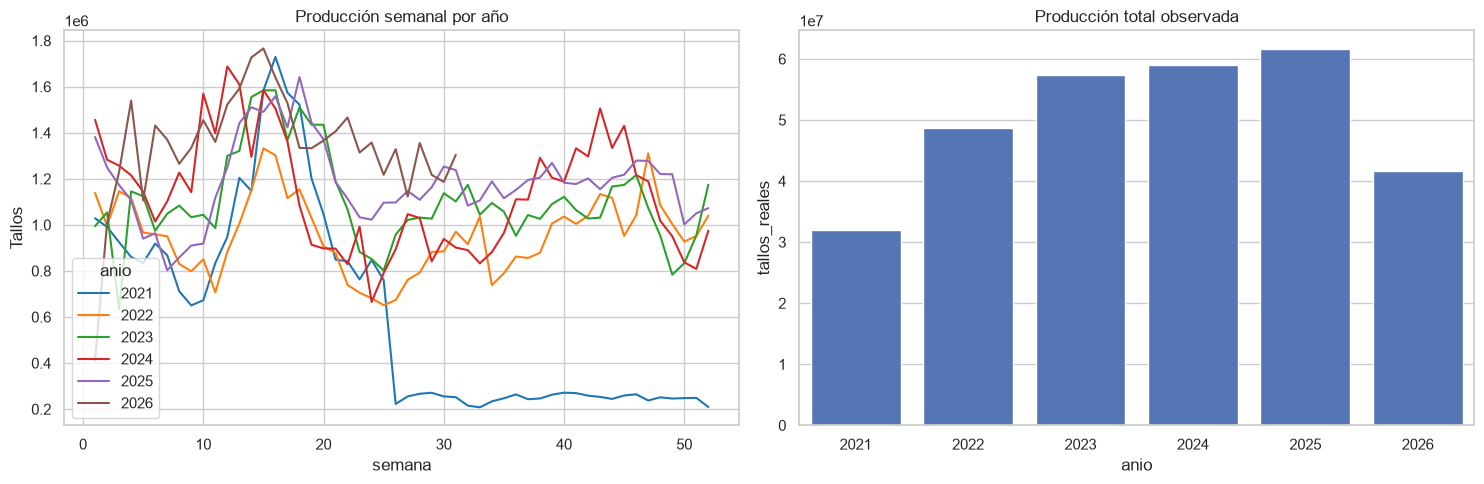

In [23]:
serie_prod = produccion.groupby(["anio","semana"], as_index=False).tallos_reales.sum()
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.lineplot(data=serie_prod, x="semana", y="tallos_reales", hue="anio", palette="tab10", ax=axes[0])
axes[0].set_title("Producción semanal por año")
axes[0].set_ylabel("Tallos")
anual = produccion.groupby("anio", as_index=False).tallos_reales.sum()
sns.barplot(data=anual, x="anio", y="tallos_reales", color="#4472C4", ax=axes[1])
axes[1].set_title("Producción total observada")
plt.tight_layout(); plt.show()

### 13.2 Mezcla productiva y concentración

,k_producto,k_color,tallos_reales,participacion_pct,participacion_acum_pct
61,MINICARNATION,LIGHT PINK,"23,654,209.00",7.88,7.88
59,MINICARNATION,HOT PINK,"20,747,289.00",6.91,14.79
62,MINICARNATION,ORANGE,"17,572,909.00",5.85,20.65
69,MINICARNATION,YELLOW,"15,991,661.00",5.33,25.97
65,MINICARNATION,RED,"15,856,621.00",5.28,31.25
68,MINICARNATION,WHITE,"15,640,022.00",5.21,36.46
60,MINICARNATION,LAVENDER,"11,309,039.00",3.77,40.23
52,MINICARNATION,BICOLOR RED,"10,511,553.00",3.50,43.73
50,MINICARNATION,BICOLOR PINK,"8,226,230.00",2.74,46.47
64,MINICARNATION,PURPLE,"7,601,398.00",2.53,49.01


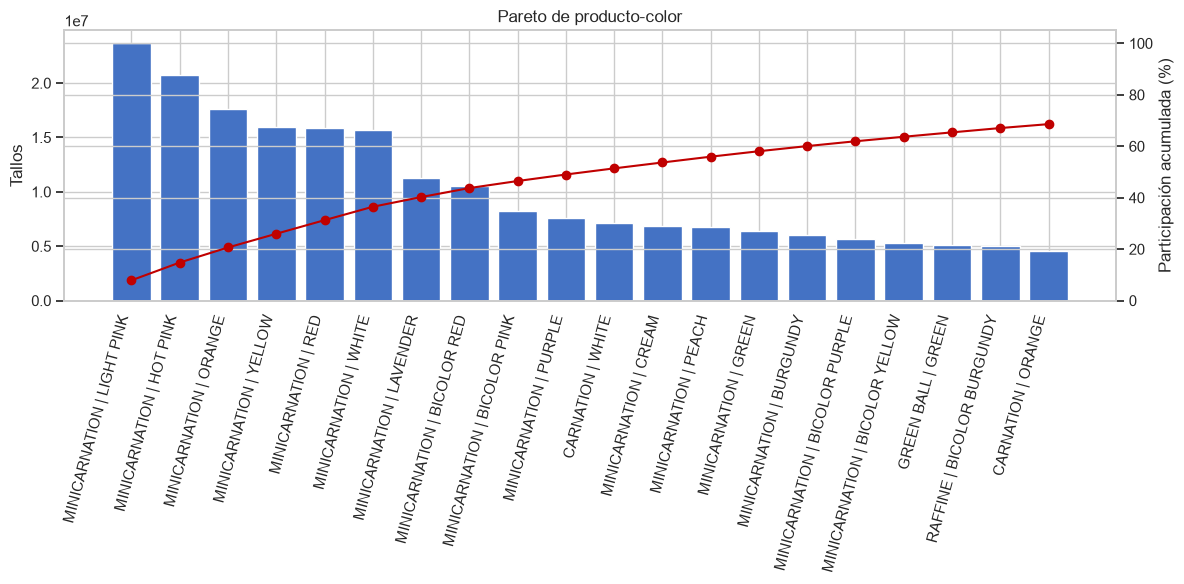

In [24]:
mezcla = (produccion.groupby(["k_producto","k_color"], as_index=False).tallos_reales.sum()
          .sort_values("tallos_reales", ascending=False))
mezcla["participacion_pct"] = 100*mezcla.tallos_reales/mezcla.tallos_reales.sum()
mezcla["participacion_acum_pct"] = mezcla.participacion_pct.cumsum()
display(mezcla.head(20))

fig, ax1 = plt.subplots(figsize=(12, 6))
top = mezcla.head(20).copy()
etiqueta = top.k_producto + " | " + top.k_color
ax1.bar(range(len(top)), top.tallos_reales, color="#4472C4")
ax1.set_xticks(range(len(top)), etiqueta, rotation=75, ha="right")
ax1.set_ylabel("Tallos")
ax2 = ax1.twinx(); ax2.plot(range(len(top)), top.participacion_acum_pct, color="#C00000", marker="o")
ax2.set_ylabel("Participación acumulada (%)"); ax2.set_ylim(0, 105)
plt.title("Pareto de producto-color")
plt.tight_layout(); plt.show()

### 13.3 Variabilidad semanal de producto-color

In [25]:
variabilidad = (produccion.groupby(["anio","semana","k_producto","k_color"], as_index=False).tallos_reales.sum()
                .groupby(["k_producto","k_color"]).agg(
                    semanas=("semana","size"), media=("tallos_reales","mean"),
                    desviacion=("tallos_reales","std"), total=("tallos_reales","sum")
                ).reset_index())
variabilidad["CV"] = variabilidad.desviacion/variabilidad.media.replace(0,np.nan)
display(variabilidad.query("semanas >= 30").sort_values("total", ascending=False).head(25))

,k_producto,k_color,semanas,media,desviacion,total,CV
61,MINICARNATION,LIGHT PINK,290,"81,566.24","35,385.80","23,654,209.00",0.43
59,MINICARNATION,HOT PINK,290,"71,542.38","34,933.40","20,747,289.00",0.49
62,MINICARNATION,ORANGE,290,"60,596.24","26,091.22","17,572,909.00",0.43
69,MINICARNATION,YELLOW,290,"55,143.66","23,119.83","15,991,661.00",0.42
65,MINICARNATION,RED,290,"54,678.00","25,246.04","15,856,621.00",0.46
68,MINICARNATION,WHITE,290,"53,931.11","25,515.64","15,640,022.00",0.47
60,MINICARNATION,LAVENDER,290,"38,996.69","16,844.37","11,309,039.00",0.43
52,MINICARNATION,BICOLOR RED,290,"36,246.73","13,286.66","10,511,553.00",0.37
50,MINICARNATION,BICOLOR PINK,290,"28,366.31","11,916.96","8,226,230.00",0.42
64,MINICARNATION,PURPLE,290,"26,211.72","11,612.59","7,601,398.00",0.44


## 14. Estimados semanales — calidad y cobertura de envíos

In [26]:
display(calidad_estimados)

def anio_semana_inicial(ruta):
    nombre = unicodedata.normalize("NFKD", ruta.stem).encode("ascii","ignore").decode().lower()
    m_sem = re.search(r"(?:sem|semana)\D*(\d{1,2})", nombre)
    anios = [int(x) for x in re.findall(r"20\d{2}", nombre)]
    carpeta = next((int(x) for x in ruta.parts if re.fullmatch(r"20\d{2}", x)), None)
    return (anios[0] if anios else carpeta), (int(m_sem.group(1)) if m_sem else None)

envios = []
for archivo in (DATOS/"Estimados semanales").rglob("*.xlsx"):
    if "datos preprocesados" in str(archivo).lower():
        continue
    anio, semana = anio_semana_inicial(archivo)
    envios.append([anio, semana, archivo.name])
envios = pd.DataFrame(envios, columns=["anio","semana_inicio","archivo"])
esperado_hasta = {2023:52, 2024:52, 2025:52, 2026:34}
faltantes = []
for anio, ultima in esperado_hasta.items():
    presentes = set(envios.loc[envios.anio==anio,"semana_inicio"].dropna().astype(int))
    for semana in sorted(set(range(1,ultima+1))-presentes):
        faltantes.append([anio,semana,f'"Estimado sem {semana:02d}" {anio}'])
faltantes = pd.DataFrame(faltantes, columns=["anio","semana_faltante","busqueda_sugerida"])
display(faltantes.groupby("anio").agg(cantidad=("semana_faltante","size"),
    semanas=("semana_faltante",lambda s:", ".join(f"{x:02d}" for x in s))).reset_index())

,anio,envios,filas,filas_estimado,horizonte_min,horizonte_max
0,2023,49,23333,"23,333.00",1,61
1,2024,49,48568,"48,568.00",1,18
2,2025,47,49863,"49,863.00",0,23
3,2026,35,26738,"26,738.00",0,9


,anio,cantidad,semanas
0,2023,5,"04, 15, 32, 42, 45"
1,2024,3,"24, 25, 33"
2,2025,5,"33, 34, 41, 42, 50"
3,2026,2,"02, 03"


### 14.1 Mapa visual de envíos presentes y faltantes

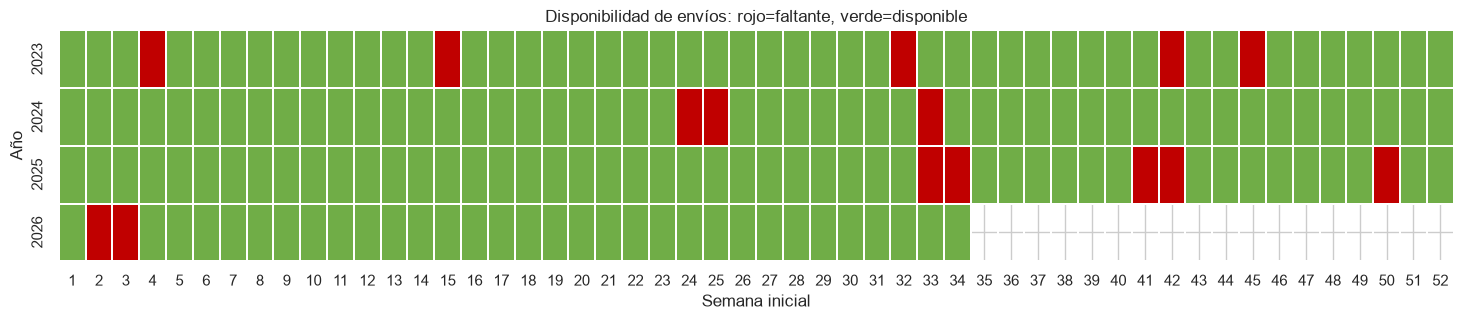

In [27]:
matriz_envios = pd.DataFrame(index=sorted(esperado_hasta), columns=range(1,53), dtype=float)
for anio in matriz_envios.index:
    ultima = esperado_hasta[anio]
    presentes = set(envios.loc[envios.anio==anio,"semana_inicio"].dropna().astype(int))
    for semana in range(1,53):
        matriz_envios.loc[anio,semana] = np.nan if semana>ultima else int(semana in presentes)
plt.figure(figsize=(18,3))
sns.heatmap(matriz_envios, cmap=["#C00000","#70AD47"], cbar=False, linewidths=.3,
            linecolor="white", mask=matriz_envios.isna())
plt.title("Disponibilidad de envíos: rojo=faltante, verde=disponible")
plt.xlabel("Semana inicial"); plt.ylabel("Año"); plt.show()

### 14.2 Horizontes contenidos en los archivos

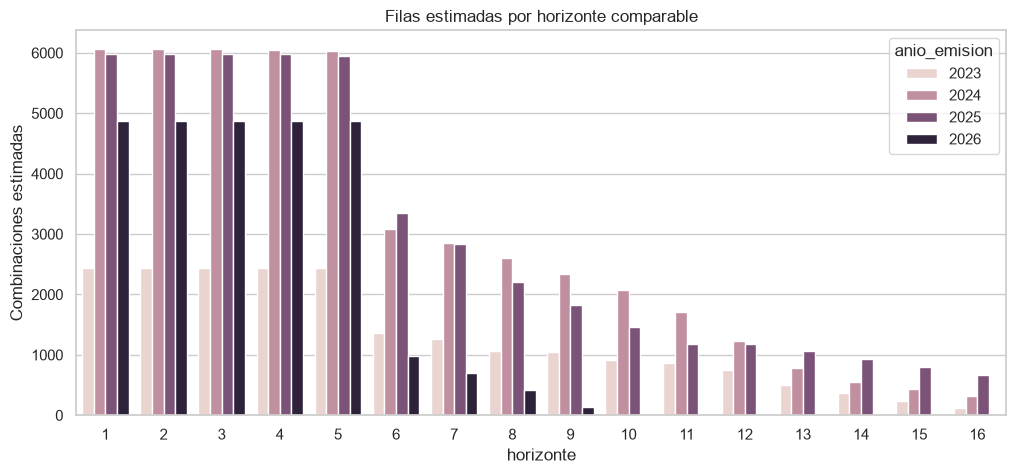

Los horizontes >16 se conservan para auditoría, pero no entran al benchmark principal.


In [28]:
horizontes = estimados[estimados.horizonte.between(1,16)].groupby(
    ["anio_emision","horizonte"], as_index=False).size()
plt.figure(figsize=(12,5))
sns.barplot(data=horizontes, x="horizonte", y="size", hue="anio_emision")
plt.title("Filas estimadas por horizonte comparable")
plt.ylabel("Combinaciones estimadas"); plt.show()
print("Los horizontes >16 se conservan para auditoría, pero no entran al benchmark principal.")

### 14.3 Versiones de una misma semana objetivo

Esta tabla comprueba que las emisiones no se mezclan. Una semana objetivo puede tener varios pronósticos realizados desde semanas de inicio diferentes. Esa secuencia permitirá medir cuánto corrige el ingeniero al acercarse la fecha.

,count,median,max
anio,,,
2023,52,5.00,14
2024,52,5.50,15
2025,52,6.00,19
2026,38,6.00,20


Ejemplo: 2026-W08 | CARNATION | YELLOW


,id_emision,semana_inicio_envio,horizonte,tallos_estimados
12,2026-W01 | Estimado sem 1 a 8 de 2026 LG+AR en...,1,8,"18,670.00"
13,2026-W04 | Estimado sem 4-8 2026 LG+AR envio.xlsx,4,5,"18,670.00"
14,2026-W05 | estimado sem 5-9 2026 LG+AR envio.xlsx,5,4,"19,040.00"
15,2026-W06 | Estimado sem 6-10 2026 LG+AR envio....,6,3,"19,020.00"
16,2026-W07 | Estimado sem 7-11 2026 LG+AR ajusta...,7,2,"20,260.00"
17,2026-W07 | Estimado sem 7-11 2026 LG+AR envio....,7,2,"19,400.00"
18,2026-W08 | Estimado sem 8-12 2026 LG+AR envio....,8,1,"19,350.00"
19,2026-W08 | estimado sem 8-12 2026 LG+AR Ajusta...,8,1,"21,090.00"
0,2025-W38 | estimado sem 38-52 2025 AR+LG envio...,38,23,"18,670.00"
1,2025-W39 | Estimado sem 39-2025 a 8-2026 LG+AR...,39,22,"18,670.00"


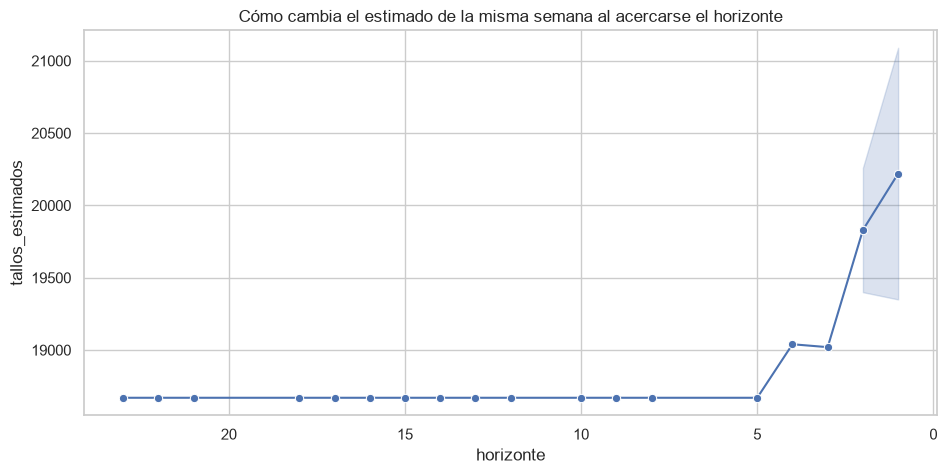

In [29]:
versiones_objetivo=(estimados.groupby(["anio","semana"],as_index=False)
    .id_emision.nunique().rename(columns={"id_emision":"versiones_disponibles"}))
display(versiones_objetivo.groupby("anio").versiones_disponibles.agg(["count","median","max"]))

conteo_pcolor=(estimados.groupby(["anio","semana","k_producto","k_color"],as_index=False)
    .id_emision.nunique().sort_values("id_emision",ascending=False))
caso=conteo_pcolor.iloc[0]
ejemplo_versiones=(estimados[
    estimados.anio.eq(caso.anio)&estimados.semana.eq(caso.semana)&
    estimados.k_producto.eq(caso.k_producto)&estimados.k_color.eq(caso.k_color)
].groupby(["id_emision","semana_inicio_envio","horizonte"],as_index=False).tallos_estimados.sum()
 .sort_values(["semana_inicio_envio","horizonte"]))
print(f"Ejemplo: {int(caso.anio)}-W{int(caso.semana):02d} | {caso.k_producto} | {caso.k_color}")
display(ejemplo_versiones)
plt.figure(figsize=(11,5))
sns.lineplot(data=ejemplo_versiones,x="horizonte",y="tallos_estimados",marker="o")
plt.gca().invert_xaxis(); plt.title("Cómo cambia el estimado de la misma semana al acercarse el horizonte")
plt.show()

## 15. Clima — calidad y EDA

In [30]:
display(calidad_clima)
display(clima.groupby("anio").agg(
    semanas=("semana","nunique"), temp_media=("temp_media","mean"),
    humedad_media=("humedad_media","mean"), lluvia=("lluvia_acumulada","sum"),
    radiacion=("radiacion_media","mean")
))

,anio,mediciones,semanas,temp_nula_pct,humedad_nula_pct,lluvia_nula_pct,radiacion_nula_pct
0,2017,29546,16,0.01,0.01,0.00,0.01
1,2018,103358,53,0.04,0.04,0.00,0.04
2,2019,86752,53,0.08,0.08,0.03,0.08
3,2020,95128,53,0.26,0.26,0.01,0.24
4,2021,86784,53,2.45,2.46,0.00,2.36
5,2022,83092,53,0.10,0.10,0.00,0.10
6,2023,65443,52,0.00,0.01,0.00,0.00
7,2024,51612,53,1.60,1.60,0.02,1.53
8,2025,34391,52,0.19,0.19,0.00,0.17
9,2026,8889,31,0.22,0.22,0.00,0.21


,semanas,temp_media,humedad_media,lluvia,radiacion
anio,,,,,
2021,53,13.76,81.12,"5,259.25",182.62
2022,53,13.46,83.42,"5,170.16",168.52
2023,52,14.20,82.09,"2,302.61",172.94
2024,53,14.53,83.78,"1,626.30",172.87
2025,52,13.99,86.52,"1,588.96",166.77
2026,31,15.39,79.85,955.13,162.19


### 15.1 Evolución semanal de señales climáticas

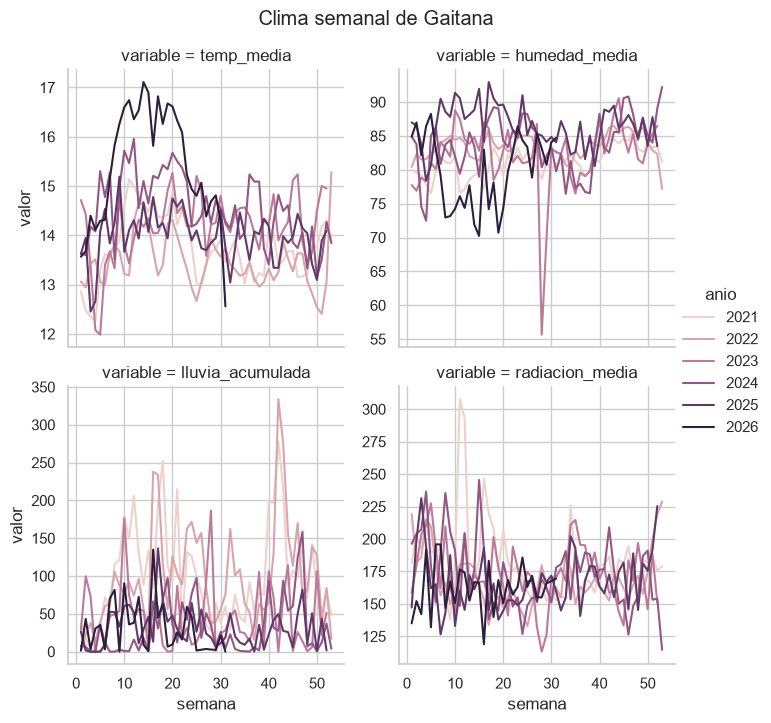

In [31]:
clima_largo = clima.melt(id_vars=["anio","semana"],
    value_vars=["temp_media","humedad_media","lluvia_acumulada","radiacion_media"],
    var_name="variable", value_name="valor")
g = sns.relplot(data=clima_largo, x="semana", y="valor", hue="anio", col="variable",
                col_wrap=2, kind="line", facet_kws={"sharey":False}, height=3.5)
g.fig.suptitle("Clima semanal de Gaitana", y=1.03)
plt.show()

## 16. Plano de Siembras — cómo leer este EDA

Este EDA no intenta demostrar todavía cuántos tallos produjo cada siembra. Primero estudia si el plan semanal es estable, completo y suficientemente confiable para usarlo después en un estimado.

La unidad observada es una fila de cama dentro de un archivo semanal. Al seguir la misma combinación `invernadero + cama + fecha_siembra` entre dos semanas, el notebook puede indicar que el registro continuó igual, apareció, cambió o dejó de aparecer. Esas categorías describen diferencias entre archivos; **no prueban por sí solas una acción física en el cultivo**.

### La idea que guía esta sección

El plan dice **qué está sembrado**: variedad, número de plantas y edad. Las Curvas dicen **cuántas flores por planta se esperan en cada edad**. Al multiplicarlas se obtiene el estimado teórico. Después, el ingeniero modifica ese resultado con su experiencia. El objetivo del notebook es separar y comparar esas dos capas.

`FECHA PRODUCCION` se conserva solamente en los archivos limpios para trazabilidad, pero se excluye deliberadamente de cálculos, gráficos y conclusiones porque no forma parte de la lógica que el equipo indicó como relevante.

In [32]:
display(calidad_siembras.tail(20))
resumen_anual_siembras = calidad_siembras.groupby("anio_foto", as_index=False).agg(
    archivos_semanales=("semana_foto","nunique"), filas_acumuladas=("filas","sum"),
    llaves_incompletas=("llaves_incompletas","sum"),
    llaves_duplicadas=("filas_con_llave_duplicada","sum"),
    cobertura_proveedor_pct=("cobertura_proveedor_pct","mean"),
)
display(resumen_anual_siembras)
display(pd.DataFrame([{
    "archivos_semanales_analizados": len(resumen_cambios),
    "versiones_adicionales_misma_semana": int((~auditoria_versiones.version_canonica).sum()),
    "siembras_identificables": len(siembras),
}]))

,anio_foto,semana_foto,fecha_foto,filas,llaves_incompletas,filas_con_llave_duplicada,cobertura_fecha_produccion_pct,cobertura_sustrato_pct,cobertura_propagador_pct,cobertura_proveedor_pct
272,2026,14,2026-03-30,7897,0,400,0.00,99.76,96.30,98.92
273,2026,15,2026-04-06,7911,0,392,0.00,99.99,96.56,98.94
274,2026,16,2026-04-13,7897,0,390,0.00,100.00,96.63,98.94
275,2026,17,2026-04-20,7850,0,385,0.00,100.00,96.71,98.93
276,2026,18,2026-04-27,7824,0,385,0.00,100.00,96.84,98.93
277,2026,19,2026-05-04,7892,0,383,0.00,100.00,97.14,98.94
278,2026,20,2026-05-11,7981,0,381,0.00,99.91,97.48,98.96
279,2026,21,2026-05-18,7975,0,371,0.00,100.00,97.49,98.96
280,2026,22,2026-05-25,8002,0,370,0.00,99.88,97.54,98.98
281,2026,23,2026-06-01,8041,0,368,0.00,99.15,97.51,98.98


,anio_foto,archivos_semanales,filas_acumuladas,llaves_incompletas,llaves_duplicadas,cobertura_proveedor_pct
0,2021,52,394304,1,23693,98.11
1,2022,51,385672,1759,30134,97.33
2,2023,52,391781,0,18959,98.91
3,2024,52,400451,36,14928,98.39
4,2025,52,408566,72,17946,99.14
5,2026,33,263374,80,12766,98.94


,archivos_semanales_analizados,versiones_adicionales_misma_semana,siembras_identificables
0,292,1,64021


**Cómo leer las tablas anteriores:** `filas_acumuladas` suma las filas observadas en todos los archivos y, por tanto, repite una cama mientras siga apareciendo. `siembras identificables` intenta contar una sola vez cada combinación provisional de invernadero, cama y fecha de siembra. No son dos medidas rivales: responden preguntas diferentes.

La tabla de calidad sirve para decidir si el Plano puede entrar a un modelo. Muchas llaves incompletas impiden seguir camas; muchas llaves duplicadas pueden multiplicar plantas; una cobertura baja de proveedor limita análisis por casa comercial. Estas métricas no miden rendimiento productivo.

La fecha de producción aparece de forma intermitente: tiene cobertura en parte de 2021, en dos fotos de 2022, una de 2023 y una de 2024; está totalmente ausente en 2025–2026. El pipeline no la inventa ni la completa mediante correlaciones.

### 16.1 Diferencias entre un archivo semanal y el anterior

Esta sección compara dos Excel consecutivos usando la llave provisional. Los términos significan exclusivamente:

- **Nuevo:** la llave aparece esta semana y no estaba en el archivo anterior. Puede ser una siembra nueva, una cama reincorporada o una corrección de identificación.
- **Sin cambio:** la llave aparece en ambas semanas y los atributos comparados son iguales.
- **Modificado:** la llave aparece en ambas, pero cambió algún campo como plantas, variedad, color o proveedor. No implica necesariamente una modificación física.
- **Desaparecido:** estaba en el archivo anterior y ya no aparece. Puede ser retiro del plan, fin de vigencia, corrección o falta de cobertura.

La columna técnica `ciclos_comparables` significa simplemente **registros que pudieron identificarse y comparar con la semana anterior**. No significa ciclos productivos demostrados.

,anio_foto,semana_foto,fecha_foto,archivo,filas,ciclos_comparables,nuevos,modificados,sin_cambio,modificados_valor,modificados_cobertura,modificados_mixtos,desaparecidos,delta_edad_mediana,edad_retrocede,comparables_con_edad
272,2026,14,2026-03-30,2026\Plano de Siembras Sem 14.xlsx,7897,7675,85,206,7384,135,70,1,90,1.00,0,7590
273,2026,15,2026-04-06,2026\Plano de Siembras Sem 15.xlsx,7911,7693,118,18,7557,0,18,0,100,1.00,0,7575
274,2026,16,2026-04-13,2026\Plano de Siembras Sem 16.xlsx,7897,7680,93,32,7555,31,1,0,106,1.00,0,7587
275,2026,17,2026-04-20,2026\Plano de Siembras Sem 17.xlsx,7850,7636,80,7,7549,7,0,0,124,1.00,0,7556
276,2026,18,2026-04-27,2026\Plano de Siembras Sem 18.xlsx,7824,7610,107,6,7497,6,0,0,133,1.00,0,7503
277,2026,19,2026-05-04,2026\Plano de Siembras Sem 19.xlsx,7892,7679,231,3,7445,3,0,0,162,1.00,0,7448
278,2026,20,2026-05-11,2026\Plano de Siembras Sem 20.xlsx,7981,7769,215,133,7421,125,8,0,125,1.00,0,7554
279,2026,21,2026-05-18,2026\Plano de Siembras Sem 21.xlsx,7975,7768,69,140,7559,132,8,0,70,1.00,0,7699
280,2026,22,2026-05-25,2026\Plano de Siembras Sem 22.xlsx,8002,7796,63,88,7645,78,10,0,35,1.00,0,7733
281,2026,23,2026-06-01,2026\Plano de Siembras Sem 23.xlsx,8041,7836,74,59,7703,1,58,0,34,1.00,0,7762


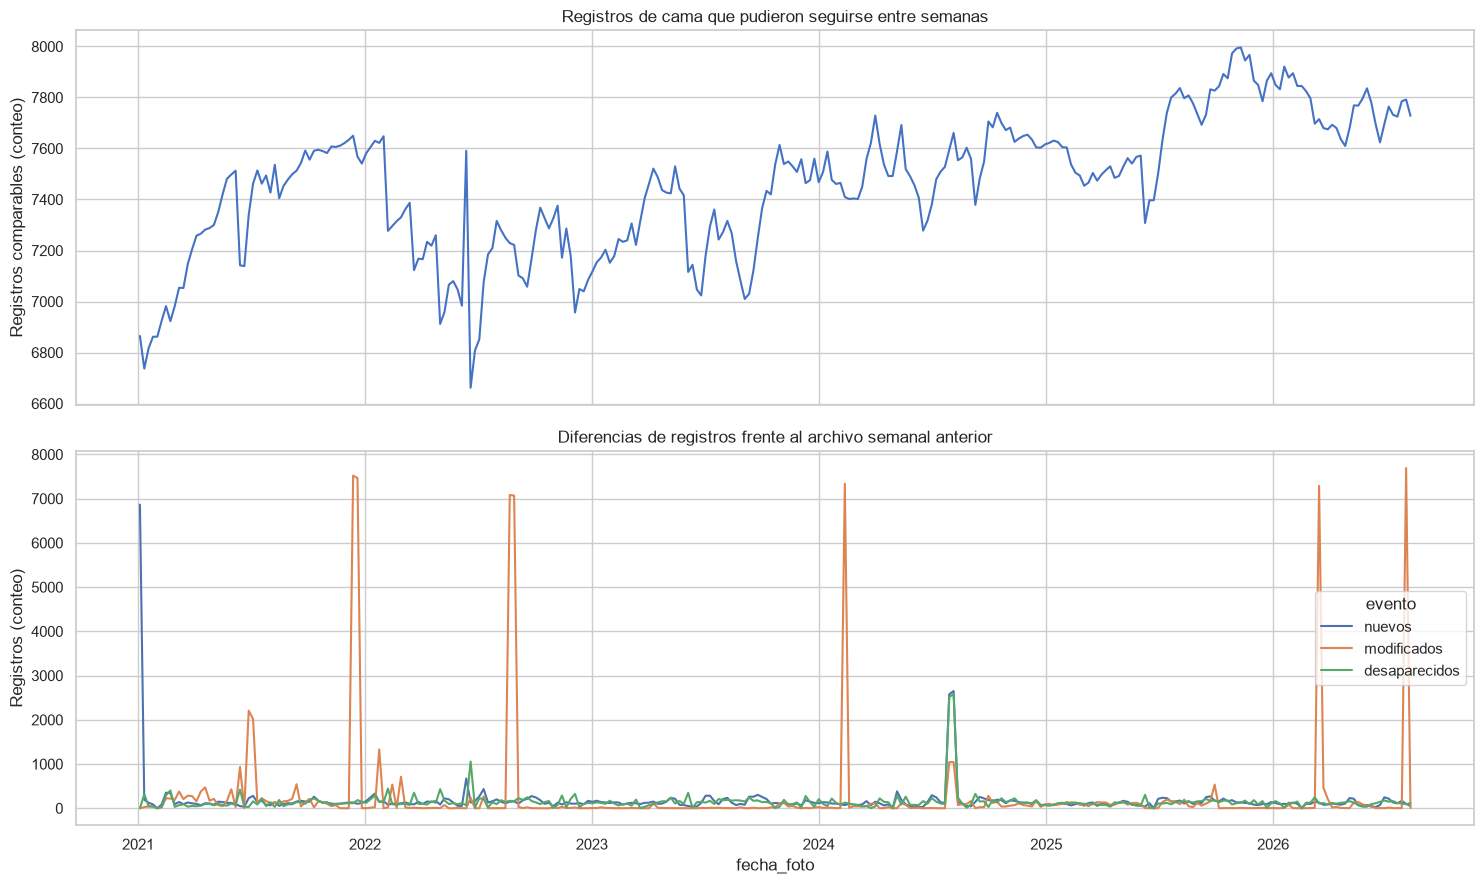

In [33]:
resumen_cambios["fecha_foto"] = pd.to_datetime(resumen_cambios.fecha_foto)
display(resumen_cambios.tail(20))
fig, axes = plt.subplots(2, 1, figsize=(15, 9), sharex=True)
resumen_cambios["registros_comparables"] = resumen_cambios["ciclos_comparables"]
sns.lineplot(data=resumen_cambios, x="fecha_foto", y="registros_comparables", ax=axes[0], color="#4472C4")
axes[0].set_title("Registros de cama que pudieron seguirse entre semanas")
axes[0].set_ylabel("Registros comparables (conteo)")
cambios_largo = resumen_cambios.melt(
    id_vars="fecha_foto", value_vars=["nuevos","modificados","desaparecidos"],
    var_name="evento", value_name="ciclos")
sns.lineplot(data=cambios_largo, x="fecha_foto", y="ciclos", hue="evento", ax=axes[1])
axes[1].set_title("Diferencias de registros frente al archivo semanal anterior")
axes[1].set_ylabel("Registros (conteo)")
plt.tight_layout(); plt.show()

### 16.2 Qué campos difieren y por qué se auditan algunas semanas

Aquí no se busca premiar o castigar una semana. Se busca detectar cambios masivos que podrían provenir de una actualización real del plan o de un cambio en la estructura/calidad del Excel.

`modificados_valor` cuenta cambios entre dos valores informados; `modificados_cobertura` indica que un campo pasó de vacío a informado o al contrario; `mixto` combina ambos. Esta separación evita llamar decisión agronómica a lo que puede ser solamente aparición o pérdida de datos.

La tasa de diferencias divide nuevos + modificados + desaparecidos entre los registros comparables. Una tasa alta es una **alerta para revisar el archivo**, no evidencia automática de que toda la finca cambió.

In [34]:
mods = historial_cambios.query("tipo_evento == 'modificado'").copy()
campos_cambiados = (mods.assign(campo=mods.campos_modificados.str.split(',')).explode("campo")
                    .groupby(["campo","tipo_modificacion"],as_index=False).size()
                    .rename(columns={"size":"cambios"}))
display(mods.tipo_modificacion.value_counts().rename_axis("tipo_modificacion").reset_index(name="eventos"))
display(campos_cambiados)
alertas_semana = resumen_cambios.assign(
    movimientos=lambda d:d.nuevos+d.modificados+d.desaparecidos,
    tasa_movimiento_pct=lambda d:100*d.movimientos/d.ciclos_comparables.replace(0,np.nan)
).sort_values("tasa_movimiento_pct", ascending=False)
display(alertas_semana.head(20))

,tipo_modificacion,eventos
0,valor,41952
1,cobertura,35358
2,mixto,690


,campo,tipo_modificacion,cambios
0,color,mixto,217
1,color,valor,31170
2,plantas,mixto,224
3,plantas,valor,1698
4,producto,mixto,33
5,producto,valor,345
6,propagador,cobertura,7377
7,propagador,mixto,8
8,propagador,valor,886
9,proveedor,cobertura,10770


,anio_foto,semana_foto,fecha_foto,archivo,filas,ciclos_comparables,nuevos,modificados,sin_cambio,modificados_valor,modificados_cobertura,modificados_mixtos,desaparecidos,delta_edad_mediana,edad_retrocede,comparables_con_edad,registros_comparables,movimientos,tasa_movimiento_pct
50,2021,51,2021-12-20,2021\Plano de Siembras Sem 51.xlsx,7944,7568,102,7466,0,7466,0,0,184,1.00,0,7466,7568,7752,102.43
84,2022,34,2022-08-22,2022\Plano de Siembras Sem 34.xlsx,7529,7229,147,7082,0,7082,0,0,168,1.00,0,7082,7229,7397,102.32
85,2022,35,2022-08-29,2022\Plano de Siembras Sem 35.xlsx,7511,7222,154,7068,0,7068,0,0,161,1.00,0,7068,7222,7383,102.23
161,2024,7,2024-02-12,2024\Plano de Siembras Sem 07.xlsx,7554,7410,72,7338,0,7336,0,2,127,1.00,0,7338,7410,7537,101.71
49,2021,50,2021-12-13,2021\Plano de Siembras Sem 50.xlsx,8025,7650,129,7521,0,7521,0,0,113,NaN,0,0,7650,7763,101.48
290,2026,32,2026-08-03,2026\Plano de Siembras Sem 32 actualizado.xlsx,7976,7792,99,7693,0,0,7689,4,92,0.00,0,7693,7792,7884,101.18
0,2021,1,2021-01-04,2021\Plano de Siembras Sem 01.xlsx,6953,6865,6865,0,0,0,0,0,0,NaN,0,0,6865,6865,100.00
270,2026,12,2026-03-16,2026\Plano de Siembras Sem 12.xlsx,7951,7715,127,7290,298,0,7286,4,109,1.00,0,7588,7715,7526,97.55
186,2024,32,2024-08-05,2024\Plano de Siembras Sem 32.xlsx,7822,7661,2650,1044,3967,17,945,82,2583,1.00,0,4026,7661,6277,81.93
185,2024,31,2024-07-29,2024\Plano de Siembras Sem 31.xlsx,7762,7594,2577,1043,3974,15,946,82,2511,1.00,0,4032,7594,6131,80.73


### 16.3 Plantas registradas por producto en cada semana

Esta gráfica responde: **¿cuántas plantas decía el archivo semanal que estaban registradas para cada producto?** El eje vertical está en plantas, no en tallos ni flores.

Una subida puede reflejar nuevas siembras o registros incorporados; una caída puede reflejar camas retiradas o pérdida de cobertura. La gráfica describe el plan reportado y no demuestra por sí sola mortalidad, producción ni cosecha. Saltos abruptos deben contrastarse con las alertas de calidad de la sección anterior.

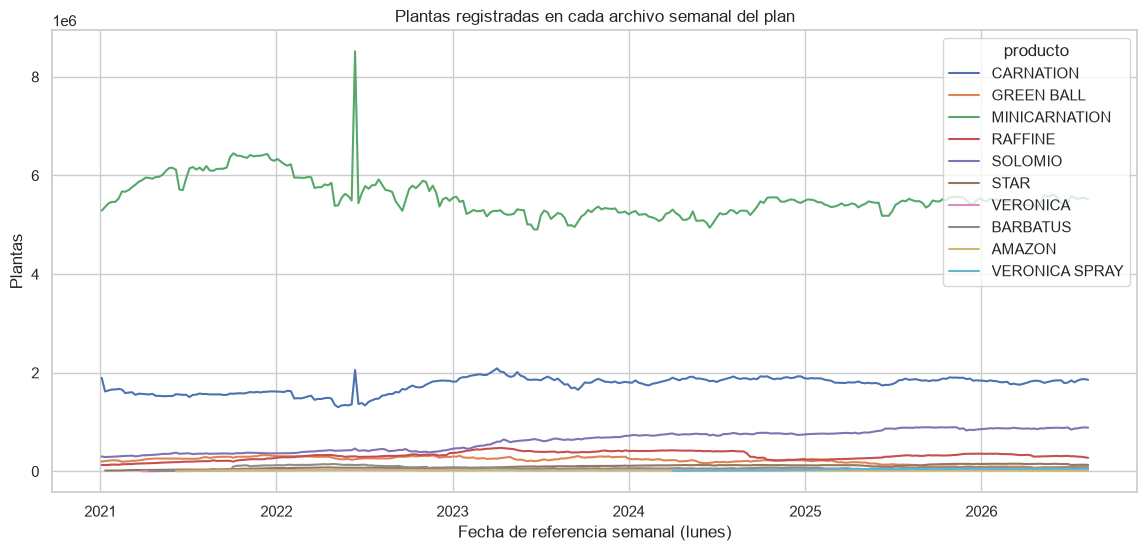

In [35]:
siembras_fotos["fecha_foto"] = pd.to_datetime(siembras_fotos.fecha_foto)
top_productos = siembras_fotos.groupby("producto").plantas.sum().nlargest(10).index
plt.figure(figsize=(14,6))
sns.lineplot(data=siembras_fotos[siembras_fotos.producto.isin(top_productos)],
             x="fecha_foto", y="plantas", hue="producto")
plt.title("Plantas registradas en cada archivo semanal del plan")
plt.xlabel("Fecha de referencia semanal (lunes)")
plt.ylabel("Plantas"); plt.show()

### 16.4 ¿La edad de una misma siembra avanza de forma coherente?

Si una misma siembra aparece en dos archivos semanales consecutivos, su edad debería aumentar aproximadamente una semana. La gráfica muestra la mediana del cambio reportado en `EDAD` entre archivos.

Un valor cercano a +1 es coherente con una edad expresada en semanas. Cero, retrocesos o saltos grandes pueden indicar que la llave unió registros distintos, que el Excel recalculó la edad con otra regla o que hubo una corrección. Por eso esta prueba valida consistencia; no estima duración hasta producción.

,anio_foto,semana_foto,delta_edad_mediana,edad_retrocede,comparables_con_edad
262,2026,4,1.00,0,7821
263,2026,5,1.00,0,7793
264,2026,6,1.00,0,7766
265,2026,7,1.00,0,7743
266,2026,8,0.00,0,7845
267,2026,9,1.00,0,7721
268,2026,10,1.00,0,7700
269,2026,11,2.00,0,7549
270,2026,12,1.00,0,7588
271,2026,13,1.00,0,7600


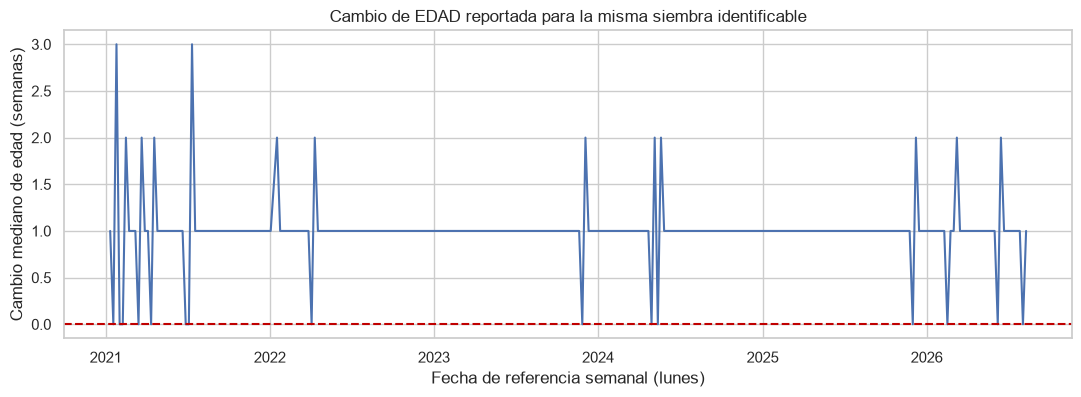

In [36]:
if "delta_edad_mediana" in resumen_cambios:
    display(resumen_cambios[["anio_foto","semana_foto","delta_edad_mediana",
                              "edad_retrocede","comparables_con_edad"]].tail(30))
    plt.figure(figsize=(13,4))
    sns.lineplot(data=resumen_cambios, x="fecha_foto", y="delta_edad_mediana")
    plt.axhline(0, color="#C00000", linestyle="--")
    plt.title("Cambio de EDAD reportada para la misma siembra identificable")
    plt.xlabel("Fecha de referencia semanal (lunes)")
    plt.ylabel("Cambio mediano de edad (semanas)")
    plt.show()
else:
    print("Reejecute la limpieza de siembras para materializar la auditoría de EDAD.")

# PARTE IV — CURVAS DE PRODUCCIÓN: PREPARACIÓN, EDA Y RÉPLICA DEL ESTIMADO

Este notebook incorpora los libros de `Curvas por variedad` sin modificar los originales. La secuencia es deliberada:

**datos crudos → bases limpias → bases consolidadas y auditorías → EDA → estimación a cinco semanas → comparación**.

La unidad central es **flores por planta en una semana de edad**. La predicción se expresa en **tallos**, mediante `plantas × flores/planta`. No se usa el anterior “ciclo observable” ni se convierten resultados a tallos/m²/año: las fechas de producción y los factores de área/aprovechamiento requieren validación de negocio.

## 1. Preguntas, alcance y reglas de medición

1. ¿Qué contienen `Base de Datos` y `Camas Piloto` y con qué cobertura?
2. ¿Qué proporción de observaciones puede relacionarse con una cama piloto sin ambigüedad?
3. ¿Cómo cambia `Flor/Planta` con la edad, variedad, color y año?
4. ¿Cuántas camas y observaciones sostienen cada punto de una curva?
5. ¿La regla `plantas × flores/planta` reproduce el estimado histórico del ingeniero?

Reglas: no se inventan matches, los aproximados solo se auditan, no se promedian magnitudes incompatibles y toda gráfica declara unidad, población y nivel de agregación.

In [37]:
from pathlib import Path
from contextlib import contextmanager
from tempfile import TemporaryDirectory
import hashlib, json, re, shutil, unicodedata, warnings, zipfile
from itertools import chain

import duckdb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from openpyxl import load_workbook
from IPython.display import display, Markdown

warnings.filterwarnings("ignore", category=UserWarning, module="openpyxl")
pd.set_option("display.max_columns", 80)
sns.set_theme(style="whitegrid")

ROOT = Path.cwd().resolve()
if not (ROOT / "Datos").exists():
    ROOT = ROOT.parent.resolve()
DATOS = ROOT / "Datos"
CRUDOS = DATOS / "Curvas por variedad"
PRE = CRUDOS / "datos preprocesados"
LIMPIAS = PRE / "bases limpias"
CONSOLIDADAS = PRE / "bases consolidadas"
AUDITORIA = PRE / "auditoria"
CONTROL = PRE / "_control"
for carpeta in [LIMPIAS, CONSOLIDADAS, AUDITORIA, CONTROL]:
    carpeta.mkdir(parents=True, exist_ok=True)

print("Raíz:", ROOT)
print("Fuente cruda:", CRUDOS)
print("Salida:", PRE)

Raíz: C:\Materias y Cosas Técnicas Uniandes\Proyecto de grado\Proyecto de grado 2
Fuente cruda: C:\Materias y Cosas Técnicas Uniandes\Proyecto de grado\Proyecto de grado 2\Datos\Curvas por variedad
Salida: C:\Materias y Cosas Técnicas Uniandes\Proyecto de grado\Proyecto de grado 2\Datos\Curvas por variedad\datos preprocesados


## 2. Inventario de libros y hojas

Se excluyen archivos temporales `~$`. El inventario conserva tamaño, año de carpeta y familia declarada en el nombre. Algunos libros contienen nombres de impresión inválidos; la utilidad siguiente repara únicamente una copia temporal para poder leerlos, nunca el original.

In [38]:
def texto_normalizado(valor):
    if pd.isna(valor):
        return ""
    valor = unicodedata.normalize("NFKD", str(valor))
    valor = valor.encode("ascii", "ignore").decode("ascii").upper().strip()
    return re.sub(r"\s+", " ", valor)

def nombre_columna(valor):
    valor = texto_normalizado(valor).lower()
    valor = re.sub(r"[^a-z0-9]+", "_", valor).strip("_")
    return valor or "columna_sin_nombre"

def familia_archivo(nombre):
    n = texto_normalizado(nombre)
    if "MINI" in n: return "MINICLAVEL"
    if "GREEN BALL" in n: return "GREEN BALL"
    if "RAFFINE" in n or "SOLOMIO" in n: return "RAFFINE/SOLOMIO/OTROS"
    if "CLAVEL" in n: return "CLAVEL"
    return "OTROS"

def huella(path):
    h = hashlib.sha256()
    with path.open("rb") as fh:
        for bloque in iter(lambda: fh.read(1024 * 1024), b""):
            h.update(bloque)
    return h.hexdigest()

@contextmanager
def libro_legible(path):
    """Devuelve original o copia técnica sin definedNames inválidos (#N/A)."""
    try:
        wb = load_workbook(path, read_only=True, data_only=True, keep_links=False)
        wb.close()
        yield path, False
        return
    except ValueError as exc:
        if "assign names" not in str(exc):
            raise
    carpeta_reparada = CONTROL / "copias_lectura_reparadas" / path.parent.name
    carpeta_reparada.mkdir(parents=True, exist_ok=True)
    destino = carpeta_reparada / path.name
    if not destino.exists() or destino.stat().st_mtime_ns < path.stat().st_mtime_ns:
        with zipfile.ZipFile(path, "r") as zin, zipfile.ZipFile(destino, "w", zipfile.ZIP_DEFLATED) as zout:
            for item in zin.infolist():
                contenido = zin.read(item.filename)
                if item.filename == "xl/workbook.xml":
                    texto = contenido.decode("utf-8")
                    texto = re.sub(r'<definedName[^>]*>[^<]*#N/A[^<]*</definedName>', '', texto)
                    contenido = texto.encode("utf-8")
                zout.writestr(item, contenido)
    yield destino, True

libros = [p for p in sorted(CRUDOS.glob("*/*.xlsx")) if not p.name.startswith("~$")]
inventario = pd.DataFrame({
    "archivo": [p.name for p in libros],
    "ruta_relativa": [p.relative_to(ROOT).as_posix() for p in libros],
    "anio_archivo": [int(p.parent.name) for p in libros],
    "familia_archivo": [familia_archivo(p.name) for p in libros],
    "tamano_mb": [p.stat().st_size / 1024**2 for p in libros],
    "sha256": [huella(p) for p in libros],
})
inventario.to_csv(AUDITORIA / "inventario_libros.csv", index=False, encoding="utf-8-sig")
display(inventario.groupby(["anio_archivo", "familia_archivo"], as_index=False).agg(libros=("archivo", "size"), mb=("tamano_mb", "sum")))

,anio_archivo,familia_archivo,libros,mb
0,2021,CLAVEL,1,76.56
1,2021,GREEN BALL,1,3.16
2,2021,MINICLAVEL,1,81.47
3,2021,RAFFINE/SOLOMIO/OTROS,1,56.64
4,2022,CLAVEL,1,93.53
5,2022,GREEN BALL,1,4.35
6,2022,MINICLAVEL,1,84.27
7,2022,RAFFINE/SOLOMIO/OTROS,1,61.69
8,2023,CLAVEL,1,93.00
9,2023,GREEN BALL,1,4.64


## 3. Extracción incremental de las dos hojas fuente

`Base de Datos` es longitudinal: cada fila representa producción semanal observada de una cama. `Camas Piloto` describe camas y plantas. Se exporta un CSV por libro y hoja para conservar trazabilidad y evitar un único archivo inmanejable.

Las fórmulas se leen usando el valor calculado guardado por Excel. Una fila se conserva si tiene al menos un valor en las columnas de negocio. Cada salida agrega año, familia, archivo, hoja y fila original.

In [39]:
def hoja_por_nombre(wb, esperado):
    objetivo = texto_normalizado(esperado)
    candidatos = [s for s in wb.sheetnames if texto_normalizado(s) == objetivo]
    # Green Ball usa "corte semanal" para la misma tabla longitudinal.
    if not candidatos and objetivo == "BASE DE DATOS":
        candidatos = [s for s in wb.sheetnames if texto_normalizado(s) == "CORTE SEMANAL"]
    if len(candidatos) != 1:
        raise KeyError(f"Se esperaba una hoja {esperado!r}; encontradas: {candidatos}")
    return candidatos[0]

def filas_hoja(path, hoja_esperada, metadatos):
    with libro_legible(path) as (ruta_lectura, reparado):
        wb = load_workbook(ruta_lectura, read_only=True, data_only=True, keep_links=False)
        nombre = hoja_por_nombre(wb, hoja_esperada)
        ws = wb[nombre]
        ws.reset_dimensions()
        it = ws.iter_rows(values_only=True)
        primeras = []
        for _ in range(10):
            try: primeras.append(next(it))
            except StopIteration: break
        marcadores = ({"REFERENCIA","VARIEDAD","NO. BLOQUE","NO. CAMA","NO. PLANTAS"}
                       if texto_normalizado(hoja_esperada) == "CAMAS PILOTO"
                       else {"CAMA PILOTO","CODIGO","CORTE SEMANAL","VARIEDAD","EDAD","FLOR/PLANTA","FLORES X PLANTA"})
        puntajes = [sum(texto_normalizado(v) in marcadores for v in fila if v is not None) for fila in primeras]
        indice_encabezado = int(np.argmax(puntajes))
        encabezado_original = primeras[indice_encabezado]
        encabezados = []
        usados = {}
        for valor in encabezado_original:
            base = nombre_columna(valor)
            usados[base] = usados.get(base, 0) + 1
            encabezados.append(base if usados[base] == 1 else f"{base}_{usados[base]}")
        filas = []
        restantes = chain(primeras[indice_encabezado + 1:], it)
        for numero, fila in enumerate(restantes, indice_encabezado + 2):
            fila = tuple(fila[:len(encabezados)])
            if not any(v is not None and str(v).strip() != "" for v in fila):
                continue
            registro = dict(zip(encabezados, fila))
            registro.update(metadatos)
            registro["hoja_origen"] = nombre
            registro["fila_excel"] = numero
            filas.append(registro)
        wb.close()
    return pd.DataFrame(filas), reparado, list(encabezado_original)

manifest_path = CONTROL / "manifest_extraccion.json"
manifest = json.loads(manifest_path.read_text(encoding="utf-8")) if manifest_path.exists() else {}
auditoria_extraccion = []

for i, path in enumerate(libros, 1):
    meta = {
        "anio_archivo": int(path.parent.name),
        "familia_archivo": familia_archivo(path.name),
        "archivo_origen": path.name,
        "ruta_origen": path.relative_to(ROOT).as_posix(),
    }
    clave = path.relative_to(ROOT).as_posix()
    token = inventario.loc[inventario.ruta_relativa.eq(clave), "sha256"].iloc[0]
    version_pipeline = "v2_deteccion_encabezado"
    slug = nombre_columna(path.stem)
    salidas = {"Base de Datos": LIMPIAS / f"{path.parent.name}_{slug}_base_datos.csv",
               "Camas Piloto": LIMPIAS / f"{path.parent.name}_{slug}_camas_piloto.csv"}
    vigente = (manifest.get(clave, {}).get("sha256") == token
               and manifest.get(clave, {}).get("version_pipeline") == version_pipeline
               and all(p.exists() for p in salidas.values()))
    if vigente:
        for hoja, salida in salidas.items():
            auditoria_extraccion.append({**meta, "hoja": hoja, "estado": "reutilizado", "salida": salida.name})
        print(f"[{i:02d}/{len(libros)}] reutilizado: {path.name}")
        continue
    reparado_alguna = False
    for hoja, salida in salidas.items():
        tabla, reparado, columnas_originales = filas_hoja(path, hoja, meta)
        reparado_alguna |= reparado
        tabla.to_csv(salida, index=False, encoding="utf-8-sig")
        auditoria_extraccion.append({**meta, "hoja": hoja, "estado": "extraido", "filas": len(tabla),
                                     "columnas": len(tabla.columns), "xml_reparado_en_copia": reparado,
                                     "salida": salida.name, "encabezados_originales": json.dumps(columnas_originales, default=str, ensure_ascii=False)})
    manifest[clave] = {"sha256": token, "version_pipeline": version_pipeline,
                       "salidas": [p.name for p in salidas.values()]}
    manifest_path.write_text(json.dumps(manifest, indent=2, ensure_ascii=False), encoding="utf-8")
    print(f"[{i:02d}/{len(libros)}] extraído: {path.name}; copia reparada={reparado_alguna}")

auditoria_extraccion = pd.DataFrame(auditoria_extraccion)
auditoria_extraccion.to_csv(AUDITORIA / "auditoria_extraccion.csv", index=False, encoding="utf-8-sig")
display(auditoria_extraccion)

[01/24] reutilizado: Estadisticas Clavel 2021.xlsx
[02/24] reutilizado: Estadisticas Green Ball 2021.xlsx
[03/24] reutilizado: Estadisticas Mini Clavel 2021 (Reparado).xlsx
[04/24] reutilizado: Estadisticas Raffine, Solomio, Otros 2021.xlsx
[05/24] reutilizado: Estadisticas Clavel 2022.xlsx
[06/24] reutilizado: Estadisticas Green Ball 2022.xlsx
[07/24] reutilizado: Estadisticas Mini Clavel 2022.xlsx
[08/24] reutilizado: Estadisticas Raffine, Solomio, Otros 2022.xlsx
[09/24] reutilizado: Estadisticas Clavel 2023.xlsx
[10/24] reutilizado: Estadisticas Green Ball 2023.xlsx
[11/24] reutilizado: Estadisticas Mini Clavel 2023.xlsx
[12/24] reutilizado: Estadisticas Raffine, Solomio, Otros 2023.xlsx
[13/24] reutilizado: Estadisticas Clavel 2024.xlsx
[14/24] reutilizado: Estadisticas Green Ball 2024.xlsx
[15/24] reutilizado: Estadisticas Miniclavel 2024.xlsx
[16/24] reutilizado: Estadisticas Raffine, Solomio, Otros 2024.xlsx
[17/24] reutilizado: Estadisticas Clavel 2025.xlsx
[18/24] reutilizado

,anio_archivo,familia_archivo,archivo_origen,ruta_origen,hoja,estado,salida
0,2021,CLAVEL,Estadisticas Clavel 2021.xlsx,Datos/Curvas por variedad/2021/Estadisticas Cl...,Base de Datos,reutilizado,2021_estadisticas_clavel_2021_base_datos.csv
1,2021,CLAVEL,Estadisticas Clavel 2021.xlsx,Datos/Curvas por variedad/2021/Estadisticas Cl...,Camas Piloto,reutilizado,2021_estadisticas_clavel_2021_camas_piloto.csv
2,2021,GREEN BALL,Estadisticas Green Ball 2021.xlsx,Datos/Curvas por variedad/2021/Estadisticas Gr...,Base de Datos,reutilizado,2021_estadisticas_green_ball_2021_base_datos.csv
3,2021,GREEN BALL,Estadisticas Green Ball 2021.xlsx,Datos/Curvas por variedad/2021/Estadisticas Gr...,Camas Piloto,reutilizado,2021_estadisticas_green_ball_2021_camas_piloto...
4,2021,MINICLAVEL,Estadisticas Mini Clavel 2021 (Reparado).xlsx,Datos/Curvas por variedad/2021/Estadisticas Mi...,Base de Datos,reutilizado,2021_estadisticas_mini_clavel_2021_reparado_ba...
5,2021,MINICLAVEL,Estadisticas Mini Clavel 2021 (Reparado).xlsx,Datos/Curvas por variedad/2021/Estadisticas Mi...,Camas Piloto,reutilizado,2021_estadisticas_mini_clavel_2021_reparado_ca...
6,2021,RAFFINE/SOLOMIO/OTROS,"Estadisticas Raffine, Solomio, Otros 2021.xlsx",Datos/Curvas por variedad/2021/Estadisticas Ra...,Base de Datos,reutilizado,2021_estadisticas_raffine_solomio_otros_2021_b...
7,2021,RAFFINE/SOLOMIO/OTROS,"Estadisticas Raffine, Solomio, Otros 2021.xlsx",Datos/Curvas por variedad/2021/Estadisticas Ra...,Camas Piloto,reutilizado,2021_estadisticas_raffine_solomio_otros_2021_c...
8,2022,CLAVEL,Estadisticas Clavel 2022.xlsx,Datos/Curvas por variedad/2022/Estadisticas Cl...,Base de Datos,reutilizado,2022_estadisticas_clavel_2022_base_datos.csv
9,2022,CLAVEL,Estadisticas Clavel 2022.xlsx,Datos/Curvas por variedad/2022/Estadisticas Cl...,Camas Piloto,reutilizado,2022_estadisticas_clavel_2022_camas_piloto.csv


## 4. Lectura consolidada y diccionario de unidades

Las bases limpias se consultan con DuckDB para no cargar todos los CSV en memoria. Se crea una tabla analítica compacta solo con variables relevantes y tipos explícitos.

| Campo | Interpretación operativa | Unidad usada |
|---|---|---|
| `corte_semanal` | producción semanal registrada | tallos/semana |
| `flor_planta` | corte semanal dividido por plantas atribuibles | flores/planta/semana |
| `edad` | tiempo desde siembra reportado por el libro | semanas |
| `no_plantas` | plantas de la cama piloto | plantas |
| `indice_prod` | indicador heredado del Excel | no se usa hasta validar definición |

In [40]:
con = duckdb.connect()
patron_base = (LIMPIAS / "*_base_datos.csv").as_posix()
patron_camas = (LIMPIAS / "*_camas_piloto.csv").as_posix()
con.execute(f"CREATE OR REPLACE VIEW curvas_raw AS SELECT * FROM read_csv_auto('{patron_base}', union_by_name=true, ignore_errors=true)")
con.execute(f"CREATE OR REPLACE VIEW camas_raw AS SELECT * FROM read_csv_auto('{patron_camas}', union_by_name=true, ignore_errors=true)")

curvas = con.execute("""
SELECT archivo_origen, ruta_origen, anio_archivo, familia_archivo, fila_excel,
       TRIM(COALESCE(CAST(cama_piloto AS VARCHAR), CAST(codigo AS VARCHAR))) cama_piloto_original,
       TRY_CAST(bloque AS INTEGER) bloque, TRY_CAST(cama AS INTEGER) cama,
       TRY_CAST(ano_corte AS INTEGER) anio_corte, TRY_CAST(semana_corte AS INTEGER) semana_corte,
       TRY_CAST(corte_semanal AS DOUBLE) corte_semanal_tallos,
       TRIM(CAST(variedad AS VARCHAR)) variedad_original, TRIM(CAST(color AS VARCHAR)) color_original,
       TRY_CAST(edad AS DOUBLE) edad_semanas,
       COALESCE(TRY_CAST(indice_prod AS DOUBLE), TRY_CAST(indice_de_produccion AS DOUBLE)) indice_prod_original,
       COALESCE(TRY_CAST(flor_planta AS DOUBLE), TRY_CAST(flores_x_planta AS DOUBLE)) flores_planta_semana,
       TRY_CAST(fecha_de_siembra AS DATE) fecha_siembra,
       TRIM(CAST(sustrato AS VARCHAR)) sustrato
FROM curvas_raw
WHERE COALESCE(CAST(cama_piloto AS VARCHAR), CAST(codigo AS VARCHAR)) IS NOT NULL
   OR variedad IS NOT NULL OR corte_semanal IS NOT NULL
   OR COALESCE(TRY_CAST(flor_planta AS DOUBLE), TRY_CAST(flores_x_planta AS DOUBLE)) IS NOT NULL
""").df()

camas = con.execute("""
SELECT archivo_origen, ruta_origen, anio_archivo, familia_archivo, fila_excel,
       TRIM(CAST(referencia AS VARCHAR)) referencia_original,
       TRIM(CAST(variedad AS VARCHAR)) variedad_original, TRIM(CAST(color AS VARCHAR)) color_original,
       TRY_CAST(no_bloque AS INTEGER) bloque, TRY_CAST(no_cama AS INTEGER) cama,
       TRY_CAST(fecha_de_siembra AS DATE) fecha_siembra,
       TRY_CAST(no_plantas AS DOUBLE) plantas,
       TRY_CAST(inicio_prod AS DOUBLE) inicio_produccion_original,
       TRY_CAST(densidad_de_siembra AS DOUBLE) densidad_original,
       TRY_CAST(plantas_del_lote AS DOUBLE) plantas_lote,
       TRIM(CAST(sustrato AS VARCHAR)) sustrato
FROM camas_raw WHERE referencia IS NOT NULL OR variedad IS NOT NULL
""").df()

for tabla in [curvas, camas]:
    tabla["k_variedad"] = tabla.variedad_original.map(texto_normalizado)
    tabla["k_color"] = tabla.color_original.map(texto_normalizado)
curvas["k_cama_piloto"] = curvas.cama_piloto_original.map(texto_normalizado)
camas["k_referencia"] = camas.referencia_original.map(texto_normalizado)

print(f"Curvas: {len(curvas):,} observaciones; camas: {len(camas):,} registros")
display(curvas[["corte_semanal_tallos","edad_semanas","flores_planta_semana"]].describe(percentiles=[.01,.25,.5,.75,.99]).T)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Curvas: 2,347,275 observaciones; camas: 141,797 registros


,count,mean,std,min,1%,25%,50%,75%,99%,max
corte_semanal_tallos,"2,345,026.00",213.11,278.87,0.00,0.00,13.00,120.00,288.00,"1,275.00","11,899.00"
edad_semanas,"2,296,588.00",44.17,59.59,-575.00,-30.00,30.00,44.00,59.00,174.00,686.00
flores_planta_semana,"2,304,444.00",0.19,0.26,0.00,0.00,0.01,0.11,0.25,1.12,11.22


## 5. Calidad de la llave `Cama Piloto`

La relación se evalúa dentro del mismo archivo: un libro anual es una fotografía acumulada y no debe cruzarse ciegamente con la hoja de otro año. El match confirmado exige igualdad exacta tras normalizar espacios, tildes y mayúsculas. Las referencias duplicadas son ambiguas y no se expanden.

In [41]:
conteo_ref = (camas.groupby(["archivo_origen","k_referencia"], as_index=False)
              .agg(candidatos=("fila_excel","size"), filas_cama=("fila_excel","size")))
conteo_ref_fecha = (camas.groupby(["archivo_origen","k_referencia","fecha_siembra"], as_index=False,dropna=False)
                    .agg(candidatos_fecha=("fila_excel","size")))
curvas["k_componentes"] = (curvas.k_variedad + "|" + curvas.bloque.astype("Int64").astype(str)
                            + "|" + curvas.cama.astype("Int64").astype(str))
camas["k_componentes"] = (camas.k_variedad + "|" + camas.bloque.astype("Int64").astype(str)
                           + "|" + camas.cama.astype("Int64").astype(str))
conteo_componentes = (camas.groupby(["archivo_origen","k_componentes"],as_index=False)
                      .agg(candidatos_componentes=("fila_excel","size")))
curvas_match = curvas.merge(conteo_ref, left_on=["archivo_origen","k_cama_piloto"],
                            right_on=["archivo_origen","k_referencia"], how="left")
curvas_match = curvas_match.merge(conteo_ref_fecha,
    left_on=["archivo_origen","k_cama_piloto","fecha_siembra"],
    right_on=["archivo_origen","k_referencia","fecha_siembra"],how="left",suffixes=("","_fecha"))
curvas_match = curvas_match.merge(conteo_componentes,on=["archivo_origen","k_componentes"],how="left")
curvas_match["estado_match"] = np.select(
    [curvas_match.candidatos.eq(1), curvas_match.candidatos_fecha.eq(1),
     curvas_match.candidatos_componentes.eq(1), curvas_match.k_cama_piloto.eq(""),
     curvas_match.candidatos.gt(1)],
    ["match_exacto_normalizado", "match_referencia_fecha", "match_componentes_variedad_bloque_cama",
     "llave_nula", "ambiguo"], default="sin_match")

resumen_match = (curvas_match.groupby(["anio_archivo","familia_archivo","estado_match"], as_index=False)
                 .agg(observaciones=("fila_excel","size"), camas_distintas=("k_cama_piloto","nunique")))
totales = resumen_match.groupby(["anio_archivo","familia_archivo"])["observaciones"].transform("sum")
resumen_match["porcentaje"] = 100 * resumen_match.observaciones / totales
resumen_match.to_csv(AUDITORIA / "resumen_calidad_match.csv", index=False, encoding="utf-8-sig")

sin_match = curvas_match.loc[curvas_match.estado_match.isin(["llave_nula","sin_match","ambiguo"]),
    ["archivo_origen","anio_archivo","familia_archivo","fila_excel","cama_piloto_original","k_cama_piloto",
     "variedad_original","color_original","estado_match","candidatos"]]
sin_match.to_csv(AUDITORIA / "observaciones_sin_match_o_ambiguas.csv", index=False, encoding="utf-8-sig")
duplicadas = camas.merge(conteo_ref.query("candidatos > 1"), on=["archivo_origen","k_referencia"], how="inner")
duplicadas.to_csv(AUDITORIA / "referencias_cama_duplicadas.csv", index=False, encoding="utf-8-sig")
display(resumen_match)

confirmados = resumen_match[resumen_match.estado_match.str.startswith("match")].observaciones.sum()
total_match = resumen_match.observaciones.sum()
ambiguos = resumen_match.loc[resumen_match.estado_match.eq("ambiguo"),"observaciones"].sum()
print(f"Conclusión automática: {100*confirmados/total_match:.2f}% de observaciones queda enlazado sin ambigüedad; "
      f"{100*ambiguos/total_match:.2f}% conserva más de una cama candidata y no se expande.")

,anio_archivo,familia_archivo,estado_match,observaciones,camas_distintas,porcentaje
0,2021,CLAVEL,ambiguo,11138,283,12.02
1,2021,CLAVEL,match_exacto_normalizado,79045,2053,85.33
2,2021,CLAVEL,match_referencia_fecha,2453,63,2.65
3,2021,GREEN BALL,ambiguo,796,62,25.46
4,2021,GREEN BALL,match_exacto_normalizado,1801,222,57.60
5,2021,GREEN BALL,match_referencia_fecha,218,14,6.97
6,2021,GREEN BALL,sin_match,312,51,9.98
7,2021,MINICLAVEL,ambiguo,16400,365,12.62
8,2021,MINICLAVEL,match_exacto_normalizado,99630,2534,76.66
9,2021,MINICLAVEL,match_referencia_fecha,10869,182,8.36


Conclusión automática: 83.45% de observaciones queda enlazado sin ambigüedad; 15.13% conserva más de una cama candidata y no se expande.


### 5.1 Comprobación directa de la unidad `Flores/Planta`

Para los matches no ambiguos se trae `No. Plantas` desde `Camas Piloto` y se recalcula
`Corte Semanal ÷ No. Plantas`. Esta es la comprobación más directa de la unidad: si coincide
con el campo del Excel, `Flor/Planta` representa flores por planta en esa semana. Las camas
ambiguas no participan porque elegir una cantidad de plantas arbitraria alteraría el cociente.

In [42]:
dim_ref = (camas.merge(conteo_ref.query("candidatos == 1"),on=["archivo_origen","k_referencia"])
           [["archivo_origen","k_referencia","plantas","fila_excel"]]
           .rename(columns={"k_referencia":"k_cama_piloto","plantas":"plantas_ref","fila_excel":"fila_cama_ref"}))
dim_fecha = (camas.merge(conteo_ref_fecha.query("candidatos_fecha == 1"),
                         on=["archivo_origen","k_referencia","fecha_siembra"])
             [["archivo_origen","k_referencia","fecha_siembra","plantas","fila_excel"]]
             .rename(columns={"k_referencia":"k_cama_piloto","plantas":"plantas_fecha","fila_excel":"fila_cama_fecha"}))
dim_comp = (camas.merge(conteo_componentes.query("candidatos_componentes == 1"),
                        on=["archivo_origen","k_componentes"])
            [["archivo_origen","k_componentes","plantas","fila_excel"]]
            .rename(columns={"plantas":"plantas_componentes","fila_excel":"fila_cama_componentes"}))

curvas_relacionadas = curvas_match.merge(dim_ref,on=["archivo_origen","k_cama_piloto"],how="left")
curvas_relacionadas = curvas_relacionadas.merge(dim_fecha,on=["archivo_origen","k_cama_piloto","fecha_siembra"],how="left")
curvas_relacionadas = curvas_relacionadas.merge(dim_comp,on=["archivo_origen","k_componentes"],how="left")
curvas_relacionadas["plantas_match"] = np.select(
    [curvas_relacionadas.estado_match.eq("match_exacto_normalizado"),
     curvas_relacionadas.estado_match.eq("match_referencia_fecha"),
     curvas_relacionadas.estado_match.eq("match_componentes_variedad_bloque_cama")],
    [curvas_relacionadas.plantas_ref,curvas_relacionadas.plantas_fecha,curvas_relacionadas.plantas_componentes],default=np.nan)
curvas_relacionadas["flores_planta_recalculadas"] = (
    curvas_relacionadas.corte_semanal_tallos / curvas_relacionadas.plantas_match.replace(0,np.nan))
curvas_relacionadas["diferencia_flores_planta"] = (
    curvas_relacionadas.flores_planta_semana-curvas_relacionadas.flores_planta_recalculadas)
comparables_unidad = curvas_relacionadas.dropna(subset=["flores_planta_semana","flores_planta_recalculadas"])
tolerancia = 1e-8
auditoria_unidad = pd.DataFrame([{
    "observaciones_relacionadas": len(curvas_relacionadas),
    "observaciones_con_plantas": int(curvas_relacionadas.plantas_match.notna().sum()),
    "comparables_unidad": len(comparables_unidad),
    "coinciden_tolerancia_1e_8": int(comparables_unidad.diferencia_flores_planta.abs().le(tolerancia).sum()),
    "coincidencia_pct": 100*comparables_unidad.diferencia_flores_planta.abs().le(tolerancia).mean(),
    "diferencia_abs_mediana": comparables_unidad.diferencia_flores_planta.abs().median(),
    "diferencia_abs_p99": comparables_unidad.diferencia_flores_planta.abs().quantile(.99),
}])
auditoria_unidad.to_csv(AUDITORIA/"validacion_unidad_flores_por_planta.csv",index=False,encoding="utf-8-sig")
columnas_relacionadas=["archivo_origen","anio_archivo","familia_archivo","fila_excel","cama_piloto_original",
 "variedad_original","color_original","bloque","cama","fecha_siembra","anio_corte","semana_corte",
 "edad_semanas","corte_semanal_tallos","flores_planta_semana","estado_match","plantas_match",
 "flores_planta_recalculadas","diferencia_flores_planta"]
curvas_relacionadas[columnas_relacionadas].to_parquet(
    CONSOLIDADAS/"base_curvas_relacionada_camas_piloto.parquet",index=False)
display(auditoria_unidad)
display(Markdown(f"**Resultado de unidad:** se pudieron comparar {len(comparables_unidad):,} filas; "
                 f"{auditoria_unidad.coincidencia_pct.iloc[0]:.2f}% coincide con `Corte Semanal / No. Plantas` "
                 f"a tolerancia {tolerancia:g}. Las diferencias restantes deben segmentarse por familia antes de usar la curva."))

,observaciones_relacionadas,observaciones_con_plantas,comparables_unidad,coinciden_tolerancia_1e_8,coincidencia_pct,diferencia_abs_mediana,diferencia_abs_p99
0,2347275,1949475,1946600,1945248,99.93,0.00,0.00


**Resultado de unidad:** se pudieron comparar 1,946,600 filas; 99.93% coincide con `Corte Semanal / No. Plantas` a tolerancia 1e-08. Las diferencias restantes deben segmentarse por familia antes de usar la curva.

## 6. Validación de magnitudes y valores utilizables

Una observación de curva es utilizable cuando variedad y edad existen, la edad es una semana plausible y `flores/planta/semana` es finita y no negativa. Los límites no se usan para borrar automáticamente valores altos: se reportan cuantiles por familia y se conserva una bandera de revisión.

In [43]:
curvas_match["unidad_curva"] = "flores/planta/semana"
curvas_match["edad_valida"] = curvas_match.edad_semanas.between(0, 200)
curvas_match["valor_valido"] = curvas_match.flores_planta_semana.notna() & np.isfinite(curvas_match.flores_planta_semana) & curvas_match.flores_planta_semana.ge(0)
curvas_match["curva_utilizable"] = curvas_match.k_variedad.ne("") & curvas_match.edad_valida & curvas_match.valor_valido

calidad_magnitudes = (curvas_match.groupby(["anio_archivo","familia_archivo"], as_index=False)
    .agg(observaciones=("fila_excel","size"), variedad_nula=("k_variedad",lambda s:(s=="").sum()),
         edad_nula=("edad_semanas",lambda s:s.isna().sum()), edad_invalida=("edad_valida",lambda s:(~s).sum()),
         flor_planta_nula=("flores_planta_semana",lambda s:s.isna().sum()),
         flor_planta_negativa=("flores_planta_semana",lambda s:(s<0).sum()),
         observaciones_utilizables=("curva_utilizable","sum")))
calidad_magnitudes.to_csv(AUDITORIA / "calidad_magnitudes.csv", index=False, encoding="utf-8-sig")
display(calidad_magnitudes)

cuantiles = (curvas_match.query("curva_utilizable").groupby("familia_archivo").flores_planta_semana
             .quantile([.01,.25,.5,.75,.95,.99]).unstack())
cuantiles.columns = [f"p{int(100*q):02d}" for q in cuantiles.columns]
display(cuantiles)

,anio_archivo,familia_archivo,observaciones,variedad_nula,edad_nula,edad_invalida,flor_planta_nula,flor_planta_negativa,observaciones_utilizables
0,2021,CLAVEL,92636,0,0,484,0,0,92152
1,2021,GREEN BALL,3127,2,1232,1290,314,0,1837
2,2021,MINICLAVEL,129971,0,5335,8011,4582,0,121960
3,2021,RAFFINE/SOLOMIO/OTROS,19683,0,1356,1408,998,0,18273
4,2022,CLAVEL,104460,0,0,558,0,0,103902
5,2022,GREEN BALL,3369,0,294,477,250,0,2892
6,2022,MINICLAVEL,157739,0,5291,8220,4545,0,149519
7,2022,RAFFINE/SOLOMIO/OTROS,33814,14,1632,1926,1069,0,31888
8,2023,CLAVEL,118216,0,178,1051,0,0,117165
9,2023,GREEN BALL,4162,0,276,552,260,0,3610


,p01,p25,p50,p75,p95,p99
familia_archivo,,,,,,
CLAVEL,0.00,0.03,0.10,0.23,0.61,0.96
GREEN BALL,0.00,0.00,0.19,0.42,0.81,1.17
MINICLAVEL,0.00,0.01,0.11,0.25,0.69,1.09
RAFFINE/SOLOMIO/OTROS,0.00,0.00,0.10,0.30,0.87,1.37


## 7. EDA de las curvas de producción

Todas las curvas siguientes muestran **flores por planta por semana** en el eje vertical y **edad en semanas** en el horizontal. La línea central es la mediana, más robusta que el promedio; la banda P25–P75 muestra dispersión y el conteo inferior evita interpretar puntos sin soporte suficiente.

In [44]:
validas = curvas_match.query("curva_utilizable").copy()
validas["edad_semana"] = validas.edad_semanas.round().astype("Int64")
curva_variedad = (validas.groupby(["familia_archivo","k_variedad","k_color","edad_semana"], as_index=False)
    .agg(media_flores_planta=("flores_planta_semana","mean"),
         mediana_flores_planta=("flores_planta_semana","median"),
         p25_flores_planta=("flores_planta_semana",lambda s:s.quantile(.25)),
         p75_flores_planta=("flores_planta_semana",lambda s:s.quantile(.75)),
         desviacion_flores_planta=("flores_planta_semana","std"),
         observaciones=("flores_planta_semana","size"),
         camas=("k_cama_piloto","nunique"), anos=("anio_archivo","nunique")))
curva_variedad["unidad"] = "flores/planta/semana"
curva_variedad.to_csv(CONSOLIDADAS / "curvas_por_variedad_edad.csv", index=False, encoding="utf-8-sig")
print(f"Puntos variedad-edad: {len(curva_variedad):,}; variedades: {curva_variedad.k_variedad.nunique():,}")
display(curva_variedad.sort_values(["observaciones","camas"],ascending=False).head(20))

Puntos variedad-edad: 42,224; variedades: 623


,familia_archivo,k_variedad,k_color,edad_semana,media_flores_planta,mediana_flores_planta,p25_flores_planta,p75_flores_planta,desviacion_flores_planta,observaciones,camas,anos,unidad
30331,MINICLAVEL,PIGEON,CEREZA,30,0.70,0.68,0.52,0.90,0.33,1769,346,6,flores/planta/semana
30329,MINICLAVEL,PIGEON,CEREZA,28,0.68,0.67,0.44,0.91,0.38,1763,340,6,flores/planta/semana
30330,MINICLAVEL,PIGEON,CEREZA,29,0.76,0.76,0.55,0.96,0.35,1763,340,6,flores/planta/semana
30332,MINICLAVEL,PIGEON,CEREZA,31,0.55,0.54,0.38,0.72,0.29,1761,345,6,flores/planta/semana
30334,MINICLAVEL,PIGEON,CEREZA,33,0.30,0.25,0.15,0.40,0.24,1741,341,6,flores/planta/semana
30333,MINICLAVEL,PIGEON,CEREZA,32,0.41,0.36,0.23,0.56,0.24,1725,341,6,flores/planta/semana
30335,MINICLAVEL,PIGEON,CEREZA,34,0.21,0.17,0.08,0.27,0.20,1698,340,6,flores/planta/semana
30336,MINICLAVEL,PIGEON,CEREZA,35,0.13,0.09,0.02,0.19,0.16,1670,336,6,flores/planta/semana
30328,MINICLAVEL,PIGEON,CEREZA,27,0.49,0.45,0.18,0.76,0.36,1665,327,6,flores/planta/semana
30337,MINICLAVEL,PIGEON,CEREZA,36,0.08,0.05,0.00,0.11,0.13,1619,326,6,flores/planta/semana


### 7. Curvas de variedades con mayor evidencia

Se presentan las variedades con más camas distintas. Una línea no implica causalidad ni una curva agronómica universal: resume las observaciones disponibles en estos archivos.

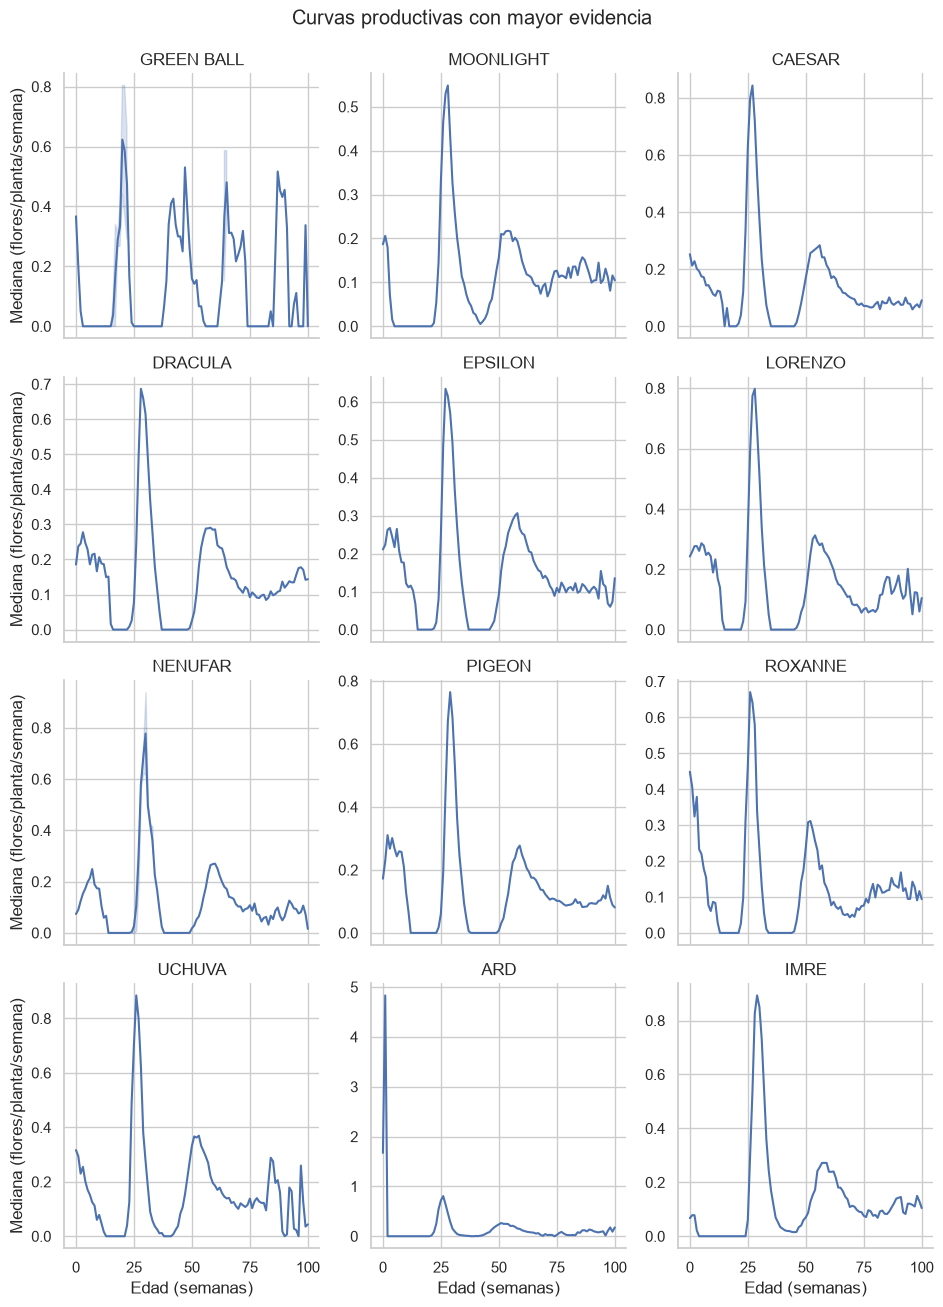

In [45]:
top_variedades = (validas.groupby("k_variedad").agg(camas=("k_cama_piloto","nunique"),observaciones=("fila_excel","size"))
                  .query("camas >= 3").sort_values(["camas","observaciones"],ascending=False).head(12).index)
plot = curva_variedad[curva_variedad.k_variedad.isin(top_variedades) & curva_variedad.edad_semana.between(0,100)]
g = sns.FacetGrid(plot, col="k_variedad", col_wrap=3, height=3.2, sharey=False)
g.map_dataframe(sns.lineplot, x="edad_semana", y="mediana_flores_planta")
g.set_axis_labels("Edad (semanas)", "Mediana (flores/planta/semana)")
g.set_titles("{col_name}")
g.fig.suptitle("Curvas productivas con mayor evidencia", y=1.02)
plt.show()

### 8. Variabilidad entre camas y estabilidad anual

Se comparan medianas por año. Cambios entre años pueden reflejar manejo, mezcla de camas, actualización del archivo o condiciones productivas; no se interpretan automáticamente como mejora o deterioro.

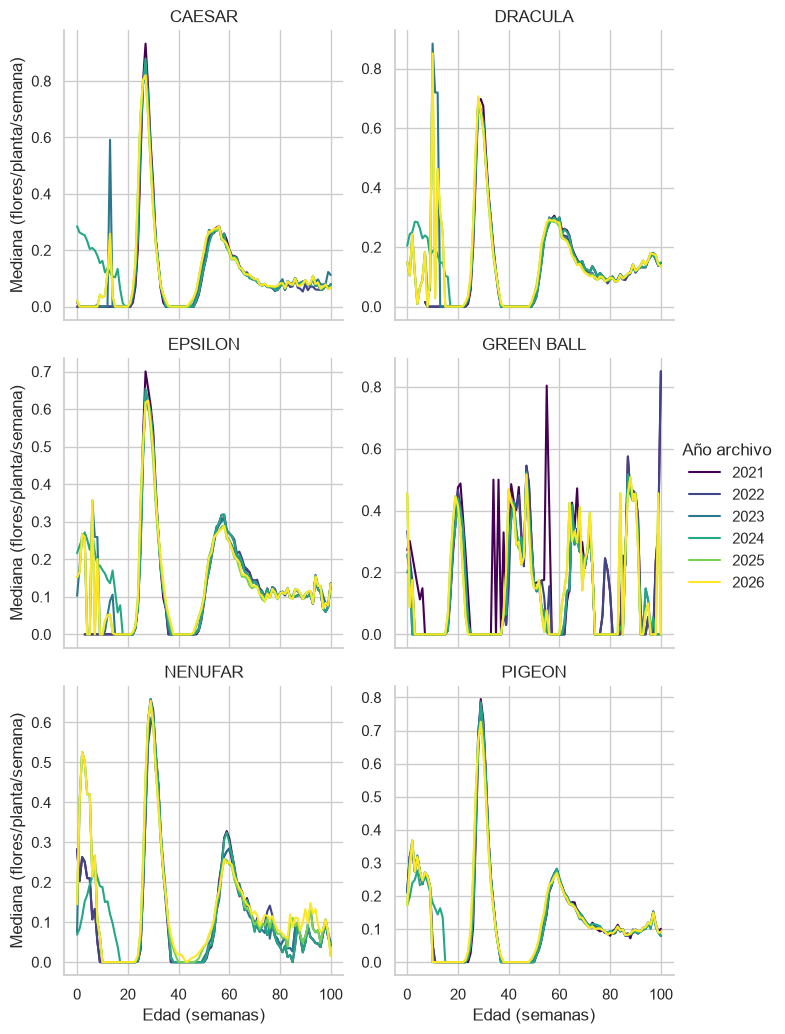

In [46]:
curva_anual = (validas[validas.k_variedad.isin(top_variedades[:6]) & validas.edad_semanas.between(0,100)]
               .groupby(["k_variedad","anio_archivo","edad_semana"],as_index=False)
               .agg(mediana_flores_planta=("flores_planta_semana","median"),observaciones=("fila_excel","size")))
g=sns.FacetGrid(curva_anual,col="k_variedad",col_wrap=2,height=3.5,sharey=False)
g.map_dataframe(sns.lineplot,x="edad_semana",y="mediana_flores_planta",hue="anio_archivo",palette="viridis")
g.add_legend(title="Año archivo")
g.set_axis_labels("Edad (semanas)","Mediana (flores/planta/semana)")
g.set_titles("{col_name}")
plt.show()

### 9. Cobertura de la curva

El mapa muestra cuántas observaciones existen por variedad y edad. Una celda clara o ausente significa evidencia insuficiente, no producción igual a cero.

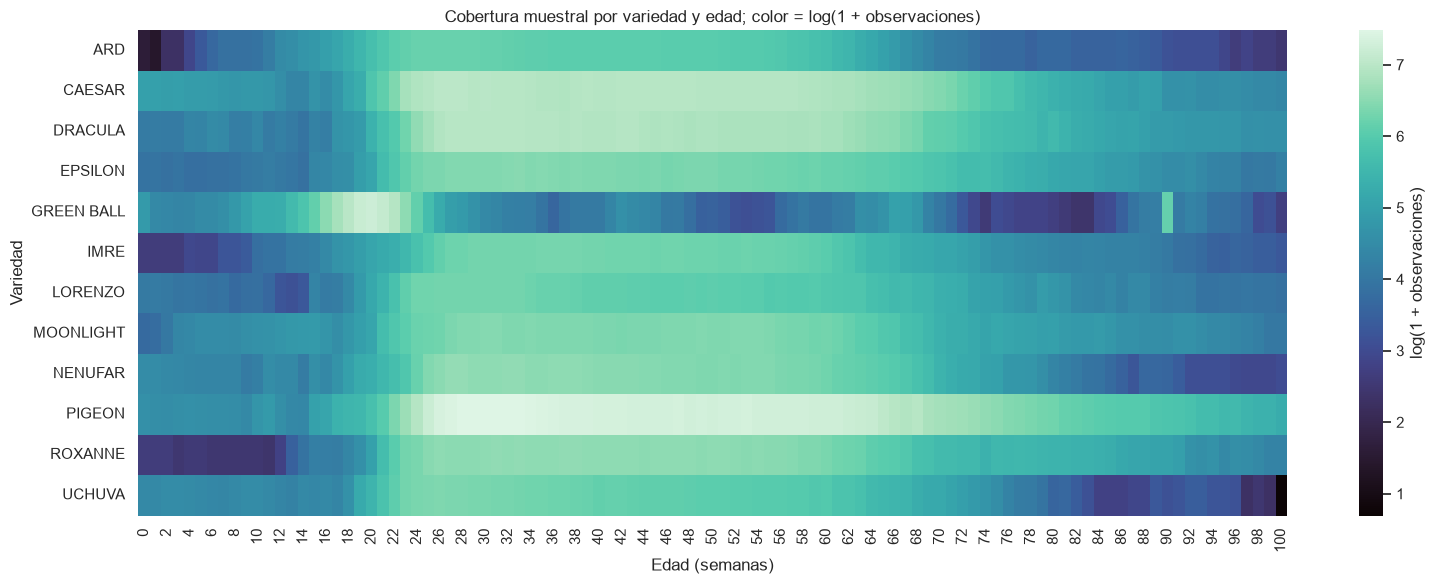

In [47]:
cobertura = (validas[validas.k_variedad.isin(top_variedades) & validas.edad_semana.between(0,100)]
             .groupby(["k_variedad","edad_semana"]).size().unstack(fill_value=0))
plt.figure(figsize=(16,6))
sns.heatmap(np.log1p(cobertura),cmap="mako",cbar_kws={"label":"log(1 + observaciones)"})
plt.xlabel("Edad (semanas)"); plt.ylabel("Variedad")
plt.title("Cobertura muestral por variedad y edad; color = log(1 + observaciones)")
plt.tight_layout(); plt.show()

## 10. Construcción del estimado teórico a cinco semanas

La réplica usa una regla explícita y auditable:

1. Para cada semana de emisión se selecciona un único archivo semanal de Siembras (la versión `actualizado` prevalece si existe otra versión de la misma semana).
2. Cada siembra se relaciona con una curva por variedad normalizada.
3. La edad objetivo es la edad reportada en ese archivo semanal más el horizonte `+1…+5`.
4. Se usa la mediana histórica disponible hasta el año de emisión; no se usan archivos futuros.
5. `tallos_estimados_curva = plantas × flores/planta/semana`.

Si falta variedad, edad, plantas o curva, no se inventa un valor. La cobertura se reporta separadamente.

In [48]:
def semana_siguiente(anio, semana, desplazamiento):
    fecha = pd.Timestamp.fromisocalendar(int(anio), int(semana), 1) + pd.Timedelta(weeks=int(desplazamiento))
    iso = fecha.isocalendar()
    return int(iso.year), int(iso.week), fecha

inventario_siembras = pd.read_csv(DATOS / "Plano de Siembras" / "datos preprocesados" / "auditoria" / "inventario_bases_semanales.csv")
inventario_siembras = inventario_siembras[~inventario_siembras.estado.astype(str).str.startswith("error")].copy()
inventario_siembras["preferencia"] = inventario_siembras.salida.astype(str).str.contains("actualizado",case=False).astype(int)
canonicas = (inventario_siembras.sort_values(["anio","semana","preferencia","salida"])
             .drop_duplicates(["anio","semana"],keep="last"))

# La validación comienza en 2024, cuando la cobertura semanal del estimado histórico es más regular.
canonicas = canonicas.query("anio >= 2024").copy()
curvas_hist = validas[["anio_archivo","k_variedad","edad_semana","flores_planta_semana","k_cama_piloto"]].copy()

pronosticos=[]; cobertura_pronostico=[]
for _, foto in canonicas.iterrows():
    s = pd.read_csv(foto.salida, low_memory=False)
    s.columns = [nombre_columna(c) for c in s.columns]
    if not {"variedad","plantas","edad"}.issubset(s.columns):
        cobertura_pronostico.append({"anio_emision":foto.anio,"semana_emision":foto.semana,"estado":"columnas_faltantes","filas":len(s)})
        continue
    s["k_variedad"] = s.variedad.map(texto_normalizado)
    s["plantas"] = pd.to_numeric(s.plantas,errors="coerce")
    s["edad_base"] = pd.to_numeric(s.edad,errors="coerce")
    s = s[(s.plantas>0) & s.edad_base.notna() & s.k_variedad.ne("")].copy()
    hist = curvas_hist[curvas_hist.anio_archivo <= int(foto.anio)]
    perfil = (hist.groupby(["k_variedad","edad_semana"],as_index=False)
              .agg(flores_planta_semana=("flores_planta_semana","median"),
                   observaciones_curva=("flores_planta_semana","size"),camas_curva=("k_cama_piloto","nunique")))
    for h in range(1,6):
        q=s.copy(); q["horizonte"]=h; q["edad_objetivo"]=(q.edad_base+h).round().astype("Int64")
        q=q.merge(perfil,left_on=["k_variedad","edad_objetivo"],right_on=["k_variedad","edad_semana"],how="left")
        q["tallos_estimados_curva"]=q.plantas*q.flores_planta_semana
        ao,so,lunes=semana_siguiente(foto.anio,foto.semana,h)
        q["anio_emision"]=int(foto.anio); q["semana_emision"]=int(foto.semana)
        q["anio"]=ao; q["semana"]=so; q["lunes"]=lunes
        q["archivo_siembra"]=foto.salida
        pronosticos.append(q)
        cobertura_pronostico.append({"anio_emision":foto.anio,"semana_emision":foto.semana,"horizonte":h,
            "filas_siembra_validas":len(q),"filas_con_curva":q.flores_planta_semana.notna().sum(),
            "plantas_totales":q.plantas.sum(),"plantas_con_curva":q.loc[q.flores_planta_semana.notna(),"plantas"].sum()})

pronosticos = pd.concat(pronosticos,ignore_index=True) if pronosticos else pd.DataFrame()
cobertura_pronostico = pd.DataFrame(cobertura_pronostico)
cobertura_pronostico["cobertura_plantas_pct"] = 100*cobertura_pronostico.plantas_con_curva/cobertura_pronostico.plantas_totales.replace(0,np.nan)
cobertura_pronostico.to_csv(AUDITORIA / "cobertura_estimacion_curvas.csv",index=False,encoding="utf-8-sig")
display(cobertura_pronostico.groupby("horizonte").agg(semanas=("semana_emision","size"),cobertura_plantas_pct=("cobertura_plantas_pct","median")))

,semanas,cobertura_plantas_pct
horizonte,,
1,137,97.38
2,137,97.33
3,137,97.35
4,137,97.37
5,137,97.40


## 10. Comparación con producción real y estimado histórico

La comparación se hace por variedad normalizada, año, semana y horizonte. Se reportan tallos, MAE, RMSE, sesgo y WAPE. El WAPE usa `Σ|error| / Σ|real|`; el sesgo conserva la dirección. La cobertura de la unión debe leerse antes que la métrica.

,metodo,pares,tallos_reales,MAE_tallos,RMSE_tallos,sesgo_tallos,WAPE_pct,horizonte
0,curva,17028,"160,095,616.00","2,954.93","5,597.91","1,054.43",31.43,1
1,ingeniero,14132,"146,761,914.00","2,394.85","4,269.80",-603.02,23.06,1
2,curva,16872,"158,802,962.00","2,882.63","5,462.20",922.77,30.63,2
3,ingeniero,13979,"145,248,752.00","2,519.00","4,464.60",-624.15,24.24,2
4,curva,16730,"157,550,828.00","2,814.22","5,327.33",797.21,29.88,3
5,ingeniero,13835,"144,328,049.00","2,557.84","4,532.64",-657.37,24.52,3
6,curva,16572,"156,306,043.00","2,757.46","5,206.80",690.91,29.24,4
7,ingeniero,13652,"142,291,618.00","2,632.48","4,695.92",-640.27,25.26,4
8,curva,16410,"155,123,998.00","2,714.57","5,125.46",608.03,28.72,5
9,ingeniero,6411,"67,269,124.00","2,735.93","4,895.78",-283.78,26.07,5



**Lectura de resultados.** La réplica pudo compararse con producción real en 83,612 pares variedad-semana.
El estimado histórico del ingeniero estuvo disponible para 62,009 de esos pares. El desfase modal entre etiquetas
es +1: el Excel cuenta la propia semana de emisión como horizonte 1, mientras esta réplica llama +1 a la
semana siguiente. Por eso la comparación se alinea por semana objetivo y no por el número escrito en `horizonte`.



### Conclusiones analíticas de esta ejecución

- **Unión interna:** 83.45% de las observaciones se relaciona sin ambigüedad; 15.13% queda excluido de cualquier enriquecimiento que necesite una cama única.
- **Cobertura para estimar:** la mediana de plantas con curva es 97.37%. Cobertura alta no equivale a exactitud alta.
- **Réplica:** su WAPE pasa de 31.43% en +1 a 28.72% en +5 y presenta sesgo positivo: tiende a sobreestimar.
- **Ingeniero:** en los pares disponibles obtiene WAPE de 23.06% en +1 y 26.07% en +5, con sesgo negativo: tiende a subestimar.
- **Interpretación:** la regla pura `plantas × curva mediana` todavía no reproduce los ajustes del ingeniero. La diferencia probablemente contiene factores de aprovechamiento, estado real de la cama, rezagos de edad, pérdidas o ajustes comerciales que no están formalizados.
- **Cautela:** que el WAPE de la réplica disminuya con el horizonte no demuestra que pronostique mejor a largo plazo; cambia la composición de pares comparables. La siguiente evaluación debe usar una cohorte fija de emisiones y variedades presentes en los cinco horizontes.


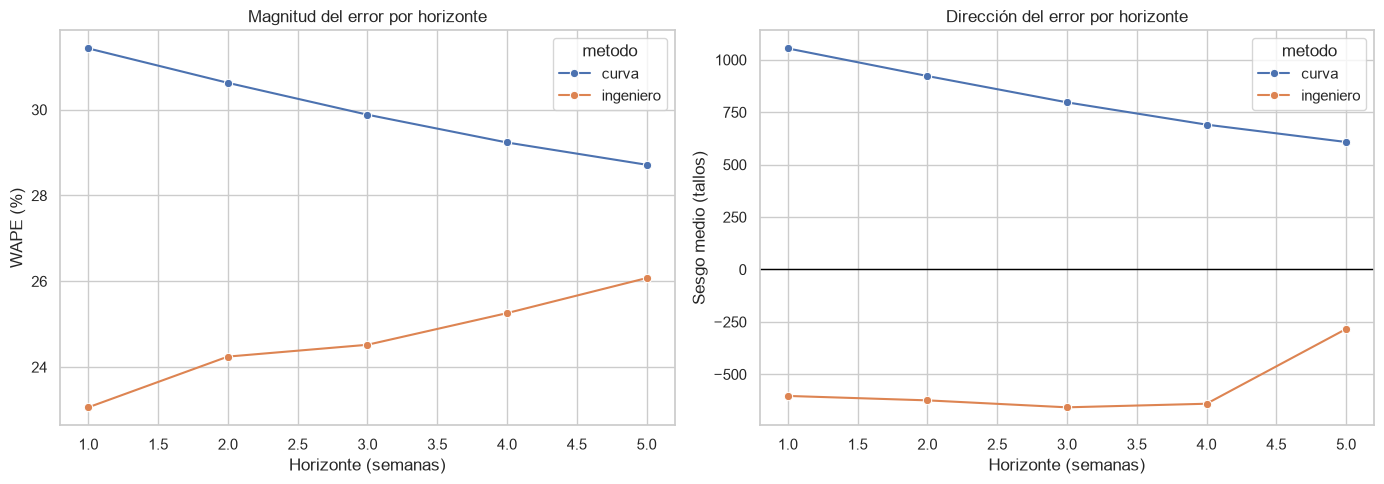

In [49]:
pred = (pronosticos.dropna(subset=["tallos_estimados_curva"]).groupby(
    ["anio_emision","semana_emision","anio","semana","horizonte","k_variedad"],as_index=False)
    .tallos_estimados_curva.sum())

real = pd.read_csv(DATOS / "Producción real" / "datos preprocesados" / "produccion_semanal_gaitana.csv",low_memory=False)
real["k_variedad"] = real.variedad.map(texto_normalizado)
real_v = real.groupby(["anio","semana","k_variedad"],as_index=False).tallos_reales.sum()

# Reconstrucción autocontenida del estimado histórico ya despivotado por el notebook 01.
patron_est = (DATOS / "Estimados semanales" / "datos preprocesados" / "por año" / "*" / "*.csv").as_posix()
con.execute(f"CREATE OR REPLACE VIEW estimados_raw AS SELECT * FROM read_csv_auto('{patron_est}',union_by_name=true,ignore_errors=true)")
est_hist = con.execute("""
SELECT archivo_origen, TRY_CAST(anio_carpeta AS INTEGER) anio_emision,
       TRY_CAST(semana_inicio_archivo AS INTEGER) semana_emision,
       TRY_CAST(anio_objetivo AS INTEGER) anio, TRY_CAST(semana_objetivo AS INTEGER) semana,
       TRY_CAST(horizonte AS INTEGER) horizonte_ingeniero, TRIM(CAST(variedad AS VARCHAR)) variedad,
       SUM(TRY_CAST(tallos AS DOUBLE)) tallos_estimados_ingeniero
FROM estimados_raw WHERE UPPER(TRIM(finca))='GAITANA' AND LOWER(TRIM(tipo))='estimado'
AND TRY_CAST(horizonte AS INTEGER) BETWEEN 1 AND 16
GROUP BY 1,2,3,4,5,6,7
""").df()
est_hist["k_variedad"] = est_hist.variedad.map(texto_normalizado)
est_hist["preferencia_version"] = est_hist.archivo_origen.str.contains("AJUST|CORRE|ACTUAL",case=False,regex=True).astype(int)
est_hist = (est_hist.sort_values(["preferencia_version","archivo_origen"])
            .drop_duplicates(["anio_emision","semana_emision","anio","semana","k_variedad"],keep="last"))

comparacion = pred.merge(real_v,on=["anio","semana","k_variedad"],how="inner")
comparacion = comparacion.merge(est_hist,on=["anio_emision","semana_emision","anio","semana","k_variedad"],how="left")
comparacion["desfase_horizonte"] = comparacion.horizonte_ingeniero - comparacion.horizonte
for metodo,col in {"curva":"tallos_estimados_curva","ingeniero":"tallos_estimados_ingeniero"}.items():
    comparacion[f"error_{metodo}"]=comparacion[col]-comparacion.tallos_reales
    comparacion[f"error_abs_{metodo}"]=comparacion[f"error_{metodo}"].abs()
    comparacion[f"error_sq_{metodo}"]=comparacion[f"error_{metodo}"]**2

def metricas(grupo):
    filas=[]
    for metodo in ["curva","ingeniero"]:
        x=grupo.dropna(subset=[f"error_{metodo}"])
        filas.append({"metodo":metodo,"pares":len(x),"tallos_reales":x.tallos_reales.sum(),
            "MAE_tallos":x[f"error_abs_{metodo}"].mean(),"RMSE_tallos":np.sqrt(x[f"error_sq_{metodo}"].mean()),
            "sesgo_tallos":x[f"error_{metodo}"].mean(),
            "WAPE_pct":100*x[f"error_abs_{metodo}"].sum()/x.tallos_reales.abs().sum() if x.tallos_reales.abs().sum() else np.nan})
    return pd.DataFrame(filas)

metricas_h = pd.concat([metricas(g).assign(horizonte=h) for h,g in comparacion.groupby("horizonte")],ignore_index=True)
comparacion.to_csv(CONSOLIDADAS / "comparacion_curvas_ingeniero_real_variedad.csv",index=False,encoding="utf-8-sig")
metricas_h.to_csv(CONSOLIDADAS / "metricas_estimacion_por_horizonte.csv",index=False,encoding="utf-8-sig")
display(metricas_h)

pares_ing = int(comparacion.tallos_estimados_ingeniero.notna().sum())
desfase = comparacion.loc[comparacion.tallos_estimados_ingeniero.notna(),"desfase_horizonte"].mode()
texto_desfase = "sin pares" if desfase.empty else f"{desfase.iloc[0]:+.0f}"
display(Markdown(f"""
**Lectura de resultados.** La réplica pudo compararse con producción real en {len(comparacion):,} pares variedad-semana.
El estimado histórico del ingeniero estuvo disponible para {pares_ing:,} de esos pares. El desfase modal entre etiquetas
es {texto_desfase}: el Excel cuenta la propia semana de emisión como horizonte 1, mientras esta réplica llama +1 a la
semana siguiente. Por eso la comparación se alinea por semana objetivo y no por el número escrito en `horizonte`.
"""))

confirmado_pct = 100*resumen_match.loc[resumen_match.estado_match.str.startswith("match"),"observaciones"].sum()/resumen_match.observaciones.sum()
ambiguo_pct = 100*resumen_match.loc[resumen_match.estado_match.eq("ambiguo"),"observaciones"].sum()/resumen_match.observaciones.sum()
cobertura_mediana = cobertura_pronostico.groupby("horizonte").cobertura_plantas_pct.median().mean()
w_curva = metricas_h.query("metodo == 'curva'").set_index("horizonte").WAPE_pct
w_ing = metricas_h.query("metodo == 'ingeniero'").set_index("horizonte").WAPE_pct
display(Markdown(f"""
### Conclusiones analíticas de esta ejecución

- **Unión interna:** {confirmado_pct:.2f}% de las observaciones se relaciona sin ambigüedad; {ambiguo_pct:.2f}% queda excluido de cualquier enriquecimiento que necesite una cama única.
- **Cobertura para estimar:** la mediana de plantas con curva es {cobertura_mediana:.2f}%. Cobertura alta no equivale a exactitud alta.
- **Réplica:** su WAPE pasa de {w_curva.loc[1]:.2f}% en +1 a {w_curva.loc[5]:.2f}% en +5 y presenta sesgo positivo: tiende a sobreestimar.
- **Ingeniero:** en los pares disponibles obtiene WAPE de {w_ing.loc[1]:.2f}% en +1 y {w_ing.loc[5]:.2f}% en +5, con sesgo negativo: tiende a subestimar.
- **Interpretación:** la regla pura `plantas × curva mediana` todavía no reproduce los ajustes del ingeniero. La diferencia probablemente contiene factores de aprovechamiento, estado real de la cama, rezagos de edad, pérdidas o ajustes comerciales que no están formalizados.
- **Cautela:** que el WAPE de la réplica disminuya con el horizonte no demuestra que pronostique mejor a largo plazo; cambia la composición de pares comparables. La siguiente evaluación debe usar una cohorte fija de emisiones y variedades presentes en los cinco horizontes.
"""))

fig,axes=plt.subplots(1,2,figsize=(14,5))
sns.lineplot(data=metricas_h,x="horizonte",y="WAPE_pct",hue="metodo",marker="o",ax=axes[0])
axes[0].set(xlabel="Horizonte (semanas)",ylabel="WAPE (%)",title="Magnitud del error por horizonte")
sns.lineplot(data=metricas_h,x="horizonte",y="sesgo_tallos",hue="metodo",marker="o",ax=axes[1])
axes[1].axhline(0,color="black",linewidth=1)
axes[1].set(xlabel="Horizonte (semanas)",ylabel="Sesgo medio (tallos)",title="Dirección del error por horizonte")
plt.tight_layout(); plt.show()

## 11. Limitaciones y preguntas que deben validarse con el ingeniero

- `Flor/Planta` se interpreta como flores por planta por semana porque coincide con la tabla dinámica de productividad; debe confirmarse formalmente.
- `Edad` se usa tal como aparece en los libros y se interpreta en semanas.
- `Índice Prod`, `Inicio Prod.`, densidad, aprovechamiento y conversiones a tallos/m²/año no entran en el estimado hasta conocer su definición exacta.
- El match `Cama Piloto ↔ Referencia` solo valida la trazabilidad interna. Para aplicar una curva a todas las siembras se usa variedad; no se asigna una cama piloto específica a una cama comercial.
- Una ausencia de curva genera `sin estimación`, no cero.
- Los resultados por variedad solo incluyen nombres que coinciden tras normalización; las homologaciones semánticas pendientes deben aprobarse.
- Los Excel anuales parecen contener historia acumulada. La evaluación limita la curva a archivos con año menor o igual a la emisión, pero hace falta confirmar la fecha exacta de actualización de cada libro para eliminar completamente cualquier fuga temporal.

In [50]:
resumen_final = pd.DataFrame({
    "artefacto": ["inventario_libros.csv","resumen_calidad_match.csv","calidad_magnitudes.csv",
                  "curvas_por_variedad_edad.csv","cobertura_estimacion_curvas.csv",
                  "comparacion_curvas_ingeniero_real_variedad.csv","metricas_estimacion_por_horizonte.csv"],
    "carpeta": ["auditoria","auditoria","auditoria","bases consolidadas","auditoria","bases consolidadas","bases consolidadas"],
    "unidad_principal": ["archivo","observaciones y porcentaje","observaciones","flores/planta/semana",
                         "plantas y porcentaje","tallos","tallos y porcentaje"]})
display(resumen_final)
print("Proceso terminado. Revise primero las auditorías de cobertura antes de interpretar el WAPE.")

,artefacto,carpeta,unidad_principal
0,inventario_libros.csv,auditoria,archivo
1,resumen_calidad_match.csv,auditoria,observaciones y porcentaje
2,calidad_magnitudes.csv,auditoria,observaciones
3,curvas_por_variedad_edad.csv,bases consolidadas,flores/planta/semana
4,cobertura_estimacion_curvas.csv,auditoria,plantas y porcentaje
5,comparacion_curvas_ingeniero_real_variedad.csv,bases consolidadas,tallos
6,metricas_estimacion_por_horizonte.csv,bases consolidadas,tallos y porcentaje


Proceso terminado. Revise primero las auditorías de cobertura antes de interpretar el WAPE.


# PARTE V — INTEGRACIÓN ENTRE FUENTES

## 17. Qué significa cada cruce

| Cruce | Llave | Qué responde | Qué no demuestra |
|---|---|---|---|
| Producción–siembras (catálogo) | producto-color-variedad | si los nombres existen en ambas fuentes | que la siembra produjo esos tallos |
| Plan de Siembras–Curvas | variedad + edad | producción teórica = plantas × flores/planta | el ajuste basado en experiencia del ingeniero |
| Producción–clima | año-semana | asociación temporal | causalidad climática |
| Producción–estimado | semana objetivo + producto-color(-variedad) | error del benchmark | calidad de un modelo futuro |

Separar estos niveles evita interpretar una coincidencia de nombres como una relación agronómica.

## 18. Homologación de producto, color y variedad

In [51]:
def cobertura_catalogo(claves):
    catalogo = siembras[claves].drop_duplicates()
    base = produccion.groupby(claves,as_index=False).tallos_reales.sum()
    cruce = base.merge(catalogo,on=claves,how="left",indicator=True)
    return {
        "nivel":" + ".join(c.replace("k_","") for c in claves),
        "combinaciones_prod":len(base),
        "combinaciones_con_match_pct":100*(cruce._merge=="both").mean(),
        "tallos_con_match_pct":100*cruce.loc[cruce._merge=="both","tallos_reales"].sum()/cruce.tallos_reales.sum(),
    }

coberturas = pd.DataFrame([
    cobertura_catalogo(["k_producto"]),
    cobertura_catalogo(["k_producto","k_color"]),
    cobertura_catalogo(["k_producto","k_color","k_variedad"]),
])
display(coberturas)

,nivel,combinaciones_prod,combinaciones_con_match_pct,tallos_con_match_pct
0,producto,20,100.00,100.00
1,producto + color,116,100.00,100.00
2,producto + color + variedad,658,98.48,99.72


### 18.1 Combinaciones productivas sin correspondencia en siembras

In [52]:
claves_pcv=["k_producto","k_color","k_variedad"]
volumen_pcv=produccion.groupby(claves_pcv,as_index=False).tallos_reales.sum()
catalogo_s=siembras[claves_pcv].drop_duplicates()
sin_match=(volumen_pcv.merge(catalogo_s,on=claves_pcv,how="left",indicator=True)
           .query("_merge=='left_only'").drop(columns="_merge")
           .sort_values("tallos_reales",ascending=False))
display(sin_match.head(30))
print("Estas filas deben alimentar un catálogo de homologación, no una corrección manual silenciosa.")

,k_producto,k_color,k_variedad,tallos_reales
413,MINICARNATION,GOLD,PINATA SUNDROPS,"778,851.00"
511,MINICARNATION,RED,PINATA MILANI,"29,459.00"
449,MINICARNATION,LAVENDER,PINATA LILAC,"18,338.00"
412,MINICARNATION,GOLD,PINATA GOLD,"17,144.00"
83,CARNATION,BICOLOR PINK,YUKARI CHERRY,"2,376.00"
398,MINICARNATION,BICOLOR YELLOW,LUMINA,"1,606.00"
392,MINICARNATION,BICOLOR RED,PINATA BICOLOR RED,"1,232.00"
450,MINICARNATION,LAVENDER,PINATA NEON PINK,"1,048.00"
512,MINICARNATION,RED,PINATA RED,604.00
268,CARNATION,RED,ALHAMDRA,3.00


Estas filas deben alimentar un catálogo de homologación, no una corrección manual silenciosa.


## 19. Cómo se construye el estimado teórico

Esta es la conexión central del proyecto. No parte de una fecha futura escrita en el plan, sino del estado vigente de cada cama.

In [53]:
metodologia_estimado = pd.DataFrame([
    ["1. Plan vigente", "plantas, variedad y edad de cada cama", "plantas"],
    ["2. Curva de producción", "flores esperadas por planta para cada edad", "flores/planta"],
    ["3. Estimado teórico", "plantas × flores/planta", "flores (tallos)"],
    ["4. Ajuste del ingeniero", "corrección basada en experiencia e información operativa", "flores (tallos)"],
    ["5. Evaluación", "comparación de ambos estimados contra producción real", "WAPE, sesgo y error"],
], columns=["paso", "informacion_o_calculo", "unidad"])
display(metodologia_estimado)

,paso,informacion_o_calculo,unidad
0,1. Plan vigente,"plantas, variedad y edad de cada cama",plantas
1,2. Curva de producción,flores esperadas por planta para cada edad,flores/planta
2,3. Estimado teórico,plantas × flores/planta,flores (tallos)
3,4. Ajuste del ingeniero,corrección basada en experiencia e información...,flores (tallos)
4,5. Evaluación,comparación de ambos estimados contra producci...,"WAPE, sesgo y error"


La unidad queda explícita: **plantas × flores/planta = flores**, que operativamente se comparan con tallos producidos. La edad determina qué punto de la curva corresponde a cada cama. El resultado anterior al ajuste humano es el estimado teórico; por eso debe evaluarse por separado del estimado entregado por el ingeniero.

## 20. Decisión metodológica: qué fecha no se usa

In [54]:
decision_fechas = pd.DataFrame([
    ["fecha/semana del archivo", "Sí", "identifica qué versión semanal del plan estaba disponible"],
    ["fecha de siembra y edad", "Sí", "permiten ubicar la cama en su curva de producción"],
    ["FECHA PRODUCCION del plan", "No", "no forma parte del cálculo operativo validado por el equipo"],
], columns=["campo", "se_usa", "razon"])
display(decision_fechas)

,campo,se_usa,razon
0,fecha/semana del archivo,Sí,identifica qué versión semanal del plan estaba...
1,fecha de siembra y edad,Sí,permiten ubicar la cama en su curva de producción
2,FECHA PRODUCCION del plan,No,no forma parte del cálculo operativo validado ...


Se elimina el anterior ‘ciclo observable’ y la correlación agregada entre siembra y producción futura. Ninguna de las dos medidas representa el procedimiento que usa el ingeniero y podían sugerir una relación temporal falsa. La comparación válida se hace por **semana objetivo** entre: (1) producción teórica del plan más las curvas, (2) estimado ajustado del ingeniero y (3) producción real.

## 21. Cruce clima–producción

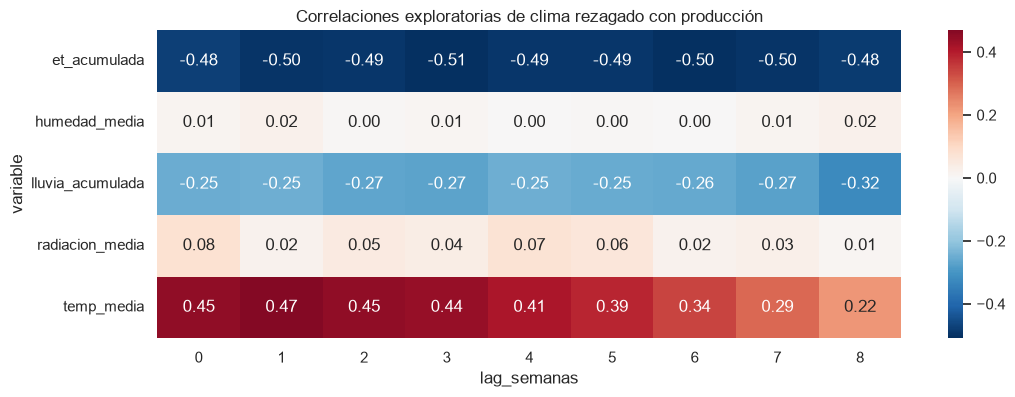

In [55]:
prod_total=produccion.groupby(["anio","semana"],as_index=False).tallos_reales.sum()
clima_prod=clima.merge(prod_total,on=["anio","semana"],how="inner").sort_values("lunes")
variables_clima=["temp_media","humedad_media","lluvia_acumulada","radiacion_media","et_acumulada"]
filas_corr=[]
for variable in variables_clima:
    for lag in range(0,9):
        filas_corr.append([variable,lag,clima_prod[variable].shift(lag).corr(clima_prod.tallos_reales)])
corr_lag=pd.DataFrame(filas_corr,columns=["variable","lag_semanas","correlacion"])
matriz_corr=corr_lag.pivot(index="variable",columns="lag_semanas",values="correlacion")
plt.figure(figsize=(12,4))
sns.heatmap(matriz_corr,annot=True,fmt=".2f",cmap="RdBu_r",center=0)
plt.title("Correlaciones exploratorias de clima rezagado con producción")
plt.show()

# PARTE VI — COMPARACIÓN: ESTIMADO TEÓRICO, AJUSTE DEL INGENIERO Y PRODUCCIÓN REAL

## 22. Metodología de evaluación

- Se compara cada `ESTIMADO` con tallos reales de la misma semana objetivo.
- Se evalúa producto-color y producto-color-variedad por separado.
- Métricas: MAE, RMSE, sesgo, WMAPE, porcentaje dentro de ±8 % y porcentaje de subestimación.
- Los horizontes +1 a +5 son el análisis principal.
- **Horizonte +1 tiene una sección exclusiva**, por ser la decisión más próxima y accionable.
- No se usan MAPE simples cuando el real es cero o muy pequeño.

## 23. Construcción del benchmark

In [56]:
est_pc=(estimados[estimados.horizonte.between(1,16)].groupby(
    ["archivo_origen","anio_emision","anio","semana","horizonte","k_producto","k_color"],
    as_index=False,dropna=False).tallos_estimados.sum())
real_pc=produccion.groupby(["anio","semana","k_producto","k_color"],as_index=False).tallos_reales.sum()
evaluacion_pc=est_pc.merge(real_pc,on=["anio","semana","k_producto","k_color"],how="inner")

est_pcv=(estimados[estimados.horizonte.between(1,16)].groupby(
    ["archivo_origen","anio_emision","anio","semana","horizonte","k_producto","k_color","k_variedad"],
    as_index=False,dropna=False).tallos_estimados.sum())
real_pcv=produccion.groupby(["anio","semana","k_producto","k_color","k_variedad"],as_index=False).tallos_reales.sum()
evaluacion_pcv=est_pcv.merge(real_pcv,on=["anio","semana","k_producto","k_color","k_variedad"],how="inner")

for tabla in [evaluacion_pc,evaluacion_pcv]:
    tabla["error"]=tabla.tallos_estimados-tabla.tallos_reales
    tabla["error_abs"]=tabla.error.abs()
    tabla["error_sq"]=tabla.error.pow(2)
    tabla["real_abs"]=tabla.tallos_reales.abs()
    tabla["subestima"]=tabla.error<0
    tabla["error_pct"]=np.where(tabla.tallos_reales.abs()>0,100*tabla.error_abs/tabla.tallos_reales.abs(),np.nan)
    tabla["dentro_8"]=tabla.error_pct<=8
    tabla["direccion"]=np.select([tabla.error>0,tabla.error<0],["Sobreestima","Subestima"],default="Exacto")

cobertura_benchmark=pd.DataFrame([
    ["producto-color",len(evaluacion_pc),evaluacion_pc.anio_emision.min(),evaluacion_pc.anio_emision.max()],
    ["producto-color-variedad",len(evaluacion_pcv),evaluacion_pcv.anio_emision.min(),evaluacion_pcv.anio_emision.max()],
],columns=["nivel","pares_comparables","anio_min","anio_max"])
display(cobertura_benchmark)

,nivel,pares_comparables,anio_min,anio_max
0,producto-color,70898,2023,2026
1,producto-color-variedad,118951,2023,2026


## 24. Desempeño en los cinco horizontes

,anio_emision,horizonte,observaciones,tallos_reales,tallos_estimados,MAE,error_sq_media,sesgo,error_abs_total,real_abs_total,dentro_8_pct,subestima_pct,RMSE,WMAPE_pct
0,2024,1,2939,"55,385,075.00","51,424,283.19","3,729.93","39,757,803.14","-1,347.67","10,962,256.48","55,385,075.00",20.69,61.45,"6,305.38",19.79
1,2024,2,2940,"55,160,299.00","51,907,264.37","4,167.69","48,889,603.14","-1,106.47","12,253,007.14","55,160,299.00",18.71,59.32,"6,992.11",22.21
2,2024,3,2941,"54,972,972.00","52,349,925.23","4,304.26","51,464,583.32",-891.89,"12,658,822.70","54,972,972.00",18.06,56.61,"7,173.88",23.03
3,2024,4,2940,"55,033,240.00","52,904,878.40","4,456.75","54,764,856.80",-723.93,"13,102,850.54","55,033,240.00",17.18,55.58,"7,400.33",23.81
4,2024,5,2933,"55,061,371.00","53,406,854.42","4,491.07","55,079,688.32",-564.10,"13,172,320.27","55,061,371.00",16.71,54.45,"7,421.57",23.92
5,2025,1,3186,"55,344,547.00","51,560,865.00","3,100.41","26,687,393.97","-1,187.60","9,877,894.00","55,344,547.00",22.03,64.25,"5,165.98",17.85
6,2025,2,3186,"54,358,280.00","51,600,999.00","3,605.50","39,091,763.59",-865.44,"11,487,125.00","54,358,280.00",19.43,60.30,"6,252.34",21.13
7,2025,3,3183,"54,119,836.00","51,279,118.11","3,792.00","44,261,046.90",-892.47,"12,069,923.93","54,119,836.00",19.01,60.10,"6,652.90",22.30
8,2025,4,3184,"54,684,324.00","51,238,630.08","3,701.53","40,903,404.44","-1,082.19","11,785,687.13","54,684,324.00",19.97,60.68,"6,395.58",21.55
9,2025,5,3164,"54,372,661.00","51,176,439.09","3,882.61","47,327,449.67","-1,010.18","12,284,580.09","54,372,661.00",19.37,60.84,"6,879.49",22.59


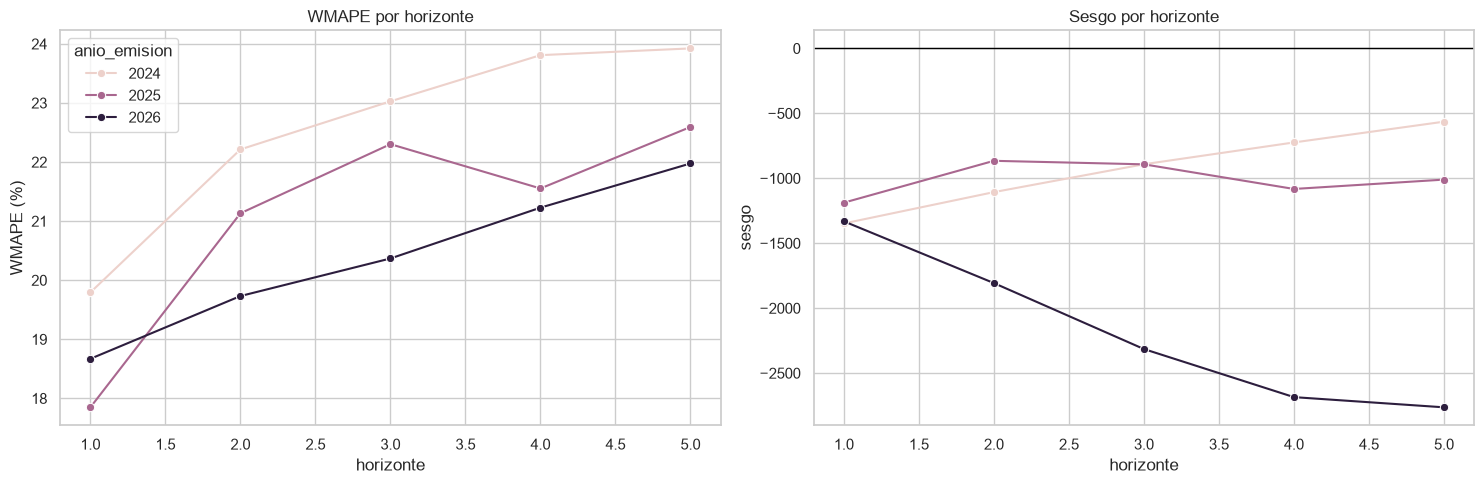

In [57]:
base_cinco=evaluacion_pc.query("1 <= horizonte <= 5 and anio_emision >= 2024").copy()
base_cinco["real_abs"]=base_cinco.tallos_reales.abs()
base_cinco["subestima"]=base_cinco.error<0
cinco=base_cinco.groupby(["anio_emision","horizonte"],as_index=False).agg(
    observaciones=("error","size"),tallos_reales=("tallos_reales","sum"),
    tallos_estimados=("tallos_estimados","sum"),MAE=("error_abs","mean"),
    error_sq_media=("error_sq","mean"),sesgo=("error","mean"),
    error_abs_total=("error_abs","sum"),real_abs_total=("real_abs","sum"),
    dentro_8_pct=("dentro_8",lambda s:100*s.mean()),
    subestima_pct=("subestima",lambda s:100*s.mean()))
cinco["RMSE"]=np.sqrt(cinco.error_sq_media)
cinco["WMAPE_pct"]=100*cinco.error_abs_total/cinco.real_abs_total.replace(0,np.nan)
display(cinco)

fig,axes=plt.subplots(1,2,figsize=(15,5))
sns.lineplot(data=cinco,x="horizonte",y="WMAPE_pct",hue="anio_emision",marker="o",ax=axes[0])
axes[0].set_title("WMAPE por horizonte"); axes[0].set_ylabel("WMAPE (%)")
sns.lineplot(data=cinco,x="horizonte",y="sesgo",hue="anio_emision",marker="o",ax=axes[1],legend=False)
axes[1].axhline(0,color="black",linewidth=1); axes[1].set_title("Sesgo por horizonte")
plt.tight_layout(); plt.show()

# 24. Análisis exclusivo: horizonte +1 (la siguiente semana) (COMPARACIONES CON EL INGENIERO)

Este bloque no mezcla la predicción inmediata con horizontes más lejanos.

,anio_emision,observaciones,tallos_reales,tallos_estimados,MAE,error_sq_media,sesgo,error_abs_total,real_abs_total,dentro_8_pct,subestima_pct,RMSE,WMAPE_pct
0,2024,2939,"55,385,075.00","51,424,283.19","3,729.93","39,757,803.14","-1,347.67","10,962,256.48","55,385,075.00",20.69,61.45,"6,305.38",19.79
1,2025,3186,"55,344,547.00","51,560,865.00","3,100.41","26,687,393.97","-1,187.60","9,877,894.00","55,344,547.00",22.03,64.25,"5,165.98",17.85
2,2026,2264,"42,486,719.00","39,472,240.00","3,503.57","37,312,926.01","-1,331.48","7,932,085.00","42,486,719.00",23.81,62.94,"6,108.43",18.67


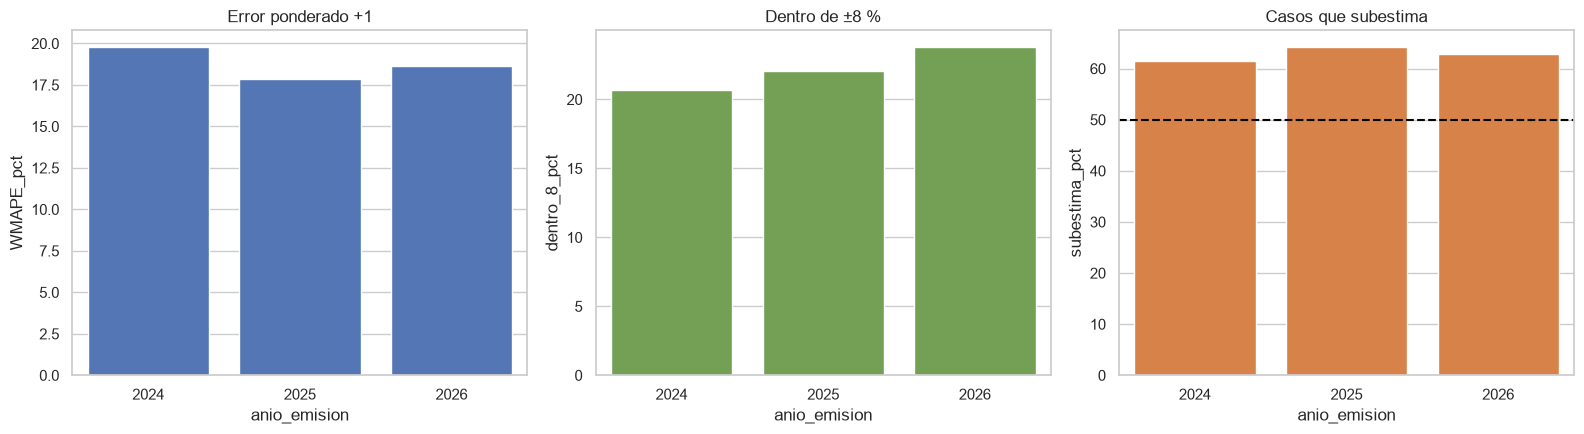

In [58]:
h1_pc=evaluacion_pc.query("horizonte==1 and anio_emision>=2024").copy()
h1_pcv=evaluacion_pcv.query("horizonte==1 and anio_emision>=2024").copy()
metricas_h1=h1_pc.groupby("anio_emision",as_index=False).agg(
    observaciones=("error","size"),tallos_reales=("tallos_reales","sum"),
    tallos_estimados=("tallos_estimados","sum"),MAE=("error_abs","mean"),
    error_sq_media=("error_sq","mean"),sesgo=("error","mean"),
    error_abs_total=("error_abs","sum"),real_abs_total=("real_abs","sum"),
    dentro_8_pct=("dentro_8",lambda s:100*s.mean()),subestima_pct=("subestima",lambda s:100*s.mean()))
metricas_h1["RMSE"]=np.sqrt(metricas_h1.error_sq_media)
metricas_h1["WMAPE_pct"]=100*metricas_h1.error_abs_total/metricas_h1.real_abs_total.replace(0,np.nan)
display(metricas_h1)

fig,axes=plt.subplots(1,3,figsize=(16,4.5))
sns.barplot(data=metricas_h1,x="anio_emision",y="WMAPE_pct",color="#4472C4",ax=axes[0])
axes[0].set_title("Error ponderado +1")
sns.barplot(data=metricas_h1,x="anio_emision",y="dentro_8_pct",color="#70AD47",ax=axes[1])
axes[1].set_title("Dentro de ±8 %")
sns.barplot(data=metricas_h1,x="anio_emision",y="subestima_pct",color="#ED7D31",ax=axes[2])
axes[2].axhline(50,color="black",linestyle="--"); axes[2].set_title("Casos que subestima")
plt.tight_layout(); plt.show()

### 24.1 ¿En qué producto-color pesa más el error +1?

,k_producto,k_color,observaciones,real,estimado,error_abs,sesgo,WMAPE_pct,sesgo_pct
41,MINICARNATION,LIGHT PINK,128,"11,387,058.00","10,961,598.00","1,584,784.00","-425,460.00",13.92,-3.74
42,MINICARNATION,ORANGE,128,"8,666,237.00","7,646,259.00","1,559,770.00","-1,019,978.00",18.00,-11.77
39,MINICARNATION,HOT PINK,128,"9,894,563.00","9,650,934.00","1,352,381.00","-243,629.00",13.67,-2.46
40,MINICARNATION,LAVENDER,128,"5,900,561.00","4,786,794.00","1,254,259.00","-1,113,767.00",21.26,-18.88
45,MINICARNATION,RED,128,"8,020,866.00","8,018,362.00","1,229,480.00","-2,504.00",15.33,-0.03
48,MINICARNATION,YELLOW,128,"7,428,690.00","7,002,516.00","1,180,072.00","-426,174.00",15.89,-5.74
47,MINICARNATION,WHITE,128,"8,713,689.00","8,122,722.00","1,151,659.00","-590,967.00",13.22,-6.78
49,RAFFINE,BICOLOR BURGUNDY,128,"3,036,967.00","2,897,481.00","811,588.00","-139,486.00",26.72,-4.59
53,RAFFINE,LIGHT PINK,128,"2,491,829.00","2,029,682.00","784,333.00","-462,147.00",31.48,-18.55
27,CARNATION,VINTAGE,128,"2,173,747.00","2,516,670.00","769,735.00","342,923.00",35.41,15.78


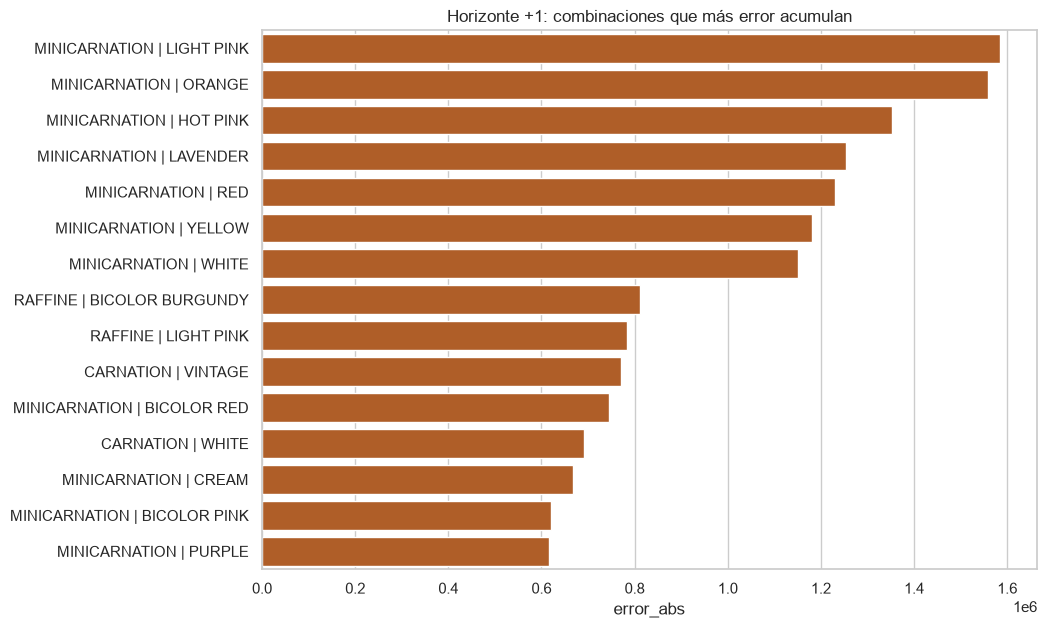

In [59]:
impacto_h1=h1_pc.groupby(["k_producto","k_color"],as_index=False).agg(
    observaciones=("error","size"),real=("tallos_reales","sum"),
    estimado=("tallos_estimados","sum"),error_abs=("error_abs","sum"),sesgo=("error","sum")
)
impacto_h1["WMAPE_pct"]=100*impacto_h1.error_abs/impacto_h1.real.abs().replace(0,np.nan)
impacto_h1["sesgo_pct"]=100*impacto_h1.sesgo/impacto_h1.real.abs().replace(0,np.nan)
impacto_h1=impacto_h1.sort_values("error_abs",ascending=False)
display(impacto_h1.head(25))

top=impacto_h1.head(15).copy()
plt.figure(figsize=(10,7))
sns.barplot(data=top,y=top.k_producto+" | "+top.k_color,x="error_abs",color="#C55A11")
plt.title("Horizonte +1: combinaciones que más error acumulan")
plt.ylabel(""); plt.show()

### 24.2 Sobreestimación y subestimación +1

,anio_emision,direccion,casos,porcentaje
0,2024,Sobreestima,1133,38.55
1,2024,Subestima,1806,61.45
2,2025,Exacto,7,0.22
3,2025,Sobreestima,1132,35.53
4,2025,Subestima,2047,64.25
5,2026,Exacto,19,0.84
6,2026,Sobreestima,820,36.22
7,2026,Subestima,1425,62.94


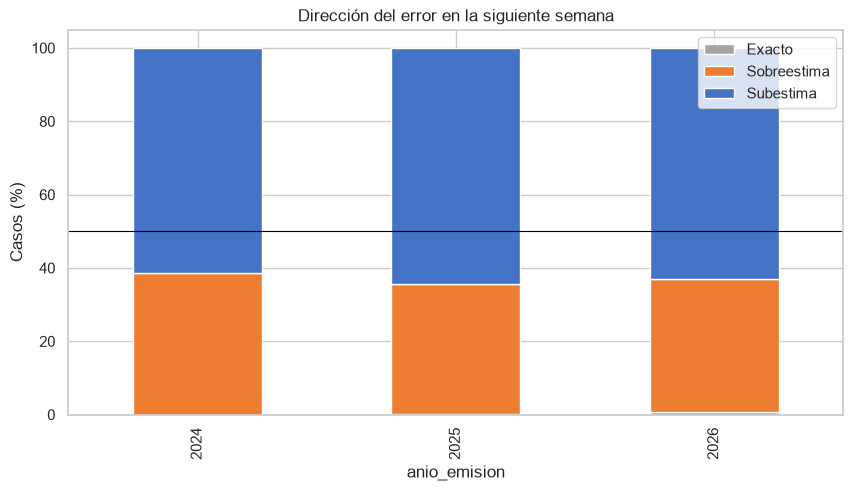

In [60]:
direccion=(h1_pc.groupby(["anio_emision","direccion"]).size().rename("casos").reset_index())
direccion["porcentaje"]=100*direccion.casos/direccion.groupby("anio_emision").casos.transform("sum")
display(direccion)
tabla_dir=direccion.pivot(index="anio_emision",columns="direccion",values="porcentaje").fillna(0)
tabla_dir.plot(kind="bar",stacked=True,figsize=(10,5),color=["#A5A5A5","#ED7D31","#4472C4"])
plt.axhline(50,color="black",linewidth=.8); plt.ylabel("Casos (%)")
plt.title("Dirección del error en la siguiente semana")
plt.legend(title=""); plt.show()

### 24.3 Producto-color frente a producto-color-variedad en +1

,anio_emision,nivel,observaciones,WMAPE_pct,sesgo,dentro_8_pct
0,2024,producto-color,2939,19.79,"-1,347.67",20.69
1,2025,producto-color,3186,17.85,"-1,187.60",22.03
2,2026,producto-color,2264,18.67,"-1,331.48",23.81
3,2024,producto-color-variedad,5183,22.26,-618.48,19.27
4,2025,producto-color-variedad,5287,19.14,-662.64,21.43
5,2026,producto-color-variedad,3408,18.69,-834.40,23.06


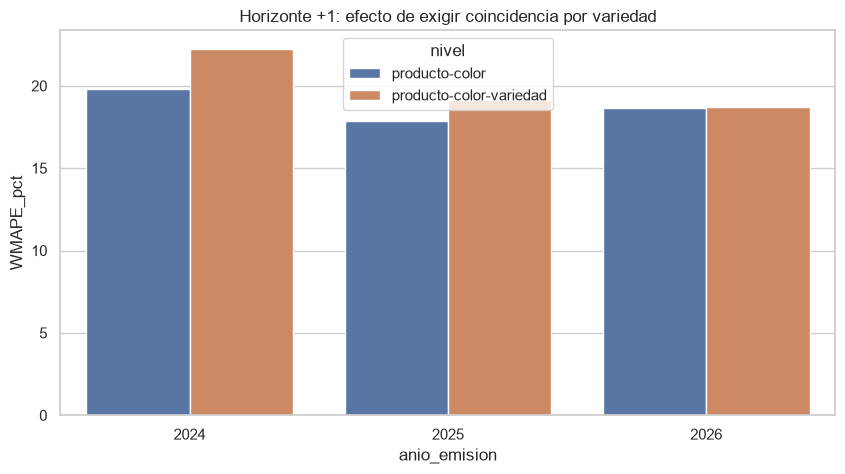

In [61]:
resumenes_nivel=[]
for nivel,tabla in [("producto-color",h1_pc),("producto-color-variedad",h1_pcv)]:
    resumen=tabla.groupby("anio_emision",as_index=False).agg(
        observaciones=("error","size"),sesgo=("error","mean"),
        error_abs_total=("error_abs","sum"),real_abs_total=("real_abs","sum"),
        dentro_8_pct=("dentro_8",lambda s:100*s.mean()))
    resumen["WMAPE_pct"]=100*resumen.error_abs_total/resumen.real_abs_total.replace(0,np.nan)
    resumen["nivel"]=nivel
    resumenes_nivel.append(resumen)
comparacion_h1=pd.concat(resumenes_nivel,ignore_index=True)
display(comparacion_h1[["anio_emision","nivel","observaciones","WMAPE_pct","sesgo","dentro_8_pct"]])
plt.figure(figsize=(10,5))
sns.barplot(data=comparacion_h1,x="anio_emision",y="WMAPE_pct",hue="nivel")
plt.title("Horizonte +1: efecto de exigir coincidencia por variedad")
plt.show()

### 24.4 Evolución semanal del error +1

,anio,semana,observaciones,tallos_reales,tallos_estimados,sesgo,error_abs_total,real_abs_total,dentro_8_pct,WMAPE_pct,lunes
95,2026,1,71,"405,934.00","1,034,950.00","8,859.38","629,364.00","405,934.00",1.41,155.04,2025-12-29
8,2024,10,59,"1,555,810.00","1,033,900.00","-8,845.93","548,500.00","1,555,810.00",6.78,35.25,2024-03-04
46,2024,51,65,"798,659.00","940,660.00","2,184.63","257,131.00","798,659.00",12.31,32.20,2024-12-16
12,2024,14,60,"1,280,099.00","1,549,725.30","4,493.77","395,187.48","1,280,099.00",5.00,30.87,2024-04-01
87,2025,44,72,"1,191,543.00","1,136,520.00",-764.21,"338,459.00","1,191,543.00",12.50,28.41,2025-10-27
65,2025,18,65,"1,628,070.00","1,208,518.00","-6,454.65","445,574.00","1,628,070.00",10.77,27.37,2025-04-28
25,2024,29,59,"827,396.00","984,260.00","2,658.71","225,882.00","827,396.00",20.34,27.30,2024-07-15
97,2026,5,72,"1,081,950.00","1,275,490.00","2,688.06","285,844.00","1,081,950.00",23.61,26.42,2026-01-26
38,2024,43,59,"1,484,567.00","1,143,860.00","-5,774.69","385,889.00","1,484,567.00",13.56,25.99,2024-10-21
14,2024,16,60,"1,492,902.00","1,172,580.00","-5,338.70","376,986.00","1,492,902.00",15.00,25.25,2024-04-15


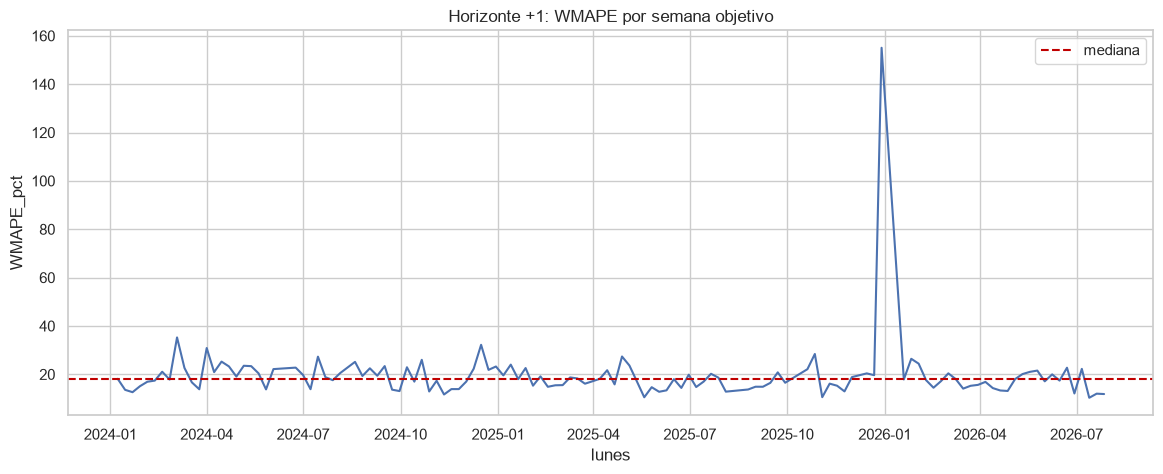

In [62]:
error_semana=h1_pc.groupby(["anio","semana"],as_index=False).agg(
    observaciones=("error","size"),tallos_reales=("tallos_reales","sum"),
    tallos_estimados=("tallos_estimados","sum"),sesgo=("error","mean"),
    error_abs_total=("error_abs","sum"),real_abs_total=("real_abs","sum"),
    dentro_8_pct=("dentro_8",lambda s:100*s.mean()))
error_semana["WMAPE_pct"]=100*error_semana.error_abs_total/error_semana.real_abs_total.replace(0,np.nan)
error_semana["lunes"]=pd.to_datetime(
    error_semana.anio.astype(str)+"-W"+error_semana.semana.astype(str).str.zfill(2)+"-1",
    format="%G-W%V-%u",errors="coerce")
display(error_semana.sort_values("WMAPE_pct",ascending=False).head(20))
plt.figure(figsize=(14,5))
sns.lineplot(data=error_semana,x="lunes",y="WMAPE_pct")
plt.axhline(error_semana.WMAPE_pct.median(),color="#C00000",linestyle="--",label="mediana")
plt.title("Horizonte +1: WMAPE por semana objetivo")
plt.legend(); plt.show()

## 26. Muestra reproducible de tres envíos por 2024, 2025 y 2026

In [63]:
disponibles=h1_pc[["anio_emision","archivo_origen"]].drop_duplicates()
seleccion=pd.concat([
    grupo.sample(min(3,len(grupo)),random_state=42)
    for _,grupo in disponibles.groupby("anio_emision") if _ in [2024,2025,2026]
],ignore_index=True)
display(seleccion.rename(columns={"archivo_origen":"envio_seleccionado"}))

archivos_muestra=seleccion.archivo_origen.tolist()
muestra=evaluacion_pc[
    evaluacion_pc.archivo_origen.isin(archivos_muestra) & evaluacion_pc.horizonte.between(1,5)
]
metricas_muestra=muestra.groupby(["anio_emision","horizonte"],as_index=False).agg(
    observaciones=("error","size"),sesgo=("error","mean"),
    error_abs_total=("error_abs","sum"),real_abs_total=("real_abs","sum"),
    dentro_8_pct=("dentro_8",lambda s:100*s.mean()))
metricas_muestra["WMAPE_pct"]=100*metricas_muestra.error_abs_total/metricas_muestra.real_abs_total.replace(0,np.nan)
display(metricas_muestra)

,anio_emision,envio_seleccionado
0,2024,estimado sem 10-19 2024 LG+AR envio.xlsx
1,2024,estimado sem 50-2024_8-2025 LG+AR envio_CORREC...
2,2024,estimado sem 52-2024_8-2025 LG+AR envio.xlsx
3,2025,estimado sem 22-26 2025 AR+LG envio.xlsx
4,2025,estimado sem 38-52 2025 AR+LG envio.xlsx
5,2025,estimado sem 21-25 2025 AR+LG envio.xlsx
6,2026,estimado sem 18-22 2026 LG+AR envio.xlsx
7,2026,Estimado sem 22-26 2026 LG+AR envio.xlsx
8,2026,Estimado sem 6-10 2026 LG+AR envio.xlsx


,anio_emision,horizonte,observaciones,sesgo,error_abs_total,real_abs_total,dentro_8_pct,WMAPE_pct
0,2024,1,188,"-1,898.22","943,138.00","3,345,926.00",19.68,28.19
1,2024,2,188,"-1,439.66","922,352.00","3,539,666.00",15.96,26.06
2,2024,3,190,"-1,191.49","984,685.00","3,873,283.00",18.42,25.42
3,2024,4,189,-508.04,"835,362.00","4,107,085.00",23.28,20.34
4,2024,5,188,"2,916.09","949,793.00","3,611,925.00",16.49,26.30
5,2025,1,196,-510.19,"481,444.00","3,470,254.00",27.04,13.87
6,2025,2,196,-681.40,"608,002.00","3,379,166.00",22.45,17.99
7,2025,3,196,-194.73,"565,451.00","3,200,392.00",23.47,17.67
8,2025,4,196,-890.39,"586,636.00","3,259,761.00",20.92,18.00
9,2025,5,196,"-1,918.28","623,533.00","3,358,139.00",23.98,18.57


## 27. Guardar resultados del benchmark

Se guardan solo tablas resumidas y pares comparables; no se duplican los Excel.

In [64]:
carpeta_benchmark=DATOS/"Estimados semanales"/"datos preprocesados"/"resultados benchmark"
carpeta_benchmark.mkdir(parents=True,exist_ok=True)
cinco.to_csv(carpeta_benchmark/"metricas_horizontes_1_a_5_producto_color.csv",index=False,encoding="utf-8-sig")
metricas_h1.to_csv(carpeta_benchmark/"metricas_horizonte_1_producto_color.csv",index=False,encoding="utf-8-sig")
impacto_h1.to_csv(carpeta_benchmark/"impacto_producto_color_horizonte_1.csv",index=False,encoding="utf-8-sig")
seleccion.to_csv(carpeta_benchmark/"muestra_tres_envios_por_anio.csv",index=False,encoding="utf-8-sig")
print("Resultados:",carpeta_benchmark)

Resultados: C:\Materias y Cosas Técnicas Uniandes\Proyecto de grado\Proyecto de grado 2\Datos\Estimados semanales\datos preprocesados\resultados benchmark


# PARTE VII — CONCLUSIONES, BASE FINAL Y PREGUNTAS

## 28. Qué está listo y qué todavía no

| Componente | Estado | Uso actual |
|---|---|---|
| Producción semanal | Listo con control de solapamientos | Objetivo y rezagos |
| Estimados +1 a +5 | Listo para benchmark | Comparación del ingeniero |
| Clima semanal | Cobertura temporal alta | Variables y rezagos |
| Catálogo de siembras | Cobertura de volumen alta | Homologación y variables estructurales |
| Estimado teórico Plan × Curvas | Implementado con control de unidades | Comparación separada frente al ajuste del ingeniero |
| Costos de faltante/sobrante | No disponible | Debe solicitarse |

## 29. Estructura recomendada de la tabla final

Una fila por:

`año objetivo + semana objetivo + producto + color + variedad + horizonte`

Bloques de variables:

- **Objetivo:** tallos reales de la semana objetivo.
- **Benchmark:** tallos estimados por el ingeniero y fecha real de emisión.
- **Producción conocida:** rezagos 1–8, medias móviles, tendencia y volatilidad.
- **Siembra:** plantas, cama/invernadero, fecha de siembra, edad y ciclo confirmado.
- **Clima conocido:** rezagos y acumulados disponibles antes de emitir el pronóstico.
- **Calendario:** semana ISO, mes, año, temporada comercial y festivos relevantes.
- **Calidad:** fuente, cobertura, homologación e imputación.

La división entrenamiento/prueba debe ser temporal. El horizonte +1 debe tener un modelo y reporte propios, aunque se entrenen modelos adicionales para +2 a +5.

## 30. Matriz de problemas y solicitudes para Producción (PDN)

In [65]:
problemas_pdn = pd.DataFrame([
    ["Crítica","Proceso de estimación","Los ajustes del ingeniero no están registrados como variables",
     "Solo se observa el estimado final, no el motivo ni la magnitud de cada ajuste",
     "No permite aprender todavía cuándo la experiencia humana corrige bien la curva",
     "Registrar estimado teórico, ajuste, motivo y estimado final por semana y producto"],
    ["Crítica","Plano de Siembras","No existe una llave oficial estable del ciclo",
     f"Llaves incompletas detectadas: {int(calidad_siembras.llaves_incompletas.sum()):,}",
     "Puede confundir una corrección con una siembra nueva",
     "Confirmar identificador oficial de finca-invernadero-cama-ciclo"],
    ["Alta","Plano de Siembras","Columnas agronómicas con #REF! o vacías",
     "Curva, ciclo, densidad, despunte y aplicaciones no son consistentes entre versiones",
     "Se pierden variables explicativas y no es seguro imputarlas",
     "Entregar tabla fuente sin fórmulas rotas y diccionario de unidades"],
    ["Alta","Plano de Siembras","Semana 02 de 2022 no contiene la hoja cruda Datos",
     "El libro solo conserva reportes/tablas agregadas y no permite recuperar cada cama",
     "Deja un hueco semanal que no puede reconstruirse con detalle",
     "Entregar la versión original con la base cruda de la semana 02 de 2022"],
    ["Alta","Plano de Siembras","La base cambia semanalmente sin bitácora de correcciones",
     f"Valor: {int(resumen_cambios.modificados_valor.sum()):,}; cobertura: {int(resumen_cambios.modificados_cobertura.sum()):,}; mixtos: {int(resumen_cambios.modificados_mixtos.sum()):,}",
     "No se distingue cambio operativo de corrección retroactiva",
     "Agregar fecha de modificación, usuario y motivo del cambio"],
    ["Alta","Producción real","Libros y hojas acumulados pueden solaparse o corregirse",
     f"Duplicados exactos: {int(auditoria_repeticion_produccion.duplicados_exactos.iloc[0]):,}",
     "Riesgo de duplicar tallos o borrar correcciones válidas",
     "Aclarar regla de vigencia y entregar ID de registro + fecha de actualización"],
    ["Alta","Estimados semanales","Faltan envíos históricos",
     f"Semanas faltantes inventariadas: {len(faltantes)}",
     "Reduce el backtest y puede sesgar la evaluación",
     "Confirmar si no se emitieron o entregar los archivos faltantes"],
    ["Alta","Estimados semanales","No hay fecha/hora exacta de emisión",
     "El horizonte se infiere del nombre del archivo",
     "Puede asignar mal el horizonte y generar fuga temporal",
     "Entregar timestamp de emisión y semana de corte de información"],
    ["Media","Clima","No hay correspondencia estación-sector-invernadero",
     "El clima se cruza actualmente a nivel finca-semana",
     "No representa microclimas ni permite variables espaciales",
     "Entregar mapa de sensores, ubicación, calibración y periodos de falla"],
    ["Crítica","Negocio","No está definido el costo asimétrico del error",
     "Subestimar y sobreestimar se ponderan igual en el benchmark actual",
     "El modelo puede mejorar WMAPE sin mejorar la decisión comercial",
     "Definir costo por faltante/sobrante para producto-color y fechas especiales"],
], columns=["prioridad","fuente","problema","evidencia","impacto_modelado","solicitud_concreta_PDN"])
display(problemas_pdn)
ruta_solicitudes_csv = DATOS / "solicitudes_calidad_datos_PDN.csv"
ruta_solicitudes_xlsx = DATOS / "solicitudes_calidad_datos_PDN.xlsx"
problemas_pdn.to_csv(ruta_solicitudes_csv, index=False, encoding="utf-8-sig")
problemas_pdn.to_excel(ruta_solicitudes_xlsx, index=False)
print("Matriz guardada en:", ruta_solicitudes_xlsx)

,prioridad,fuente,problema,evidencia,impacto_modelado,solicitud_concreta_PDN
0,Crítica,Proceso de estimación,Los ajustes del ingeniero no están registrados...,"Solo se observa el estimado final, no el motiv...",No permite aprender todavía cuándo la experien...,"Registrar estimado teórico, ajuste, motivo y e..."
1,Crítica,Plano de Siembras,No existe una llave oficial estable del ciclo,"Llaves incompletas detectadas: 1,948",Puede confundir una corrección con una siembra...,Confirmar identificador oficial de finca-inver...
2,Alta,Plano de Siembras,Columnas agronómicas con #REF! o vacías,"Curva, ciclo, densidad, despunte y aplicacione...",Se pierden variables explicativas y no es segu...,Entregar tabla fuente sin fórmulas rotas y dic...
3,Alta,Plano de Siembras,Semana 02 de 2022 no contiene la hoja cruda Datos,El libro solo conserva reportes/tablas agregad...,Deja un hueco semanal que no puede reconstruir...,Entregar la versión original con la base cruda...
4,Alta,Plano de Siembras,La base cambia semanalmente sin bitácora de co...,"Valor: 41,952; cobertura: 35,358; mixtos: 690",No se distingue cambio operativo de corrección...,"Agregar fecha de modificación, usuario y motiv..."
5,Alta,Producción real,Libros y hojas acumulados pueden solaparse o c...,"Duplicados exactos: 334,819",Riesgo de duplicar tallos o borrar correccione...,Aclarar regla de vigencia y entregar ID de reg...
6,Alta,Estimados semanales,Faltan envíos históricos,Semanas faltantes inventariadas: 15,Reduce el backtest y puede sesgar la evaluación,Confirmar si no se emitieron o entregar los ar...
7,Alta,Estimados semanales,No hay fecha/hora exacta de emisión,El horizonte se infiere del nombre del archivo,Puede asignar mal el horizonte y generar fuga ...,Entregar timestamp de emisión y semana de cort...
8,Media,Clima,No hay correspondencia estación-sector-inverna...,El clima se cruza actualmente a nivel finca-se...,No representa microclimas ni permite variables...,"Entregar mapa de sensores, ubicación, calibrac..."
9,Crítica,Negocio,No está definido el costo asimétrico del error,Subestimar y sobreestimar se ponderan igual en...,El modelo puede mejorar WMAPE sin mejorar la d...,Definir costo por faltante/sobrante para produ...


Matriz guardada en: C:\Materias y Cosas Técnicas Uniandes\Proyecto de grado\Proyecto de grado 2\Datos\solicitudes_calidad_datos_PDN.xlsx


## 31. Nuevas preguntas prioritarias para el equipo de Producción

1. ¿Qué información usa el ingeniero para modificar el cálculo teórico `plantas × flores/planta`?
2. ¿Es posible registrar por separado el cálculo teórico, el ajuste aplicado, su motivo y el estimado final?
3. ¿Cuál es la convención exacta de edad de la cama y en qué momento cambia de semana?
4. ¿Las filas repetidas de Producción son movimientos distintos o correcciones, y cuál es su ID y fecha de actualización?
5. ¿Qué grados, tipos de corte y descartes componen exactamente “tallos exportables”?
6. ¿Pueden entregar fecha/hora de emisión y confirmar si las semanas faltantes de estimados nunca se emitieron?
7. ¿Los ajustes cambian según variedad, clima, labores, sanidad o temporada comercial?
8. ¿Cuál es el costo de subestimar y sobreestimar por producto-color, especialmente en temporadas comerciales?
9. ¿Qué estación climática representa cada sector o invernadero de Gaitana?

## 32. Lectura ejecutiva

- Existe suficiente producción, clima y benchmark para construir una primera línea base temporal.
- El estimado +1 debe ser el primer objetivo de mejora: es el más útil y tiene una tasa baja de casos dentro de ±8 %.
- El Plan de Siembras aporta plantas, variedad y edad; las Curvas aportan flores por planta. Su producto es el estimado teórico, sin usar `FECHA PRODUCCION`.
- El ingeniero ajusta ese valor teórico. La comparación muestra si ese ajuste reduce el error y en qué horizontes, productos o semanas lo consigue.
- El siguiente avance debe ser una tabla maestra sin fuga de información y un backtest temporal contra el ingeniero.